# 0. Setup

In [156]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [157]:
# Read fantasy_score.csv to df
df = pd.read_csv('fantasy_score.csv')

# Drop ID columns that aren't needed for analysis
df = df.drop(columns=['playerID', 'teamID'])

# Filter for specific teams
target_teams = [
    'Iron Wing', 'Team Spirit', 'TEAM VISION', 'BoomBoys',
    'Team Liquid', 'Team Yandex', 'Nigma Galaxy', 'Team Falcons'
]
df = df[df['teamName'].isin(target_teams)]

print(df.head(3))

      matchID  seriesID                     Versus  Game_number  gametime  \
0  8946343023   1130566  Aurora Gaming vs BoomBoys            1      2527   
1  8946343023   1130566  Aurora Gaming vs BoomBoys            1      2527   
4  8948026518   1130934  Aurora Gaming vs BoomBoys            1      3512   

   isLastGame playerName  teamName position  heroID  ... runes_grabbed  \
0           0  Kiritych~  BoomBoys     core     145  ...         282.0   
1           0      MieRo  BoomBoys     core      38  ...         564.0   
4           0  Kiritych~  BoomBoys     core      36  ...        1692.0   

   watchers_taken  smokes_used  teamfight_participation   stuns  \
0           882.0          0.0                  1453.26  295.34   
1           147.0          0.0                  1117.89  579.00   
4           735.0          0.0                  1652.00  227.67   

   firstblood_claimed  roshan_kills  tormentor_kills  courier_kills  \
0              1934.0        1172.0            879.0  

In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 510 entries, 0 to 1089
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   matchID                  510 non-null    int64  
 1   seriesID                 510 non-null    int64  
 2   Versus                   510 non-null    object 
 3   Game_number              510 non-null    int64  
 4   gametime                 510 non-null    int64  
 5   isLastGame               510 non-null    int64  
 6   playerName               510 non-null    object 
 7   teamName                 510 non-null    object 
 8   position                 510 non-null    object 
 9   heroID                   510 non-null    int64  
 10  heroName                 510 non-null    object 
 11  kills                    510 non-null    float64
 12  deaths                   510 non-null    float64
 13  creep_score              510 non-null    float64
 14  gpm                      510 n

In [159]:
def aggregate_positions(input_df):
    """Groups df by team, match, and position, and returns (cores, mids, supports)."""
    if input_df.empty:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    # List of stat columns to average
    stat_cols = [
        'kills', 'deaths', 'creep_score', 'gpm', 'madstone_collected',
        'tower_kills', 'obs_placed', 'camps_stacked', 'runes_grabbed',
        'watchers_taken', 'smokes_used', 'teamfight_participation',
        'stuns', 'firstblood_claimed', 'roshan_kills', 'tormentor_kills',
        'courier_kills'
    ]

    # Create aggregation dictionary
    agg_dict = {
        'playerName': lambda x: ' & '.join(x.astype(str).unique()),
        'seriesID': 'first',
        'Versus': 'first',
        'Game_number': 'first',
        'gametime': 'mean',
        'isLastGame': 'first',
        'date': 'first'
    }

    for col in stat_cols:
        if col in input_df.columns:
            agg_dict[col] = 'mean'

    # Group by team, match, AND position
    df_agg = input_df.groupby(['teamName', 'matchID', 'position']).agg(agg_dict).reset_index()

    # Split and return the 3 values
    df_cores = df_agg[df_agg['position'] == 'core'].copy()
    df_mids = df_agg[df_agg['position'] == 'mid'].copy()
    df_supports = df_agg[df_agg['position'] == 'support'].copy()

    return df_cores, df_mids, df_supports

In [160]:
def analyze_stat_performance(df_input, stat_column):
    # Show the top 3 rows showing only Versus, playerName, and the chosen stat
    print(f"--- Top 3 Performances for {stat_column.capitalize()} ---")
    display(df_input.sort_values(by=stat_column, ascending=False)[["Versus", "playerName", stat_column]].head(3))

    # Set the visual style
    sns.set_theme(style="whitegrid")

    # Create a figure with two subplots: a boxplot and a histogram
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(10, 6))

    # Add boxplot
    sns.boxplot(x=df_input[stat_column], ax=ax_box, color="skyblue")
    ax_box.set(xlabel='')

    # Add histogram with a high-contrast black KDE line for maximum visibility
    sns.histplot(df_input[stat_column], ax=ax_hist, kde=True, color="teal", line_kws={"linewidth": 5, "color": "black"})

    # Set titles and labels
    ax_box.set_title(f"Distribution of {stat_column.capitalize()}", fontsize=16)
    ax_hist.set_xlabel(f"{stat_column.capitalize()} per Game", fontsize=12)
    ax_hist.set_ylabel("Frequency", fontsize=12)

    plt.tight_layout()
    plt.show()

In [161]:
def analyze_series_top2_stat(df_input, stat_column):
    # Group by series and team, then take the sum of the 2 highest values for the stat
    df_series = df_input.groupby(['seriesID', 'teamName'])[stat_column].apply(lambda x: x.nlargest(2).sum()).reset_index()

    # Merge back to get the 'Versus' context (taking the first occurrence per series)
    context = df_input.drop_duplicates(subset=['seriesID', 'teamName'])[['seriesID', 'teamName', 'Versus']]
    df_series = df_series.merge(context, on=['seriesID', 'teamName'])

    print(f"--- Top 3 Series (Sum of top 2 games) for {stat_column.capitalize()} ---")
    display(df_series.sort_values(by=stat_column, ascending=False)[['Versus', 'teamName', stat_column]].head(3))

    # Visualization
    sns.set_theme(style='whitegrid')
    plt.figure(figsize=(10, 5))
    sns.histplot(df_series[stat_column], kde=True, color='purple')
    plt.title(f'Distribution of Series Total (Top 2 Games) for {stat_column.capitalize()}')
    plt.show()

In [162]:
def analyze_series_stat_by_team(df_input, stat_column):
    """Plots individual series scores vs team average for a specific stat."""
    # 1. Calculate series scores (sum of top 2 games)
    df_series = df_input.groupby(['seriesID', 'teamName'])[stat_column].apply(lambda x: x.nlargest(2).sum()).reset_index()

    # 2. Setup Plotting
    plt.figure(figsize=(12, 6))
    sns.set_theme(style='whitegrid')

    # 3. Show all individual series scores as small dots
    sns.stripplot(
        data=df_series,
        x=stat_column,
        y='teamName',
        jitter=0.25,
        size=7,
        alpha=0.6,
        palette='deep',
        hue='teamName',
        legend=False
    )

    # 4. Overlay the average score for each team as a distinct marker
    sns.pointplot(
        data=df_series,
        x=stat_column,
        y='teamName',
        linestyle='none',
        color='black',
        markers='D',
        markersize=8,
        errorbar=None
    )

    plt.title(f'Series {stat_column.capitalize()}: Individual Series (dots) vs. Team Average (diamonds)', fontsize=16)
    plt.xlabel(f'Total {stat_column.capitalize()} Score in Series (Top 2 Games)', fontsize=13)
    plt.ylabel('Team Name', fontsize=13)
    plt.tight_layout()
    plt.show()

In [163]:
# Re-aggregate positions based on the newly filtered DataFrame
df_cores, df_mids, df_supports = aggregate_positions(df)

display(df_cores.head(2))

,teamName,matchID,position,playerName,seriesID,Versus,Game_number,gametime,isLastGame,date,...,camps_stacked,runes_grabbed,watchers_taken,smokes_used,teamfight_participation,stuns,firstblood_claimed,roshan_kills,tormentor_kills,courier_kills
0,BoomBoys,8943013334,core,Kiritych~ & MieRo,1130032,BoomBoys vs OG,1,2722.0,0,13/08/2026,...,1170.0,634.5,441.0,0.0,1255.095,408.34,967.0,586.0,0.0,0.0
3,BoomBoys,8943055466,core,Kiritych~ & MieRo,1130032,BoomBoys vs OG,2,2215.0,0,13/08/2026,...,819.0,352.5,220.5,0.0,1391.585,201.50,0.0,0.0,0.0,351.5


# TLDR:

* **Role >**
  * **Stat >**
    * Overall all game, per series, per team (max, average, 25-75)
    * Overall all stat (which stat should get prioritized)
  * **Prefix >** // Todo
    * Percentage trigger game by player
    * Percentage increase in point overall (increased point/total point) >
      * each player (in a series) //TODO
      * each team (in a series)
    * Percentage increase in point overall all teams (in a series) > sorting
  * **Suffix >** // Todo
    * Same as Prefix

## In reddit:

Core

Red: Creeps >> GPM > Deaths(for stable result) / Towers(if you want to risk) > Kills > Madstones

Green: Roshan > Teamfight > Tormentor >>> Stuns >>> Courier kills/FB

Mid

Red: Creeps > GPM > Deaths(stability) / Kills(risk) >> Madstones > Towers

Green: Teamfight > Stuns(stable) / Tormentor(risk) >>> Roshan >>> Courier Kills / FB

Blue: Runes >>> Camps / Lotuses >>> Everything else

Support

Green: Teamfight > Tormentor > Courier kills > Stuns >>> FB / Roshan

Blue: Wards / Smokes > Lotuses / Camps >> Watchers >>> Runes

## My finding:

Core

Red: Creeps > GPM >> Deaths > Towers/Kills >>> Madstones

Green: Teamfight(very stable) >> Stun (depend on the hero picks) > Roshan > FB(take risk) > Tormentor/Courier kills

Mid

Red: Creeps > GPM > Deaths(stability) > Kills(In theory, should be better than Death but statistic said otherwise) >> Madstones > Towers

Green: Teamfight >> Stuns > FB(Yolo) > Roshan (long game) > Tormentor >> Courier

Blue: Runes >>> Camps / Lotuses(No stat, unsure) > Watcher(not sure the authentic of this stat) >>> Everything else

Support

Green: Teamfight >>> Stuns >> Everything else

Blue: Camps (great) > Wards/Smokes (good) > (might be not bad)Lotuses/Watchers >>   Runes

# 1. Cores

## 1.1 Red Stats

### 1.1.1 Kills

--- Top 3 Performances for Kills ---


,Versus,playerName,kills
225,Team Liquid vs Team Spirit,Yatoro & Collapse,1979.5
105,TEAM VISION vs Team Falcons,Satanic & Noticed,1712.0
45,Iron Wing vs Nigma Galaxy,33 & Pure,1605.0


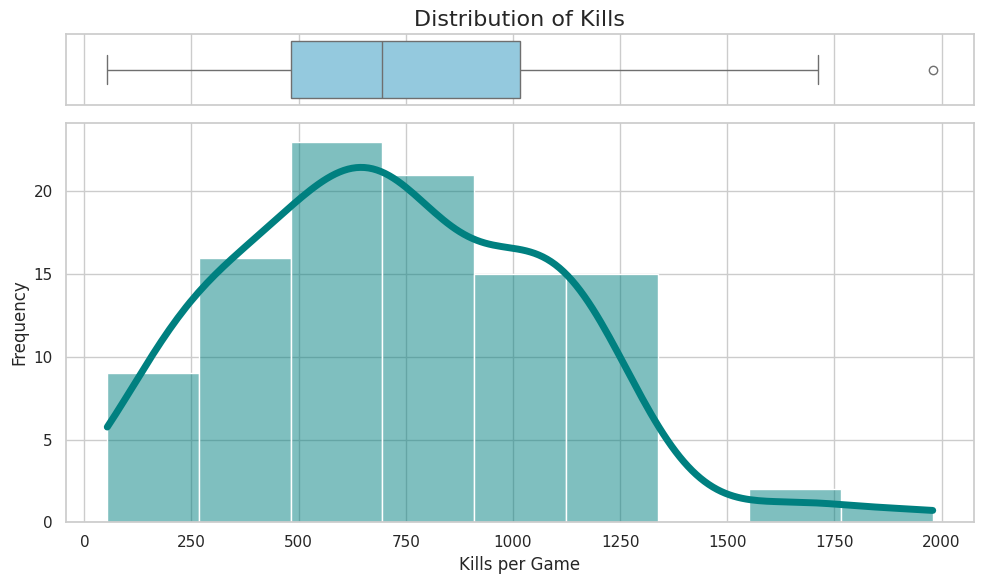

In [164]:
analyze_stat_performance(df_cores, 'kills')

--- Top 3 Series (Sum of top 2 games) for Kills ---


,Versus,teamName,kills
19,Team Liquid vs Team Spirit,Team Spirit,3156.5
9,TEAM VISION vs Team Falcons,TEAM VISION,2835.5
1,TEAM VISION vs Team Resilience,TEAM VISION,2300.5


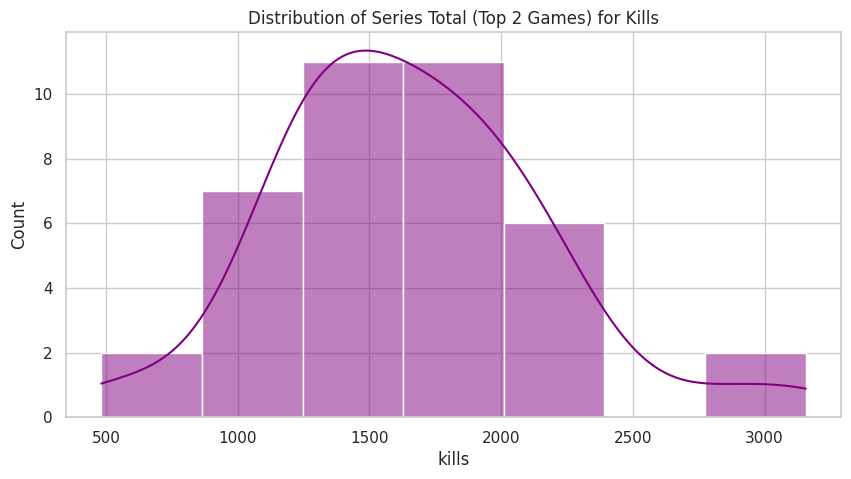

In [165]:
# Run series analysis for kills
analyze_series_top2_stat(df_cores, 'kills')

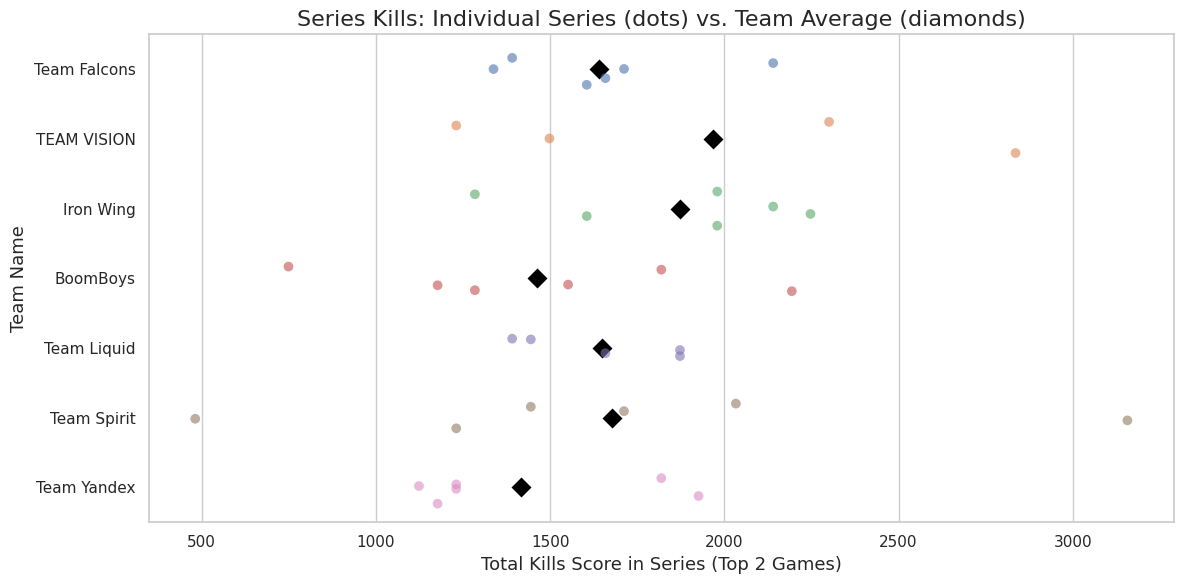

In [166]:
analyze_series_stat_by_team(df_cores, 'kills')

### 1.1.2 Deaths

--- Top 3 Performances for Deaths ---


,Versus,playerName,deaths
42,Iron Wing vs Nigma Galaxy,33 & Pure,1950.0
3,BoomBoys vs OG,Kiritych~ & MieRo,1852.5
108,BoomBoys vs TEAM VISION,Satanic & Noticed,1852.5


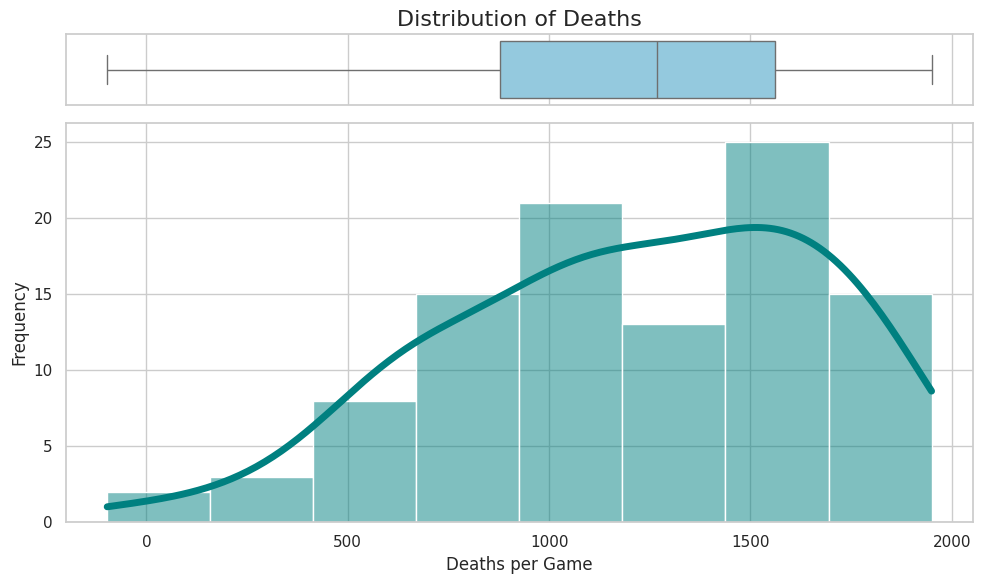

In [167]:
analyze_stat_performance(df_cores, 'deaths')

--- Top 3 Series (Sum of top 2 games) for Deaths ---


,Versus,teamName,deaths
21,Team Resilience vs Team Yandex,Team Yandex,3705.0
26,TEAM VISION vs Team Spirit,TEAM VISION,3510.0
34,Team Falcons vs Vici Gaming,Team Falcons,3510.0


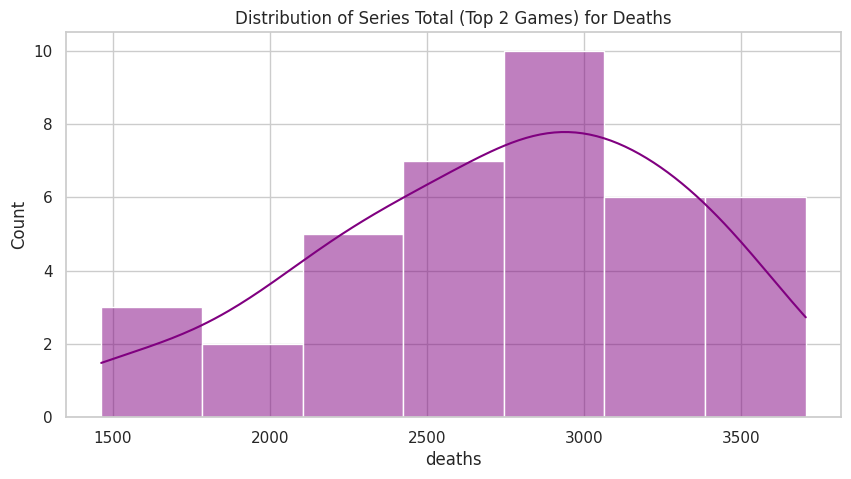

In [168]:
analyze_series_top2_stat(df_cores, 'deaths')

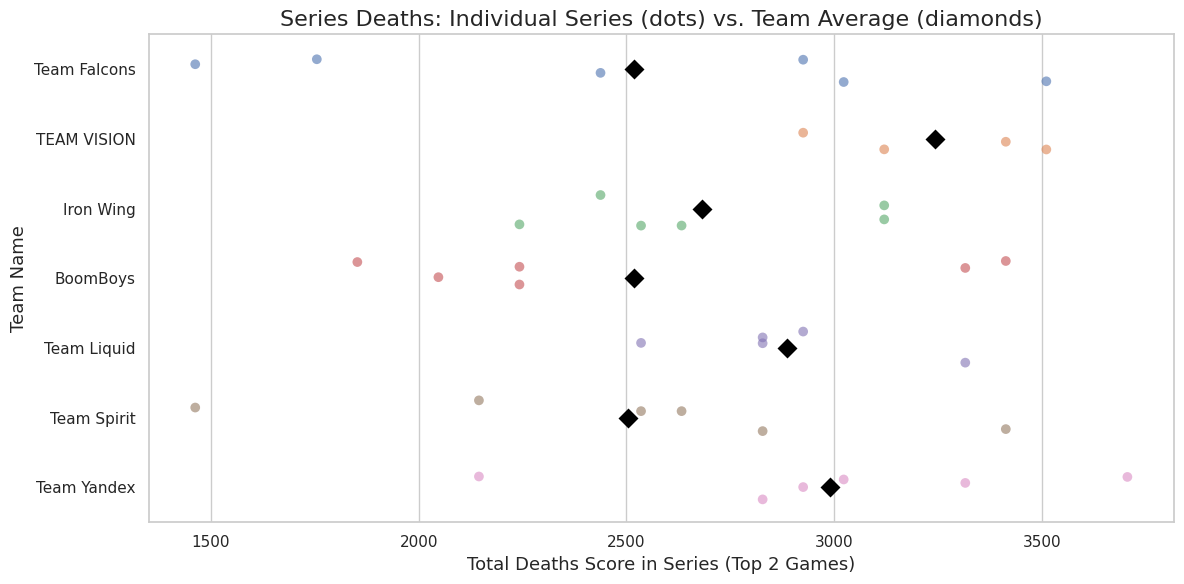

In [169]:
analyze_series_stat_by_team(df_cores, 'deaths')

### 1.1.3 Creep Score

--- Top 3 Performances for Creep_score ---


,Versus,playerName,creep_score
135,TEAM VISION vs Team Falcons,skiter & AMMAR_THE_F,3627.0
105,TEAM VISION vs Team Falcons,Satanic & Noticed,3168.0
111,BoomBoys vs TEAM VISION,Satanic & Noticed,2992.5


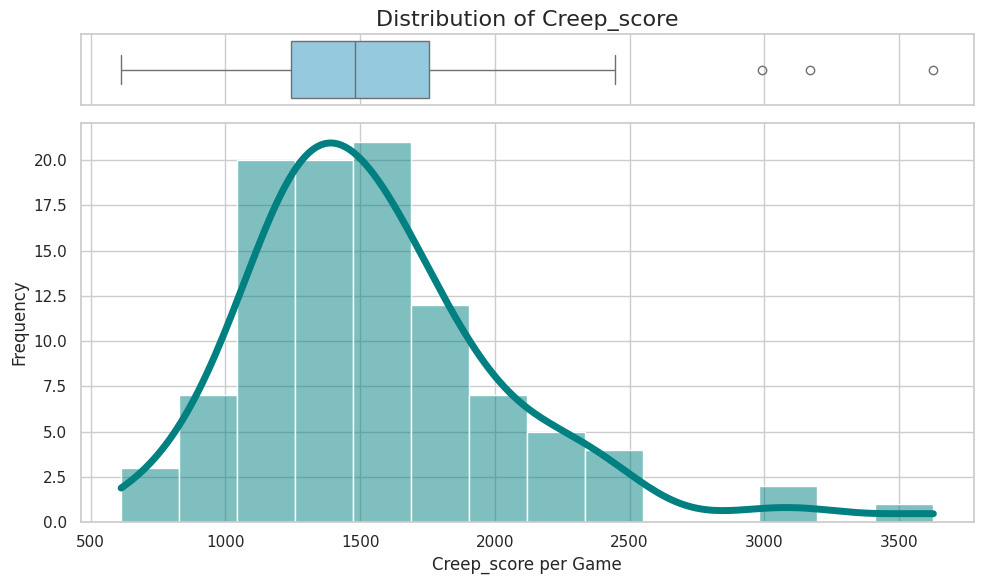

In [170]:
analyze_stat_performance(df_cores, 'creep_score')

--- Top 3 Series (Sum of top 2 games) for Creep_score ---


,Versus,teamName,creep_score
10,TEAM VISION vs Team Falcons,Team Falcons,5137.5
9,TEAM VISION vs Team Falcons,TEAM VISION,5086.5
15,BoomBoys vs TEAM VISION,TEAM VISION,4704.0


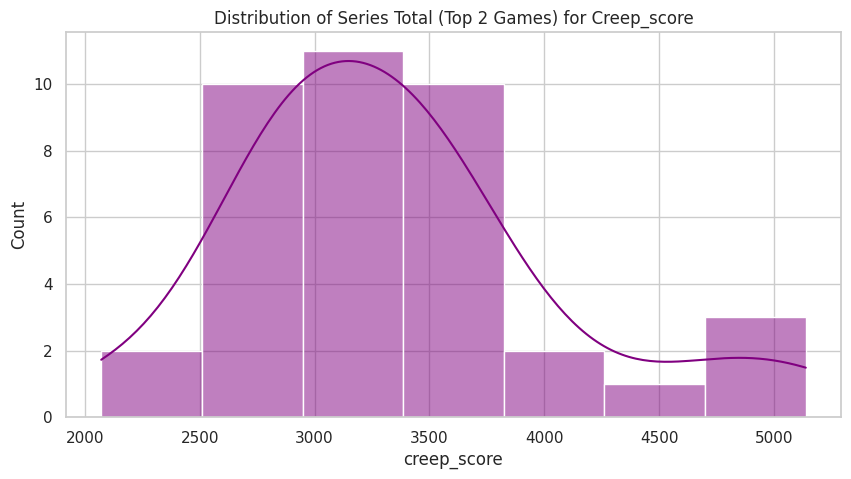

In [171]:
analyze_series_top2_stat(df_cores, 'creep_score')

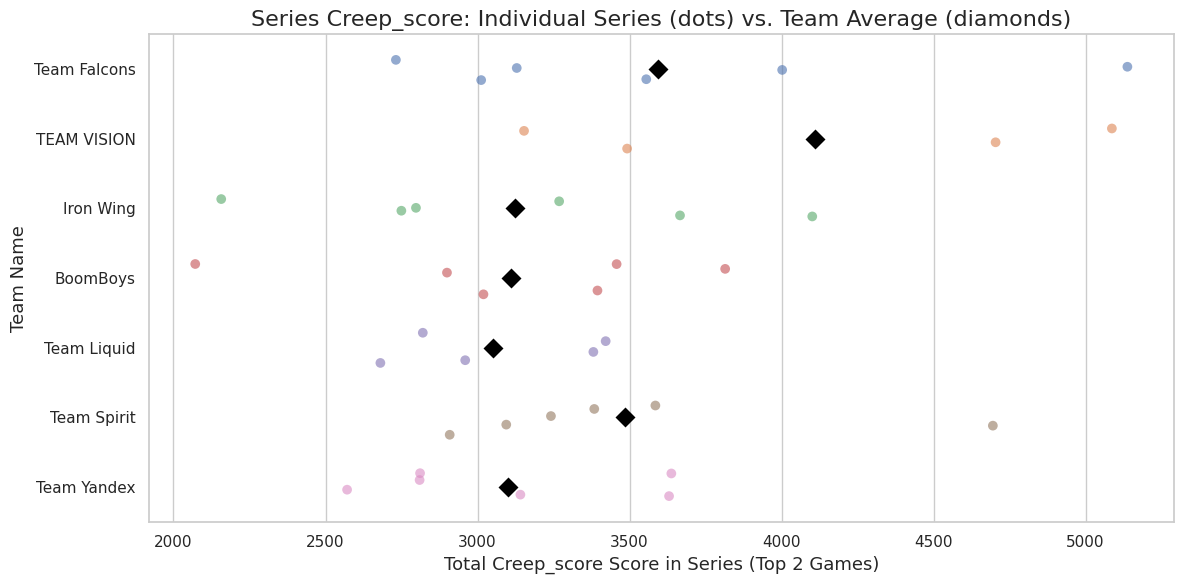

In [172]:
analyze_series_stat_by_team(df_cores, 'creep_score')

### 1.1.4 GPM

--- Top 3 Performances for Gpm ---


,Versus,playerName,gpm
114,TEAM VISION vs Team Spirit,Satanic & Noticed,1729.0
111,BoomBoys vs TEAM VISION,Satanic & Noticed,1697.0
108,BoomBoys vs TEAM VISION,Satanic & Noticed,1681.0


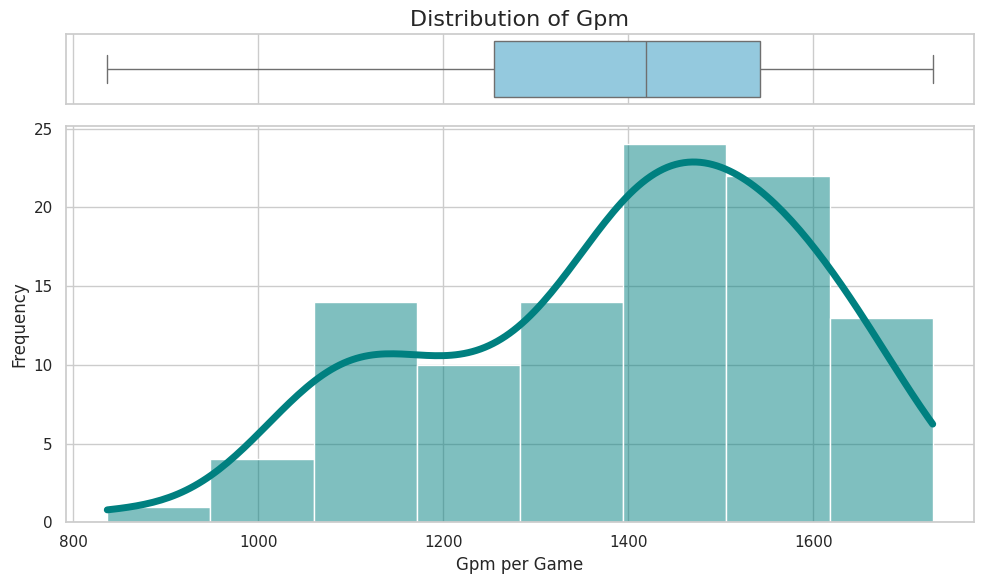

In [173]:
analyze_stat_performance(df_cores, 'gpm')

--- Top 3 Series (Sum of top 2 games) for Gpm ---


,Versus,teamName,gpm
15,BoomBoys vs TEAM VISION,TEAM VISION,3378.0
8,BoomBoys vs Iron Wing,Iron Wing,3329.0
26,TEAM VISION vs Team Spirit,TEAM VISION,3260.0


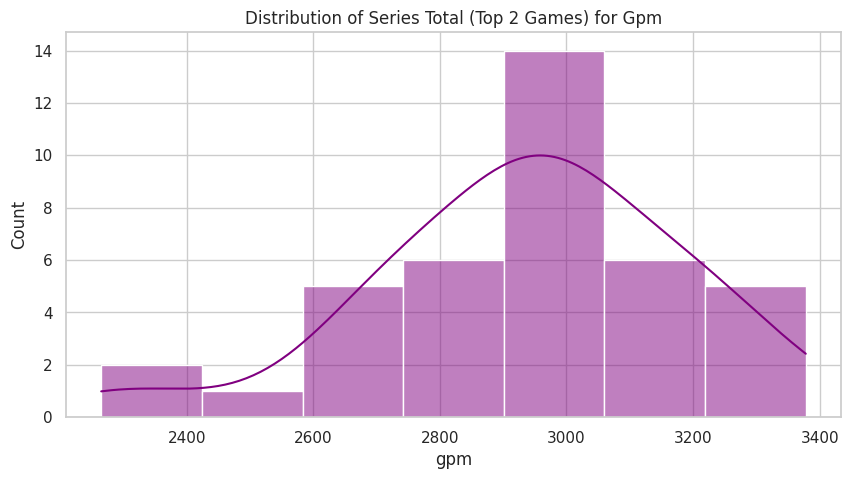

In [174]:
analyze_series_top2_stat(df_cores, 'gpm')

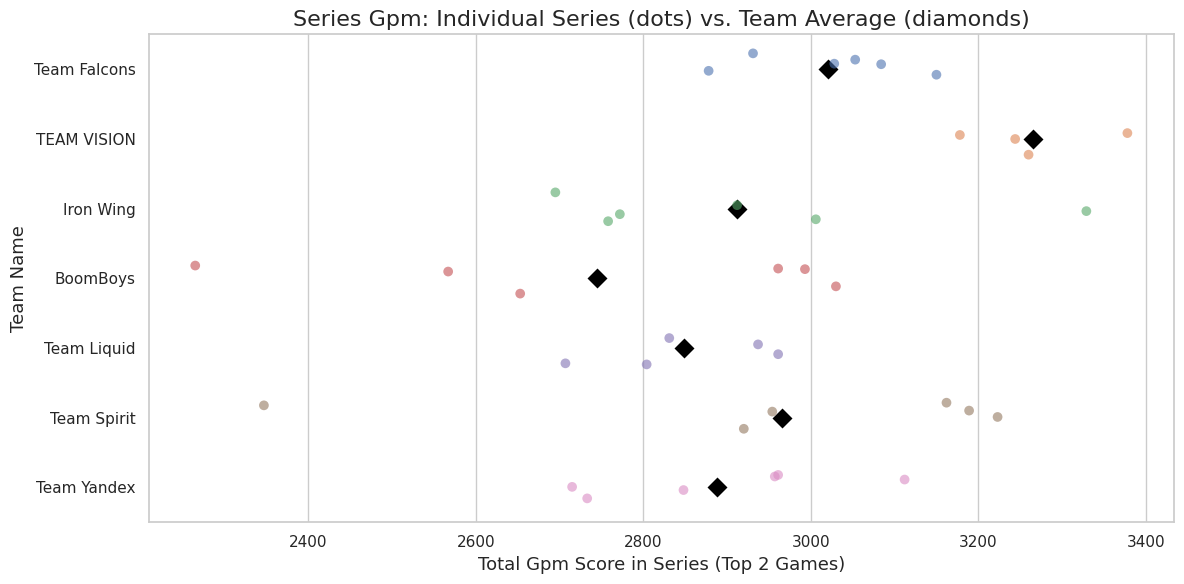

In [175]:
analyze_series_stat_by_team(df_cores, 'gpm')

### 1.1.5 Madstone Collected

--- Top 3 Performances for Madstone_collected ---


,Versus,playerName,madstone_collected
135,TEAM VISION vs Team Falcons,skiter & AMMAR_THE_F,773.5
105,TEAM VISION vs Team Falcons,Satanic & Noticed,734.5
57,Iron Wing vs Team Falcons,33 & Pure,390.0


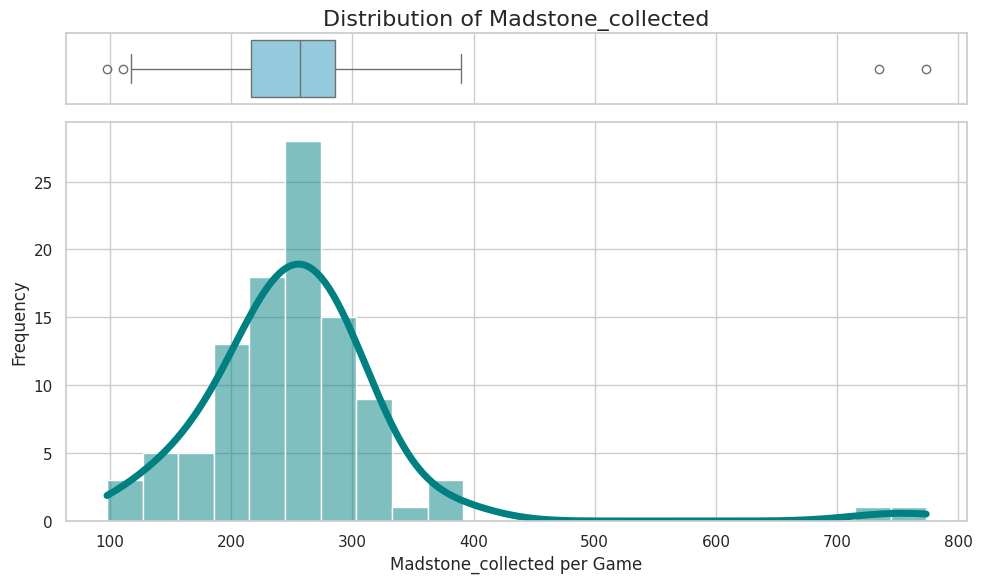

In [176]:
analyze_stat_performance(df_cores, 'madstone_collected')

--- Top 3 Series (Sum of top 2 games) for Madstone_collected ---


,Versus,teamName,madstone_collected
10,TEAM VISION vs Team Falcons,Team Falcons,1033.5
9,TEAM VISION vs Team Falcons,TEAM VISION,923.0
8,BoomBoys vs Iron Wing,Iron Wing,689.0


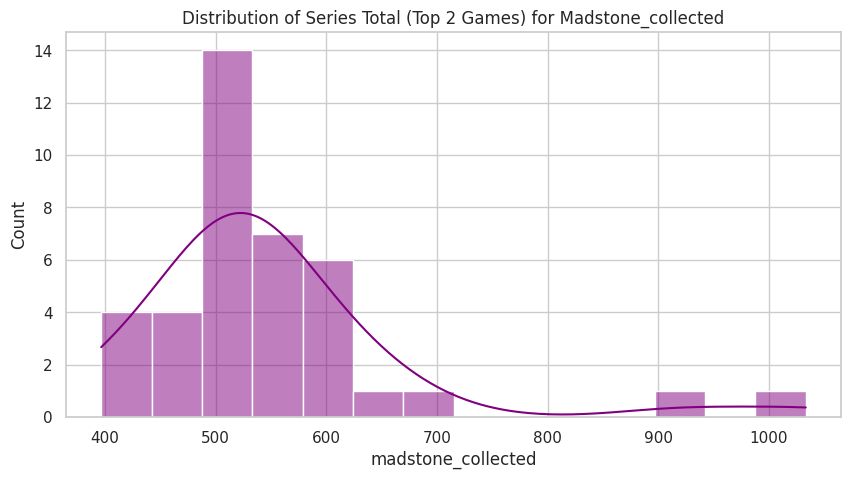

In [177]:
analyze_series_top2_stat(df_cores, 'madstone_collected')

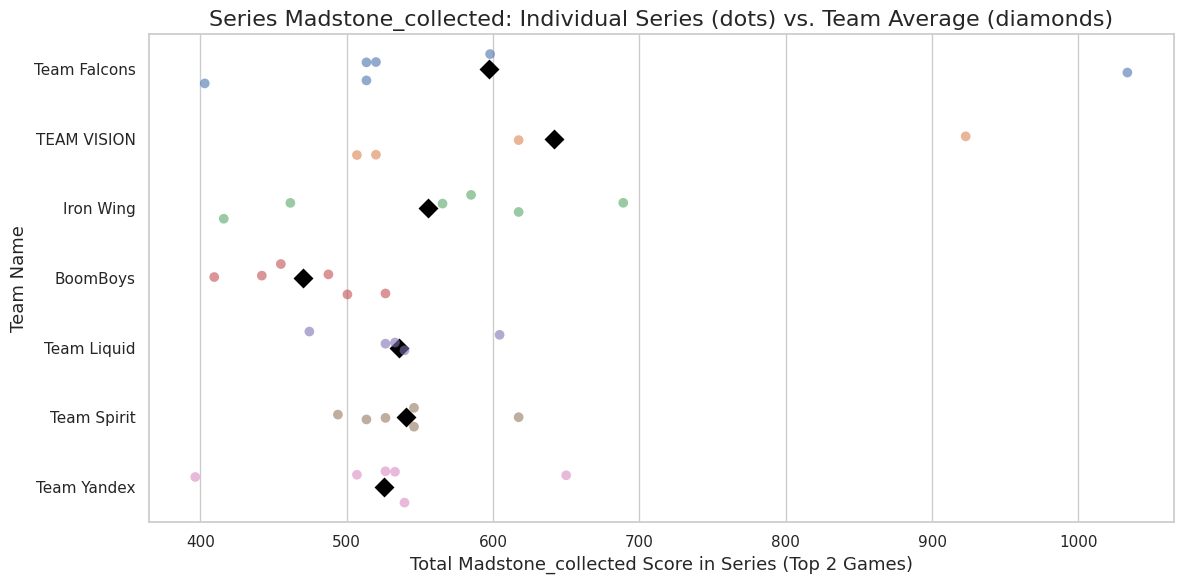

In [178]:
analyze_series_stat_by_team(df_cores, 'madstone_collected')

### 1.1.6 Tower Kills

--- Top 3 Performances for Tower_kills ---


,Versus,playerName,tower_kills
6,BoomBoys vs Iron Wing,Kiritych~ & MieRo,1584.0
45,Iron Wing vs Nigma Galaxy,33 & Pure,1584.0
183,Team Liquid vs Team Yandex,Ace ♠ & m1CKe,1584.0


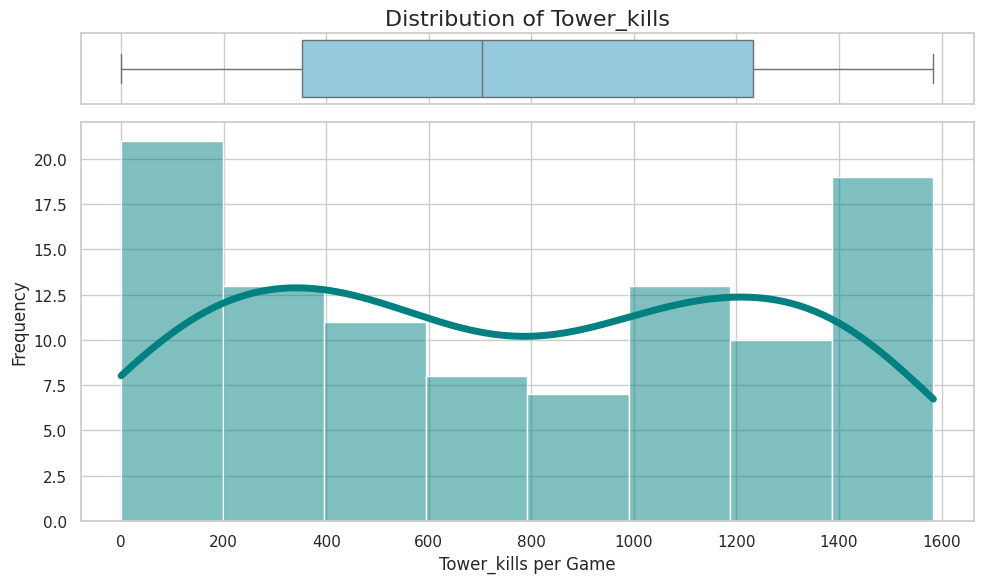

In [179]:
analyze_stat_performance(df_cores, 'tower_kills')

--- Top 3 Series (Sum of top 2 games) for Tower_kills ---


,Versus,teamName,tower_kills
2,Iron Wing vs Nigma Galaxy,Iron Wing,2816.0
22,GamerLegion vs Team Falcons,Team Falcons,2816.0
12,Team Liquid vs Team Yandex,Team Liquid,2816.0


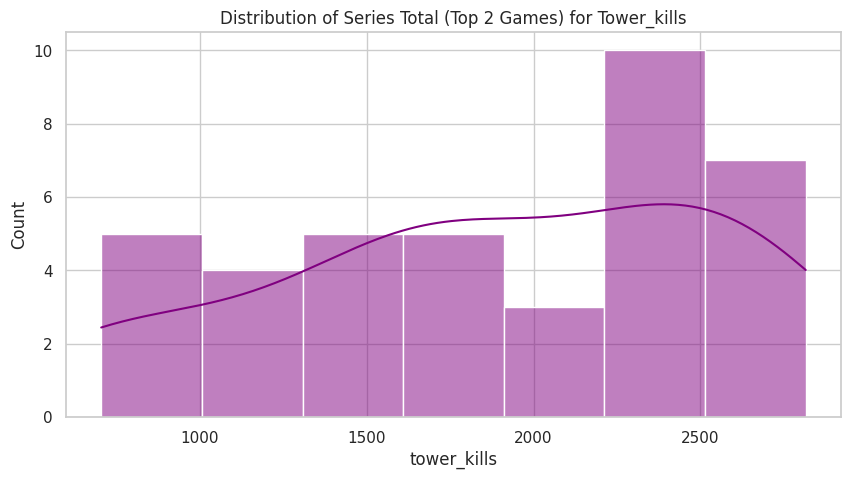

In [180]:
analyze_series_top2_stat(df_cores, 'tower_kills')

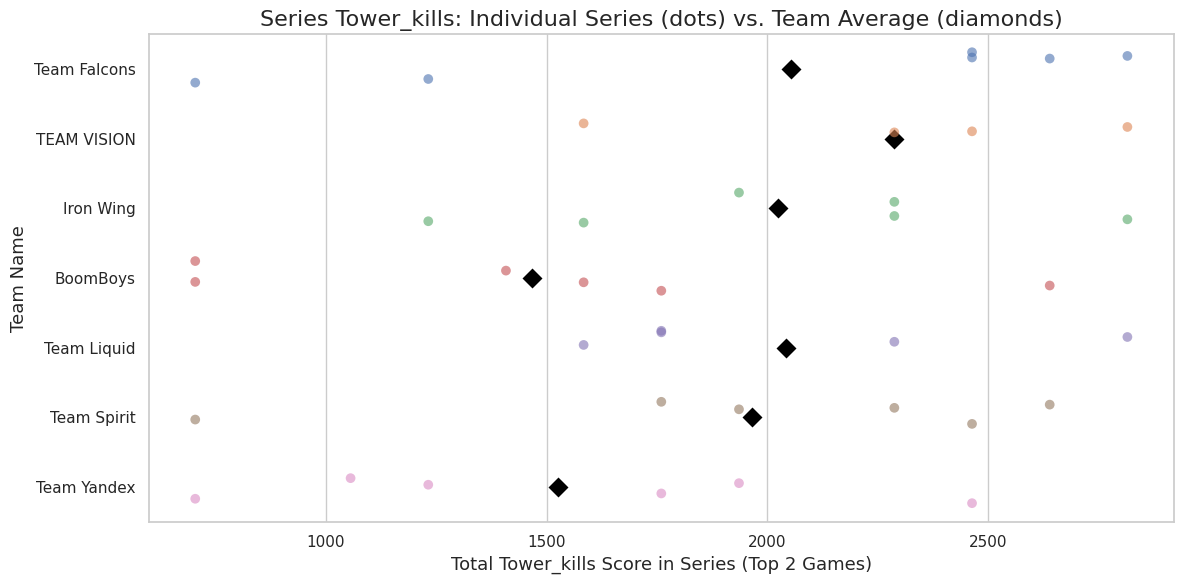

In [181]:
analyze_series_stat_by_team(df_cores, 'tower_kills')

## 1.2 Green stats

### 1.2.1 Teamfight Participation

--- Top 3 Performances for Teamfight_participation ---


,Versus,playerName,teamfight_participation
303,LGD Gaming vs Team Yandex,医者watson` & DM,1672.650
171,Team Liquid vs Vici Gaming,Ace ♠ & m1CKe,1661.075
219,Aurora Gaming vs Team Spirit,Yatoro & Collapse,1659.375


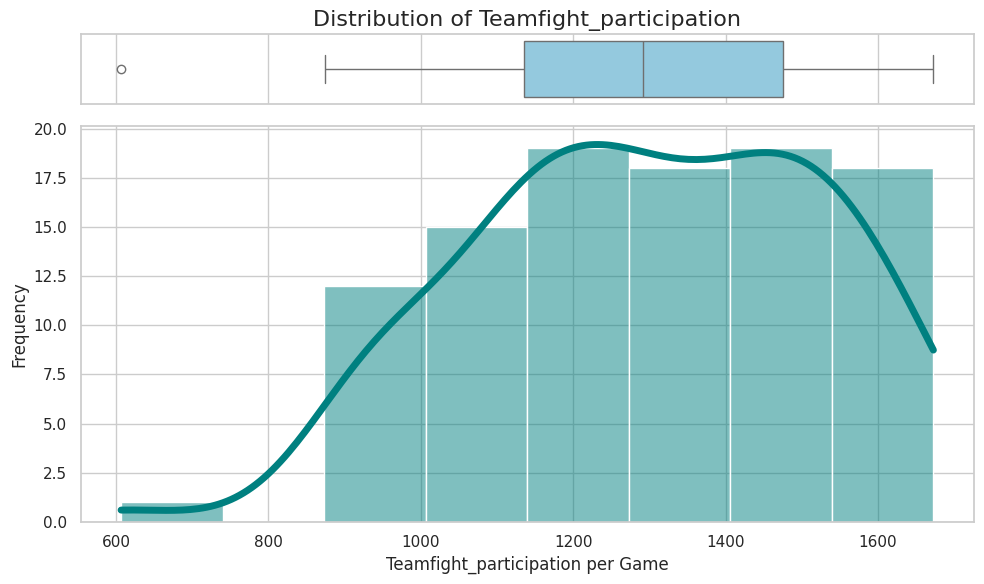

In [183]:
analyze_stat_performance(df_cores, 'teamfight_participation')

--- Top 3 Series (Sum of top 2 games) for Teamfight_participation ---


,Versus,teamName,teamfight_participation
38,LGD Gaming vs Team Yandex,Team Yandex,3194.850
10,TEAM VISION vs Team Falcons,Team Falcons,3150.865
35,Aurora Gaming vs BoomBoys,BoomBoys,3100.065


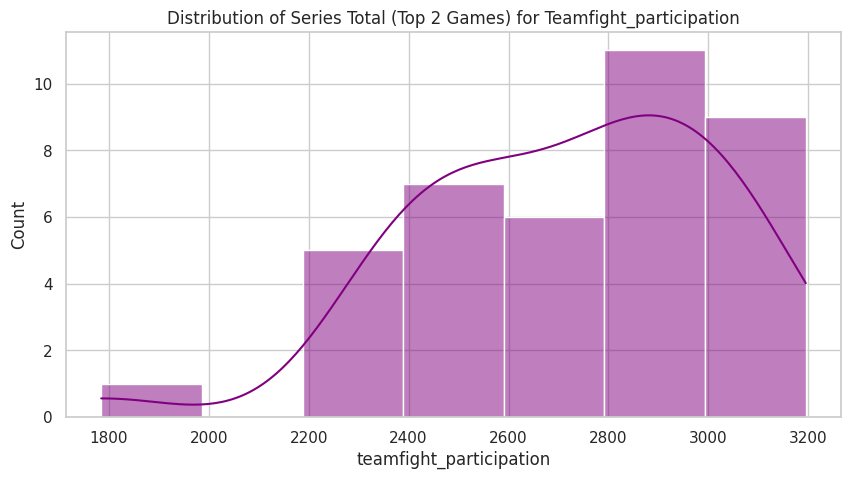

In [184]:
analyze_series_top2_stat(df_cores, 'teamfight_participation')

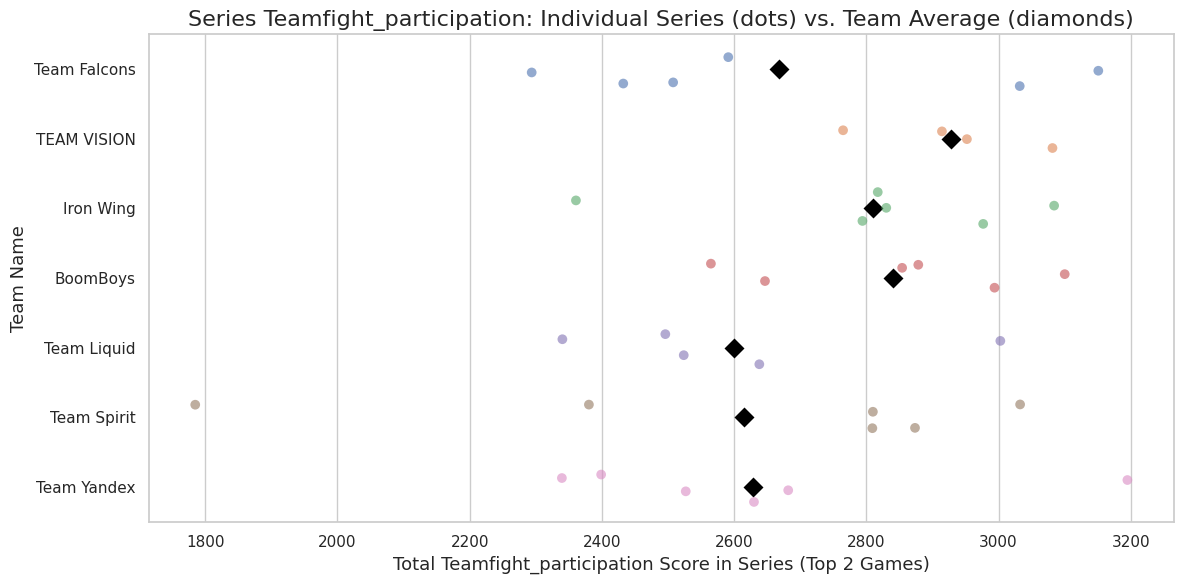

In [185]:
analyze_series_stat_by_team(df_cores, 'teamfight_participation')

### 1.2.2 Stuns

--- Top 3 Performances for Stuns ---


,Versus,playerName,stuns
216,Team Spirit vs Xtreme Gaming,Yatoro & Collapse,2174.385
18,BoomBoys vs TEAM VISION,Kiritych~ & MieRo,1958.685
171,Team Liquid vs Vici Gaming,Ace ♠ & m1CKe,1586.495


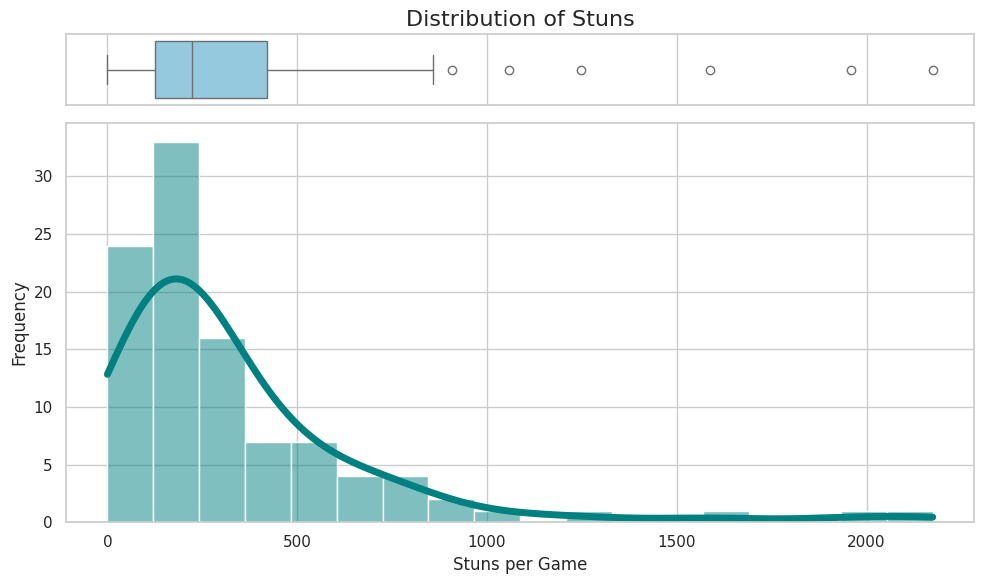

In [186]:
analyze_stat_performance(df_cores, 'stuns')

--- Top 3 Series (Sum of top 2 games) for Stuns ---


,Versus,teamName,stuns
5,Team Spirit vs Xtreme Gaming,Team Spirit,2280.545
14,BoomBoys vs TEAM VISION,BoomBoys,2102.180
4,Team Liquid vs Vici Gaming,Team Liquid,1921.160


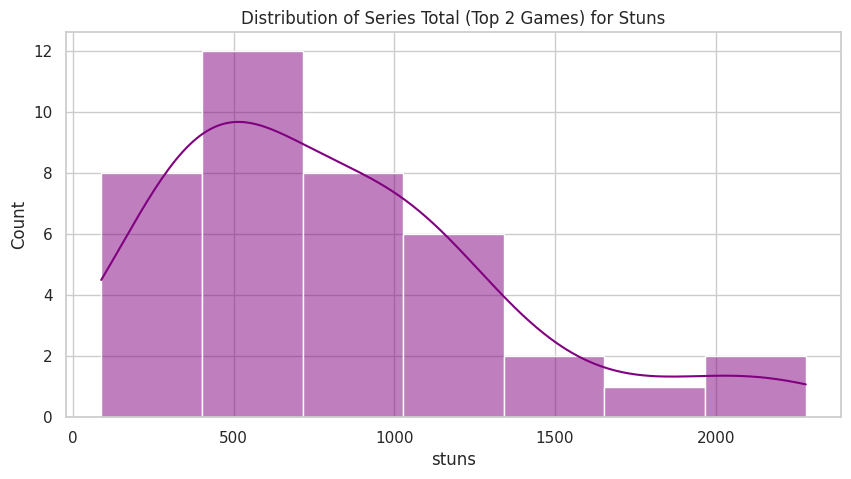

In [187]:
analyze_series_top2_stat(df_cores, 'stuns')

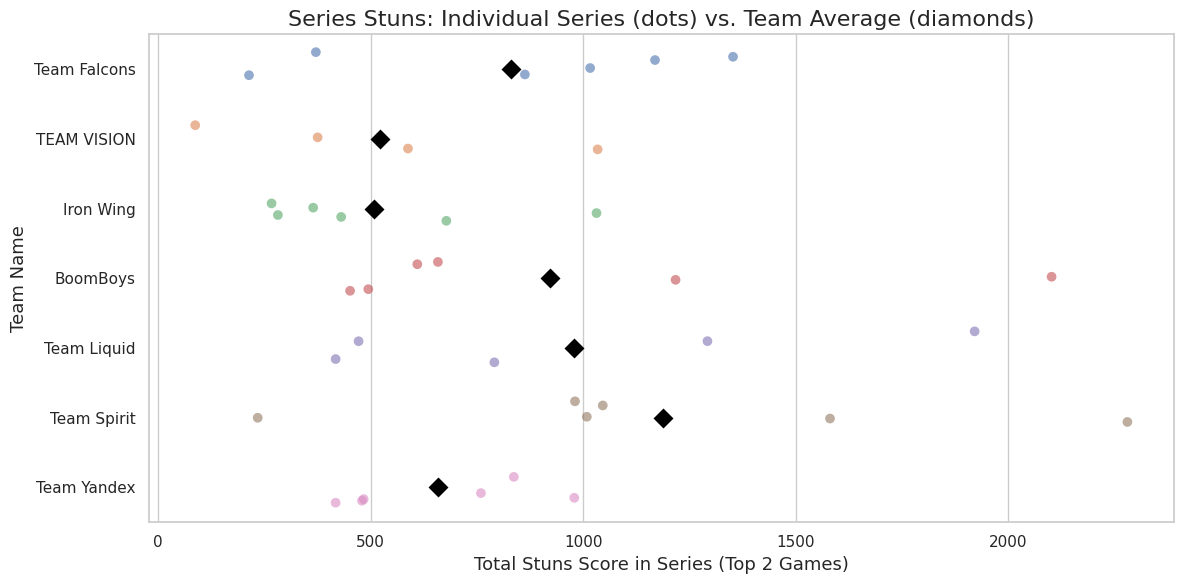

In [188]:
analyze_series_stat_by_team(df_cores, 'stuns')

### 1.2.3 First Blood Claimed

--- Top 3 Performances for Firstblood_claimed ---


,Versus,playerName,firstblood_claimed
0,BoomBoys vs OG,Kiritych~ & MieRo,967.0
54,BoomBoys vs Iron Wing,33 & Pure,967.0
63,Iron Wing vs Team Falcons,33 & Pure,967.0


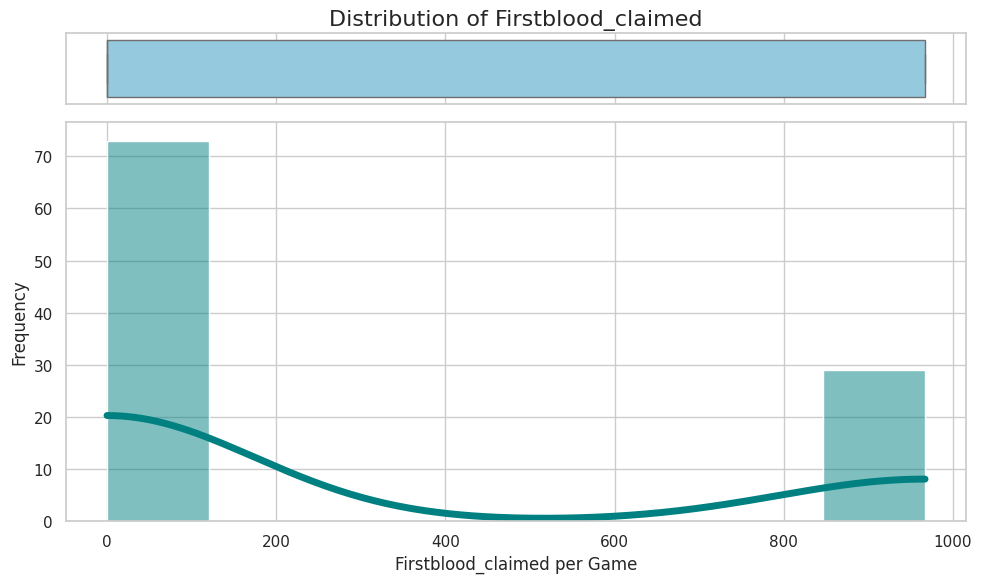

In [189]:
analyze_stat_performance(df_cores, 'firstblood_claimed')

--- Top 3 Series (Sum of top 2 games) for Firstblood_claimed ---


,Versus,teamName,firstblood_claimed
1,TEAM VISION vs Team Resilience,TEAM VISION,1934.0
2,Iron Wing vs Nigma Galaxy,Iron Wing,1934.0
8,BoomBoys vs Iron Wing,Iron Wing,1934.0


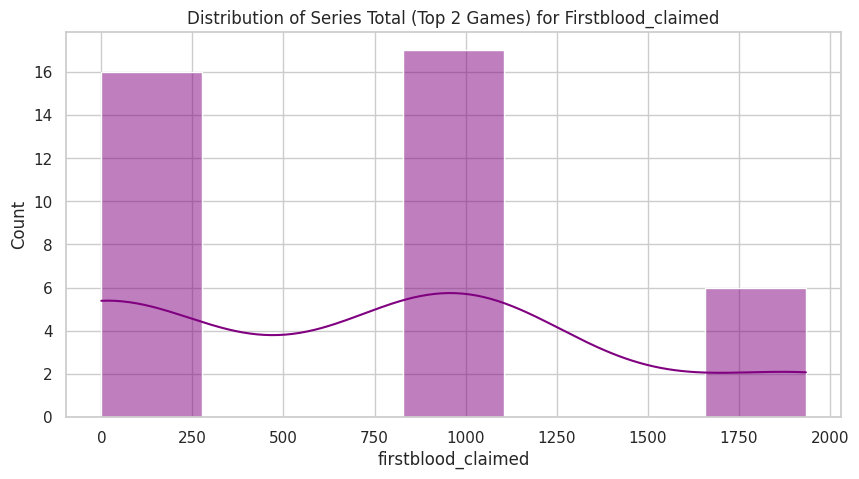

In [190]:
analyze_series_top2_stat(df_cores, 'firstblood_claimed')

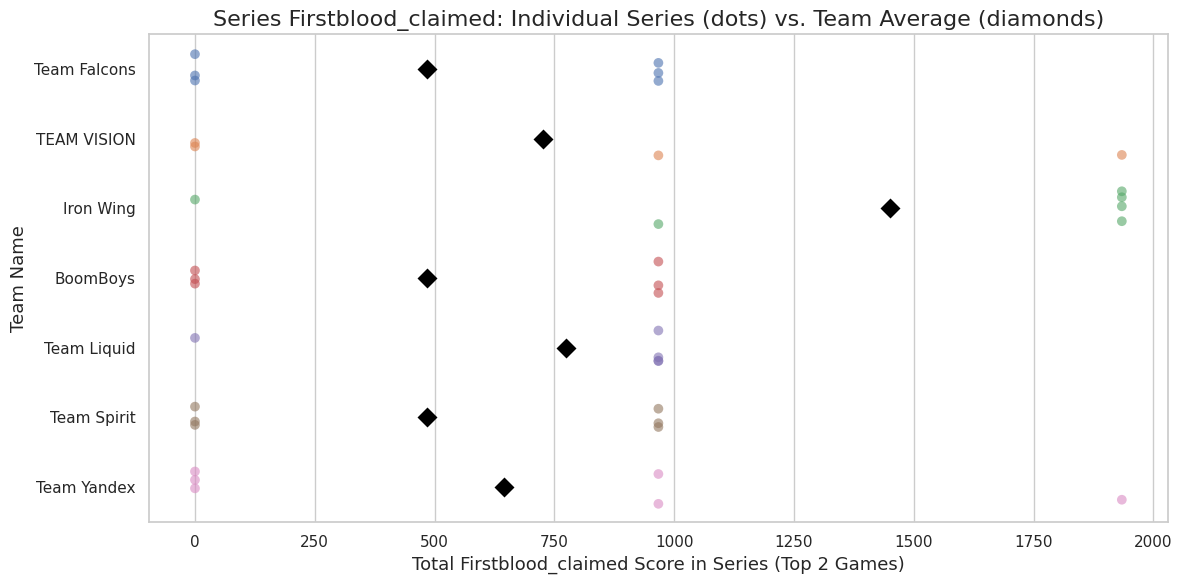

In [191]:
analyze_series_stat_by_team(df_cores, 'firstblood_claimed')

### 1.2.4 Roshan Kills

--- Top 3 Performances for Roshan_kills ---


,Versus,playerName,roshan_kills
135,TEAM VISION vs Team Falcons,skiter & AMMAR_THE_F,2344.0
12,BoomBoys vs Iron Wing,Kiritych~ & MieRo,1758.0
93,TEAM VISION vs Team Resilience,Satanic & Noticed,1758.0


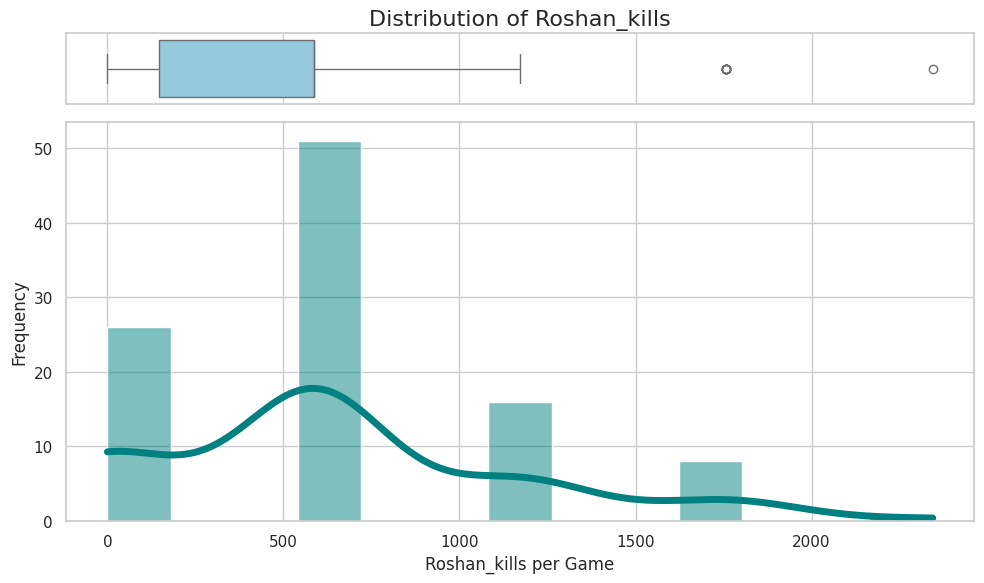

In [192]:
analyze_stat_performance(df_cores, 'roshan_kills')

--- Top 3 Series (Sum of top 2 games) for Roshan_kills ---


,Versus,teamName,roshan_kills
7,BoomBoys vs Iron Wing,BoomBoys,3516.0
10,TEAM VISION vs Team Falcons,Team Falcons,3516.0
8,BoomBoys vs Iron Wing,Iron Wing,2930.0


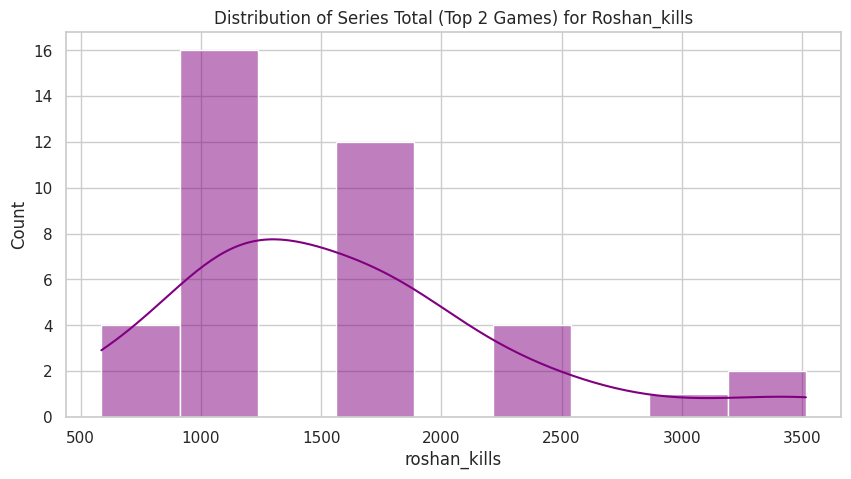

In [193]:
analyze_series_top2_stat(df_cores, 'roshan_kills')

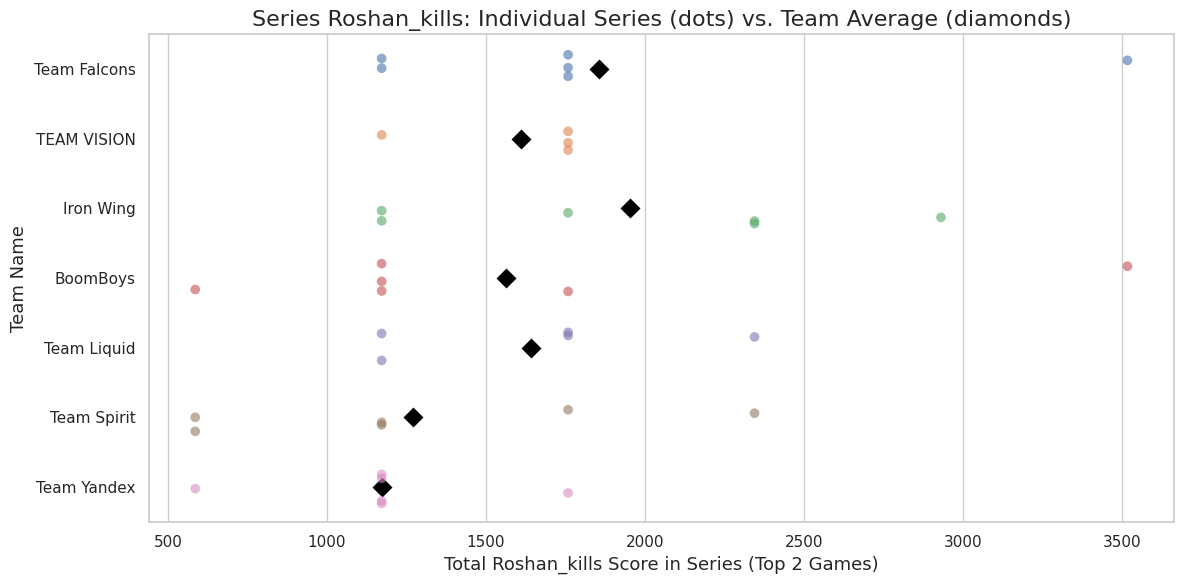

In [194]:
analyze_series_stat_by_team(df_cores, 'roshan_kills')

### 1.2.5 Tormentor Kills

--- Top 3 Performances for Tormentor_kills ---


,Versus,playerName,tormentor_kills
237,TEAM VISION vs Team Spirit,Yatoro & Collapse,1318.5
171,Team Liquid vs Vici Gaming,Ace ♠ & m1CKe,1318.5
216,Team Spirit vs Xtreme Gaming,Yatoro & Collapse,1318.5


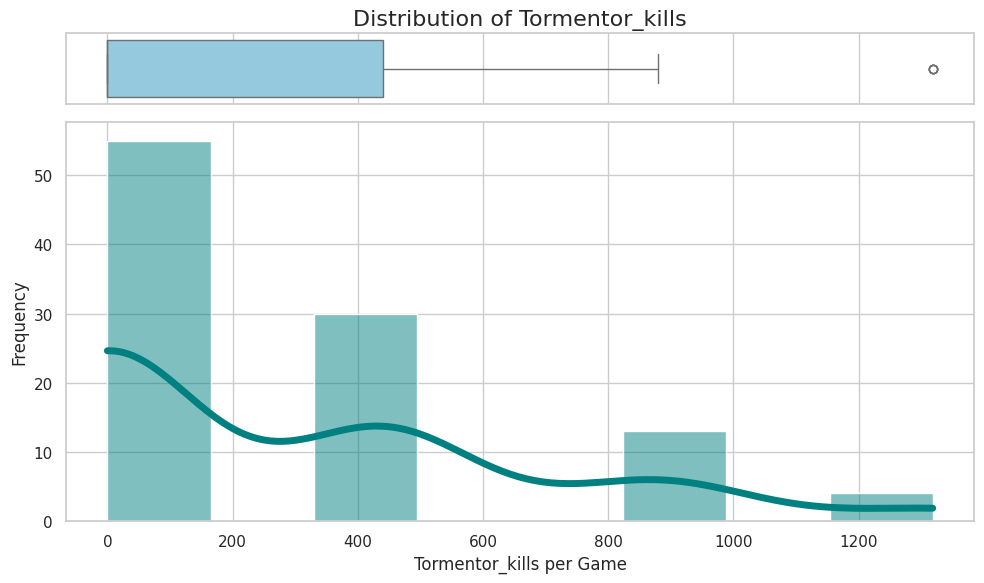

In [195]:
analyze_stat_performance(df_cores, 'tormentor_kills')

--- Top 3 Series (Sum of top 2 games) for Tormentor_kills ---


,Versus,teamName,tormentor_kills
4,Team Liquid vs Vici Gaming,Team Liquid,2197.5
19,Team Liquid vs Team Spirit,Team Spirit,2197.5
5,Team Spirit vs Xtreme Gaming,Team Spirit,1758.0


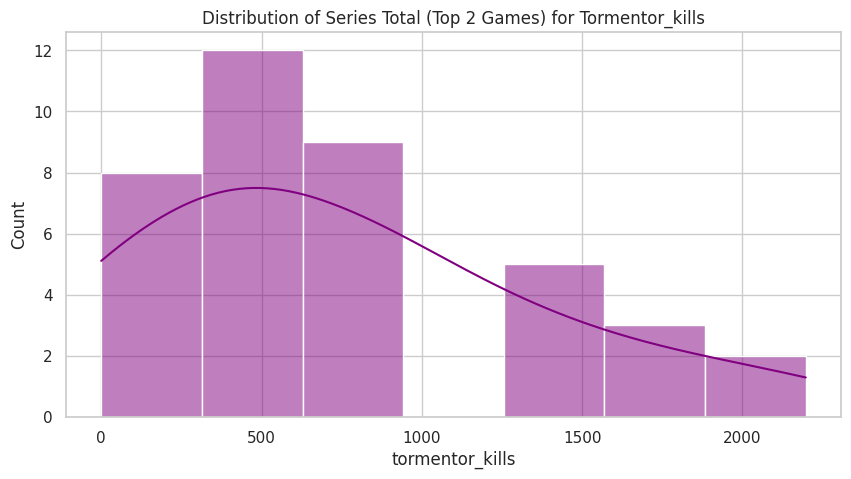

In [196]:
analyze_series_top2_stat(df_cores, 'tormentor_kills')

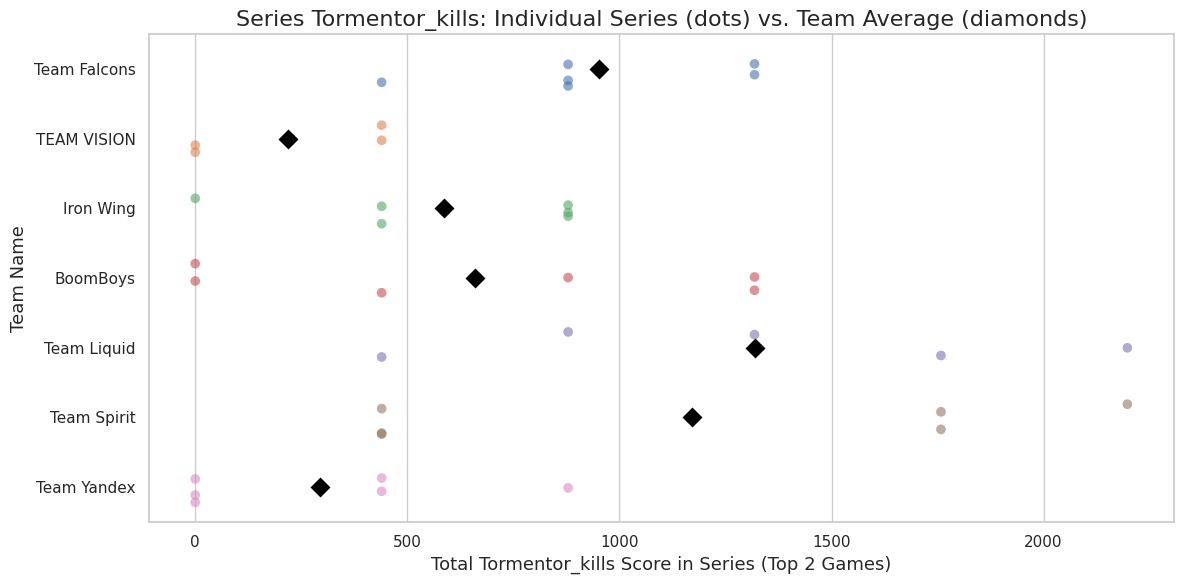

In [197]:
analyze_series_stat_by_team(df_cores, 'tormentor_kills')

### 1.2.6 Courier Kills

--- Top 3 Performances for Courier_kills ---


,Versus,playerName,courier_kills
249,Team Resilience vs Team Spirit,Yatoro & Collapse,1757.5
135,TEAM VISION vs Team Falcons,skiter & AMMAR_THE_F,1054.5
270,Aurora Gaming vs Team Yandex,医者watson` & DM,1054.5


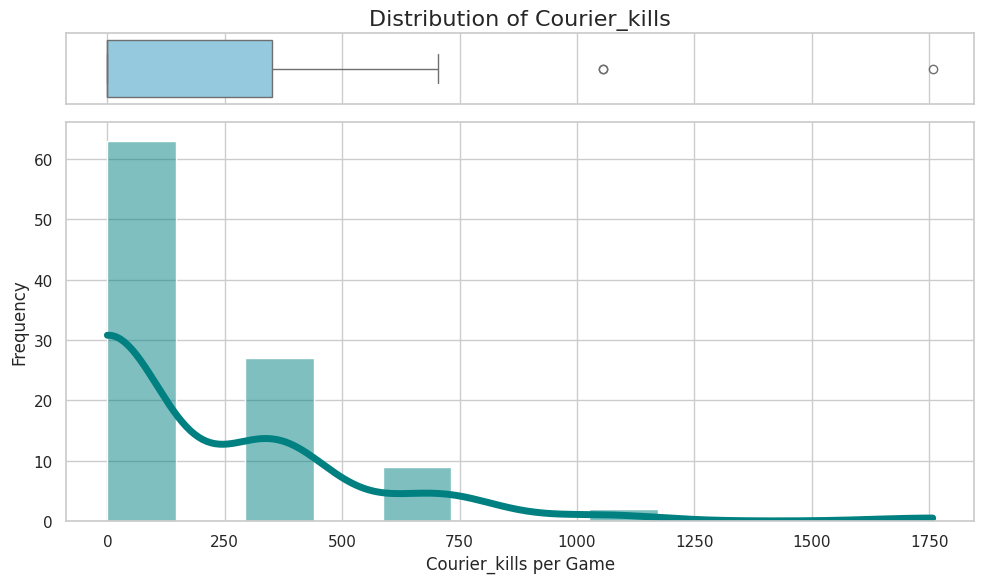

In [198]:
analyze_stat_performance(df_cores, 'courier_kills')

--- Top 3 Series (Sum of top 2 games) for Courier_kills ---


,Versus,teamName,courier_kills
36,Team Resilience vs Team Spirit,Team Spirit,2460.5
10,TEAM VISION vs Team Falcons,Team Falcons,1757.5
2,Iron Wing vs Nigma Galaxy,Iron Wing,1054.5


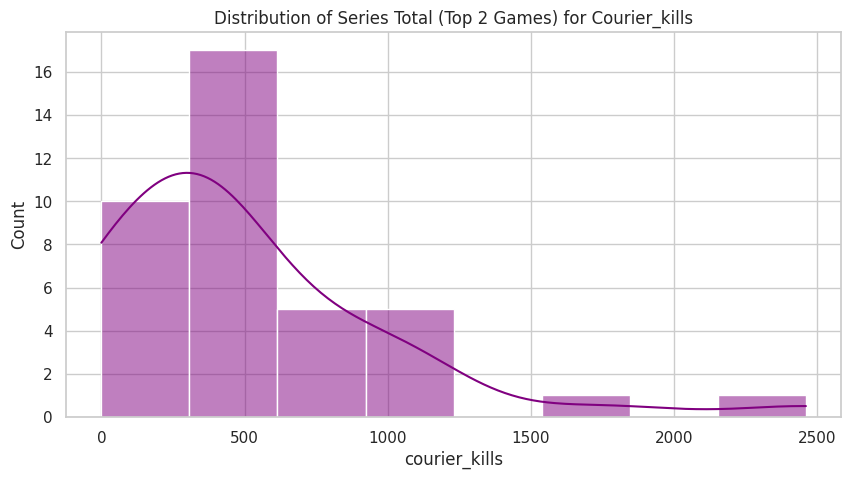

In [199]:
analyze_series_top2_stat(df_cores, 'courier_kills')

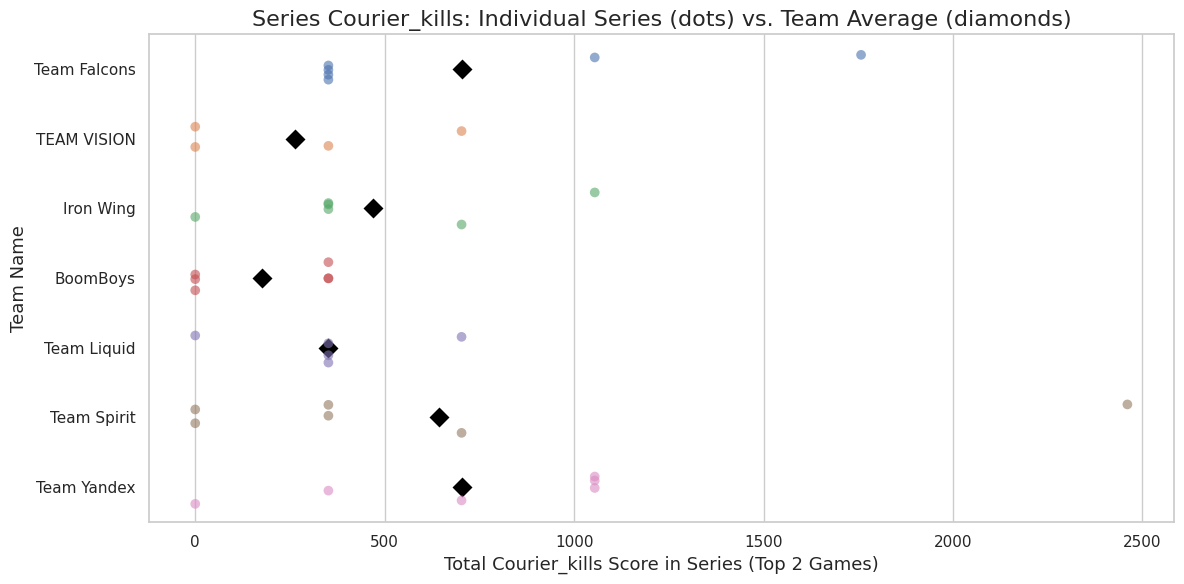

In [200]:
analyze_series_stat_by_team(df_cores, 'courier_kills')

## 1.3 Overall

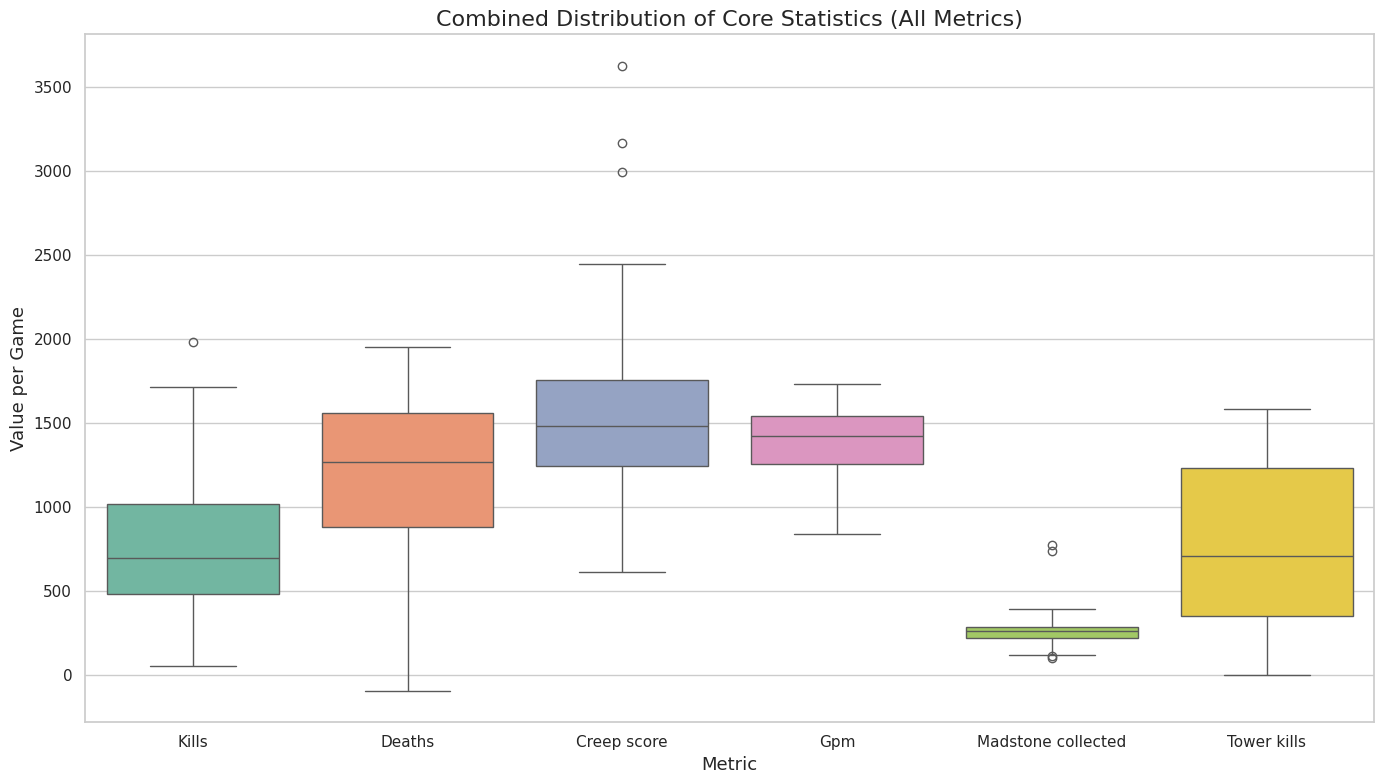

In [201]:
# List of stats to consolidate
stats_to_plot = ['kills', 'deaths', 'creep_score', 'gpm', 'madstone_collected', 'tower_kills']

# Prepare data by melting into long-form
df_melted = df_cores.melt(value_vars=stats_to_plot, var_name='Statistic', value_name='Value')
df_melted['Statistic'] = df_melted['Statistic'].str.replace('_', ' ').str.capitalize()

# Create a single combined vertical boxplot
plt.figure(figsize=(14, 8))
# Using 'Set2' for a softer, more eye-friendly color palette
sns.set_theme(style="whitegrid")
sns.boxplot(data=df_melted, x='Statistic', y='Value', hue='Statistic', palette="Set2", legend=False)

plt.title('Combined Distribution of Core Statistics (All Metrics)', fontsize=16)
plt.xlabel('Metric', fontsize=13)
plt.ylabel('Value per Game', fontsize=13)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

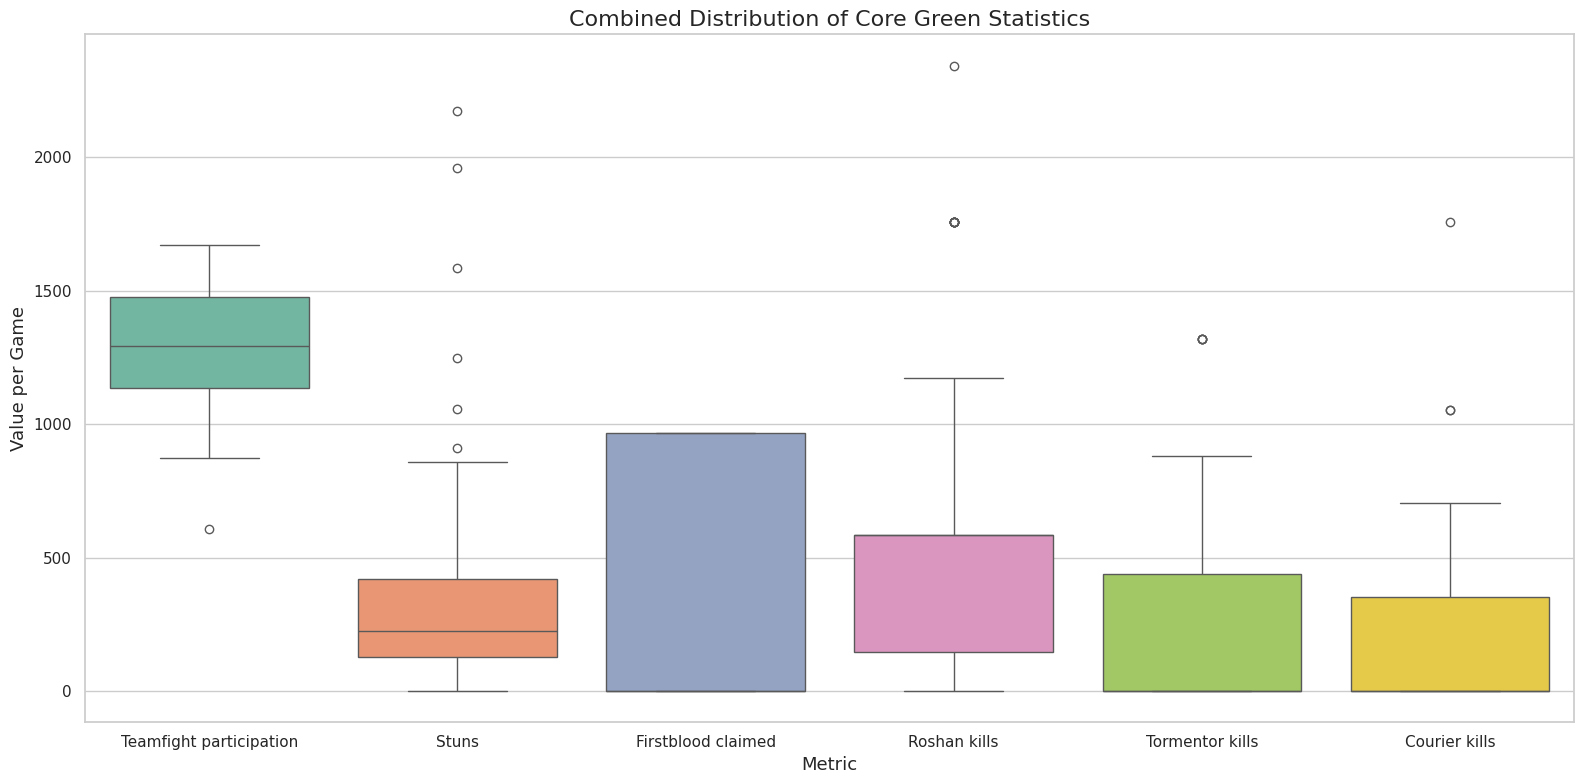

In [202]:
# List of 'Green' stats to consolidate
green_stats = [
    'teamfight_participation', 'stuns', 'firstblood_claimed',
    'roshan_kills', 'tormentor_kills', 'courier_kills'
]

# Prepare data by melting into long-form
df_green_melted = df_cores.melt(value_vars=green_stats, var_name='Statistic', value_name='Value')
df_green_melted['Statistic'] = df_green_melted['Statistic'].str.replace('_', ' ').str.capitalize()

# Create the combined vertical boxplot
plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")
sns.boxplot(data=df_green_melted, x='Statistic', y='Value', hue='Statistic', palette="Set2", legend=False)

plt.title('Combined Distribution of Core Green Statistics', fontsize=16)
plt.xlabel('Metric', fontsize=13)
plt.ylabel('Value per Game', fontsize=13)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. Mids

## 2.1 Red Stats

### 2.1.1 Creep Score

--- Top 3 Performances for Creep_score ---


,Versus,playerName,creep_score
136,TEAM VISION vs Team Falcons,Malr1ne,3237.0
106,TEAM VISION vs Team Falcons,No[o]ne-,2559.0
172,Team Liquid vs Vici Gaming,Nisha,2274.0


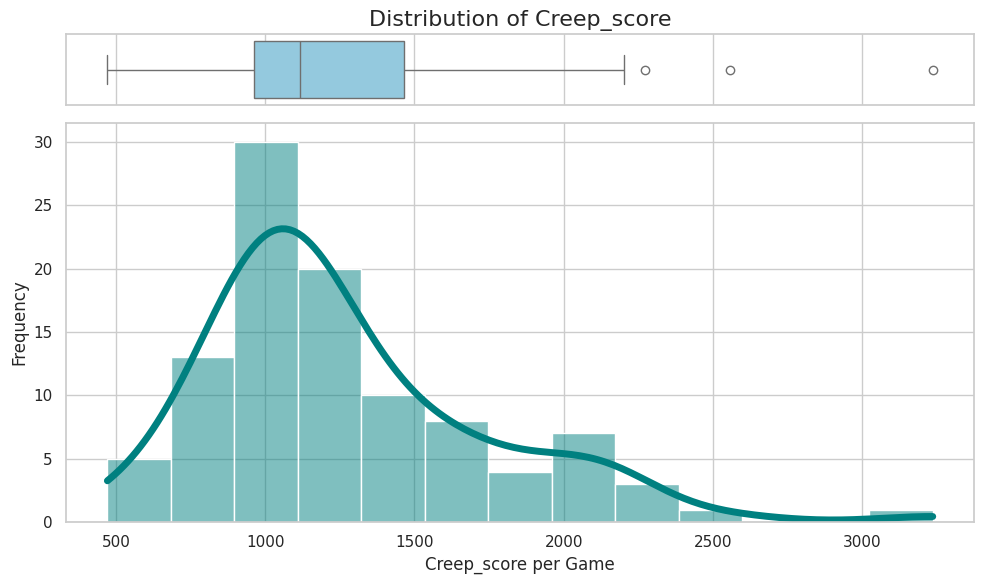

In [203]:
analyze_stat_performance(df_mids, 'creep_score')

--- Top 3 Series (Sum of top 2 games) for Creep_score ---


,Versus,teamName,creep_score
10,TEAM VISION vs Team Falcons,Team Falcons,4491.0
33,Nigma Galaxy vs Team Spirit,Team Spirit,4227.0
9,TEAM VISION vs Team Falcons,TEAM VISION,3924.0


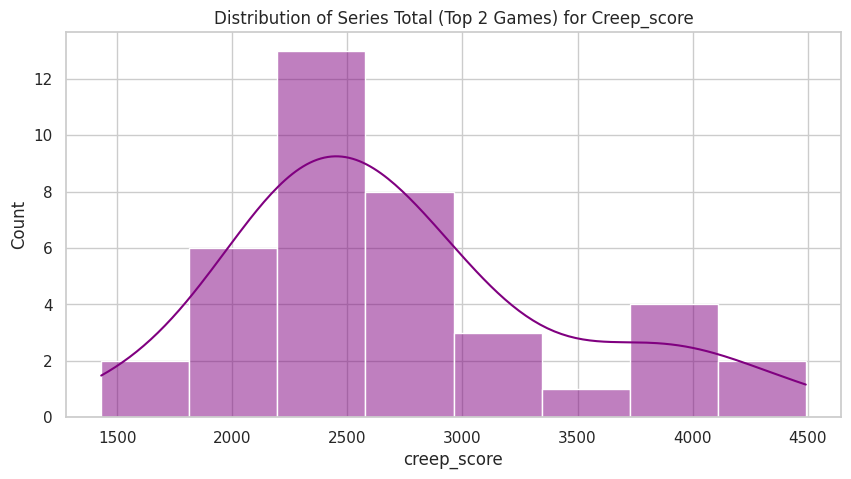

In [204]:
analyze_series_top2_stat(df_mids, 'creep_score')

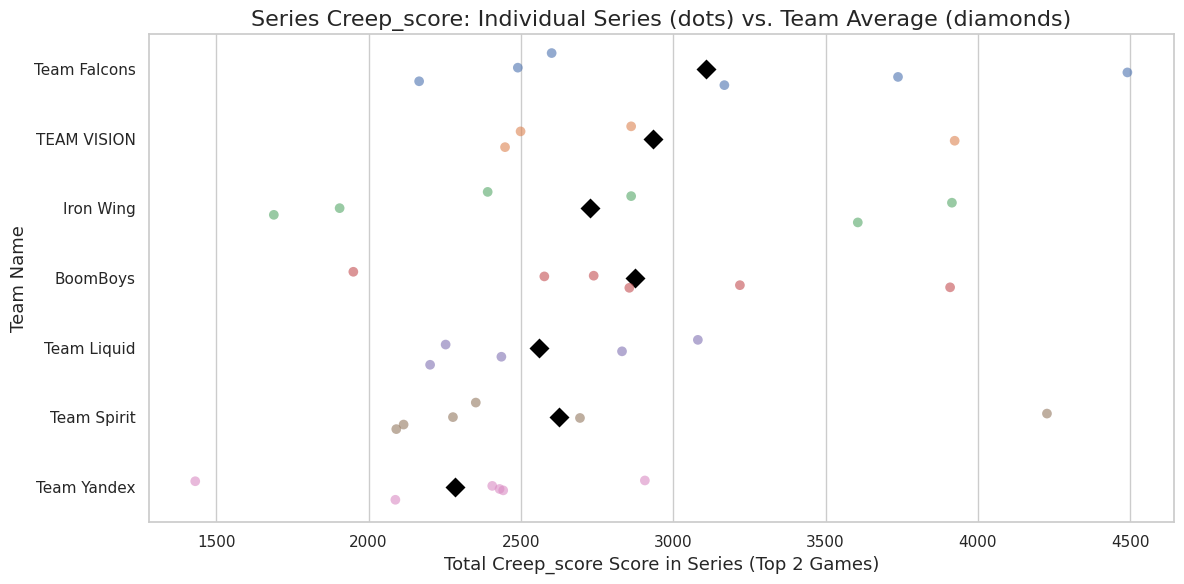

In [205]:
analyze_series_stat_by_team(df_mids, 'creep_score')

### 2.1.2 GPM

--- Top 3 Performances for Gpm ---


,Versus,playerName,gpm
61,Iron Wing vs Team Falcons,bzm,1724.0
136,TEAM VISION vs Team Falcons,Malr1ne,1684.0
172,Team Liquid vs Vici Gaming,Nisha,1590.0


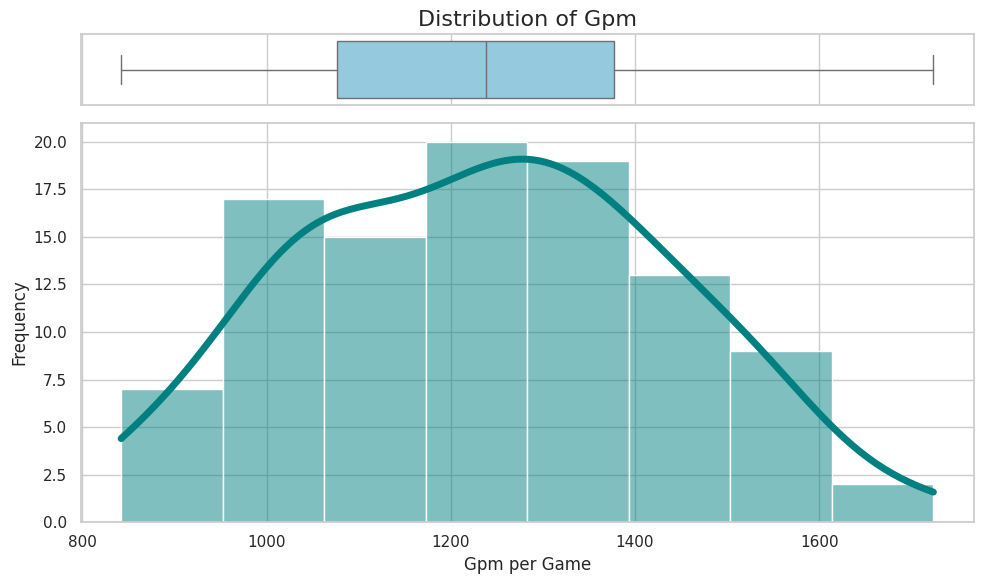

In [206]:
analyze_stat_performance(df_mids, 'gpm')

--- Top 3 Series (Sum of top 2 games) for Gpm ---


,Versus,teamName,gpm
16,Iron Wing vs Team Falcons,Iron Wing,3150.0
17,Iron Wing vs Team Falcons,Team Falcons,3126.0
10,TEAM VISION vs Team Falcons,Team Falcons,2922.0


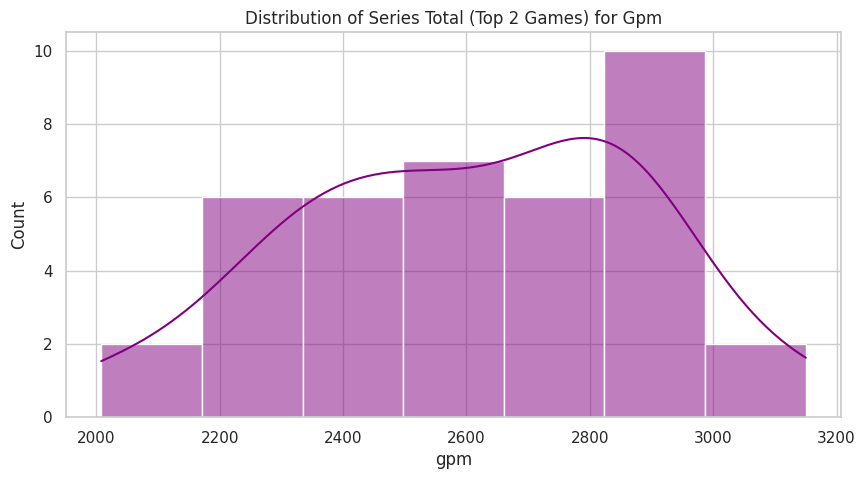

In [207]:
analyze_series_top2_stat(df_mids, 'gpm')

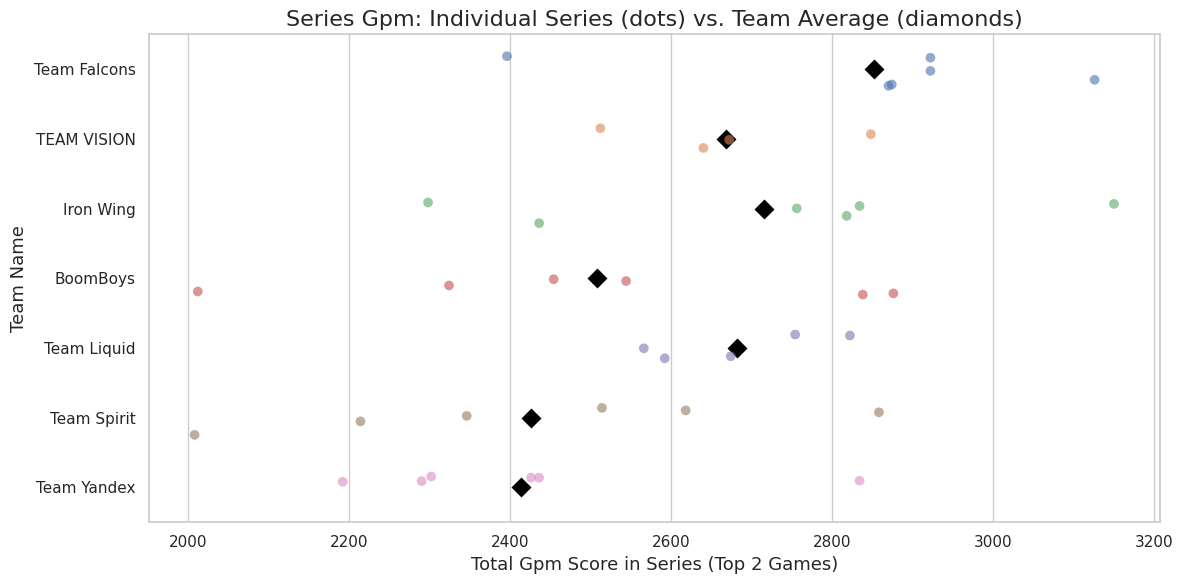

In [208]:
analyze_series_stat_by_team(df_mids, 'gpm')

### 2.1.3 Deaths

--- Top 3 Performances for Deaths ---


,Versus,playerName,deaths
175,Team Liquid vs Vici Gaming,Nisha,1950.0
115,TEAM VISION vs Team Spirit,No[o]ne-,1950.0
256,HULIGANI vs Team Yandex,CHIRA_JUNIOR,1950.0


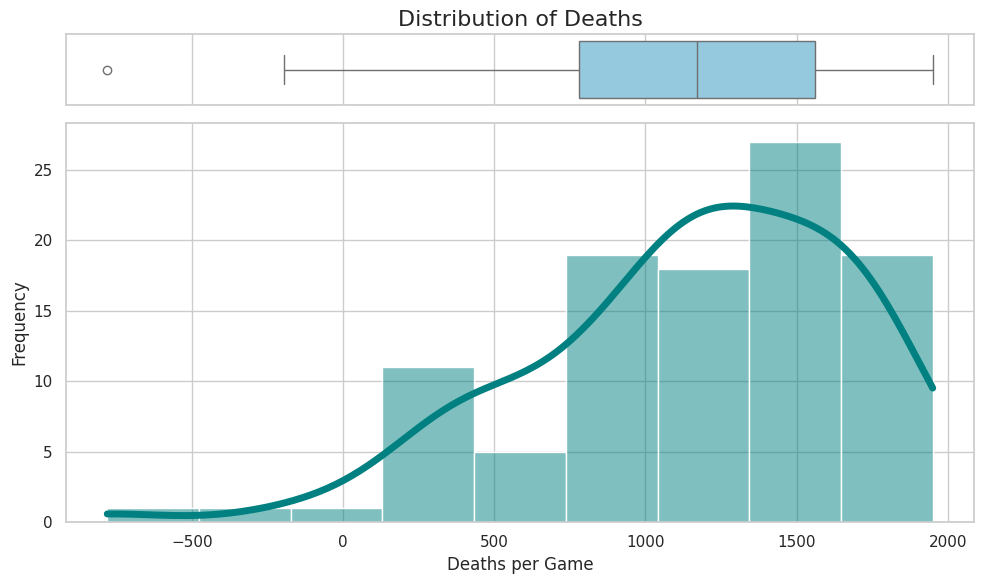

In [209]:
analyze_stat_performance(df_mids, 'deaths')

--- Top 3 Series (Sum of top 2 games) for Deaths ---


,Versus,teamName,deaths
26,TEAM VISION vs Team Spirit,TEAM VISION,3705.0
21,Team Resilience vs Team Yandex,Team Yandex,3510.0
6,HULIGANI vs Team Yandex,Team Yandex,3510.0


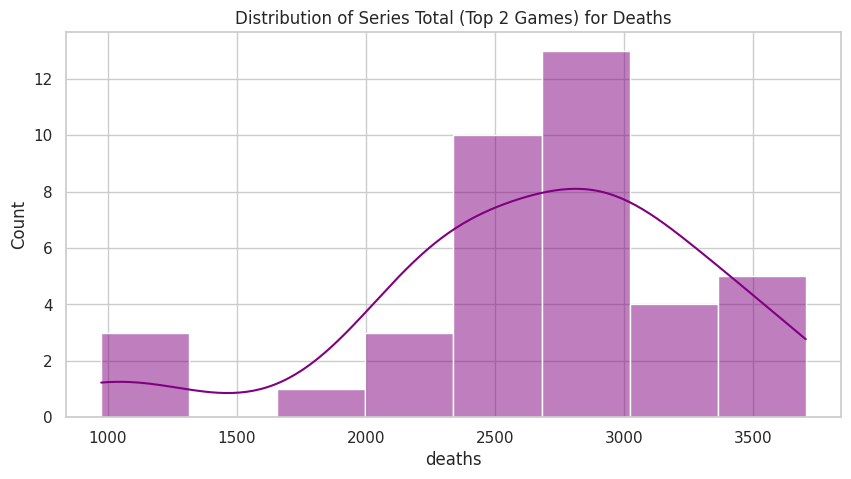

In [210]:
analyze_series_top2_stat(df_mids, 'deaths')

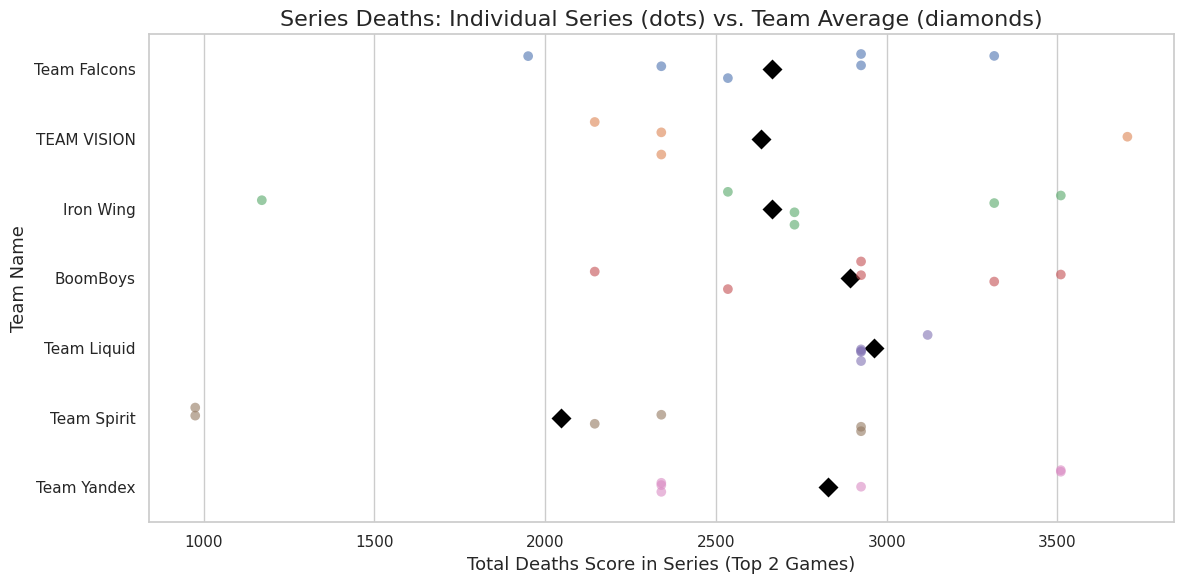

In [211]:
analyze_series_stat_by_team(df_mids, 'deaths')

### 2.1.4 Kills

--- Top 3 Performances for Kills ---


,Versus,playerName,kills
214,Team Spirit vs Xtreme Gaming,Larl,2354.0
106,TEAM VISION vs Team Falcons,No[o]ne-,1926.0
139,Iron Wing vs Team Falcons,Malr1ne,1819.0


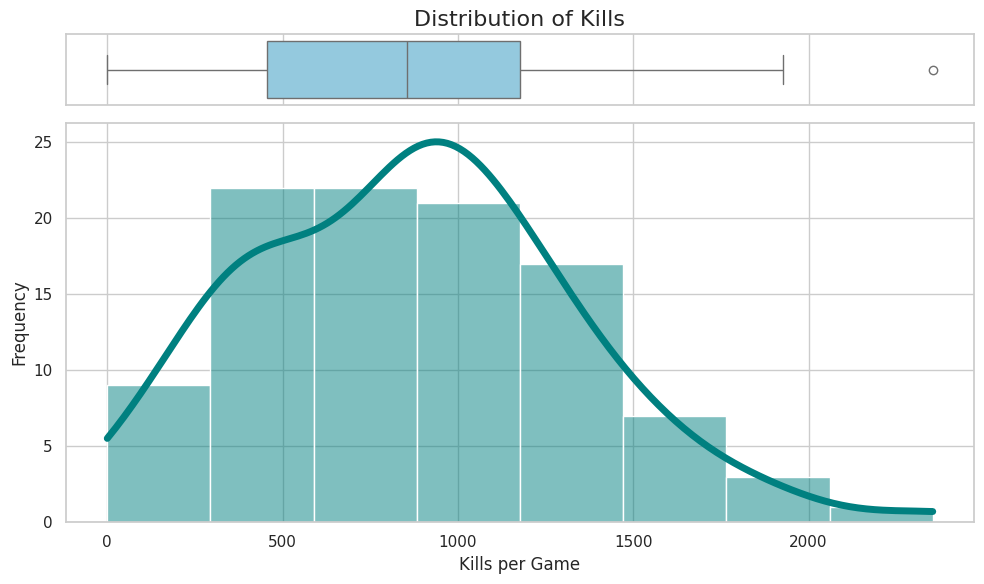

In [212]:
analyze_stat_performance(df_mids, 'kills')

--- Top 3 Series (Sum of top 2 games) for Kills ---


,Versus,teamName,kills
17,Iron Wing vs Team Falcons,Team Falcons,3317.0
9,TEAM VISION vs Team Falcons,TEAM VISION,2996.0
5,Team Spirit vs Xtreme Gaming,Team Spirit,2782.0


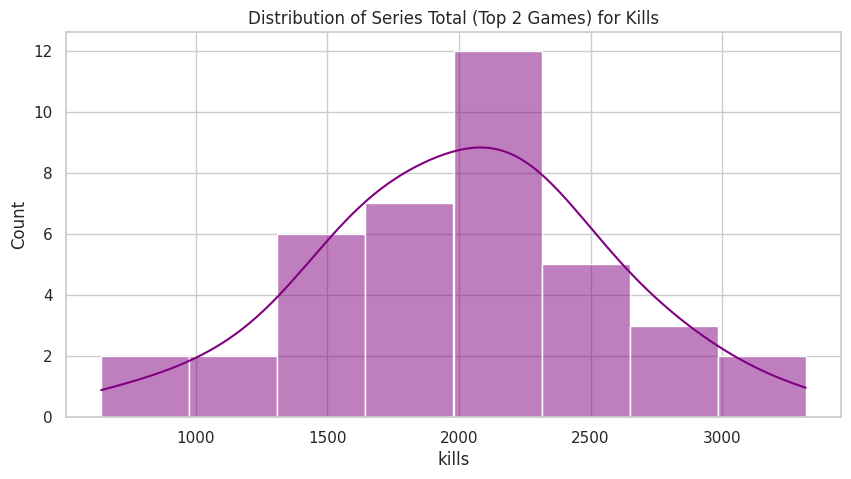

In [213]:
analyze_series_top2_stat(df_mids, 'kills')

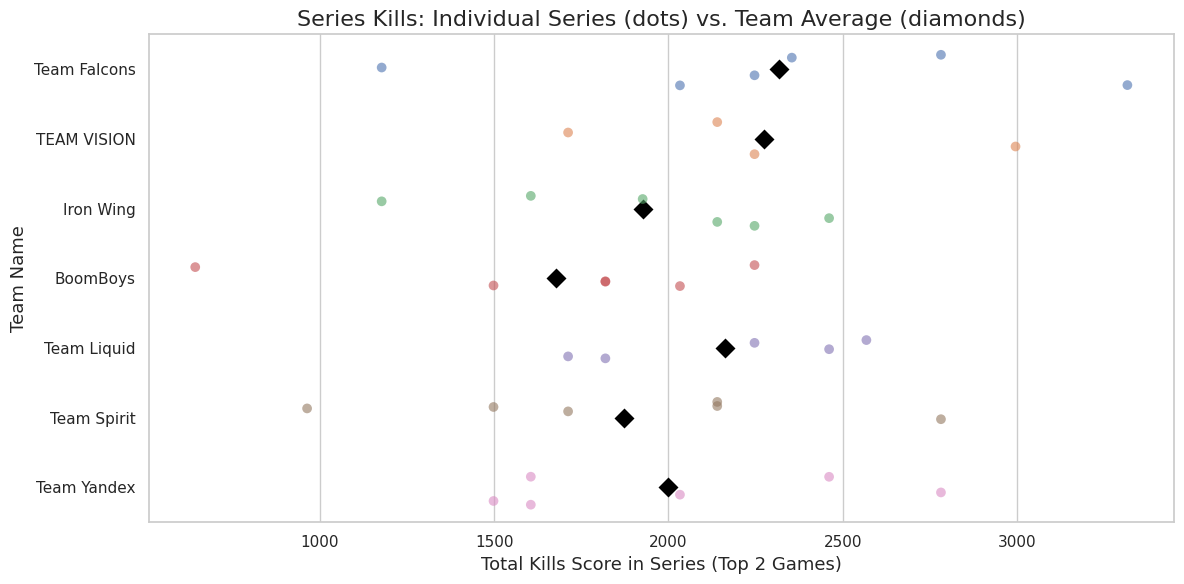

In [214]:
analyze_series_stat_by_team(df_mids, 'kills')

### 2.1.5 Madstone Collected

--- Top 3 Performances for Madstone_collected ---


,Versus,playerName,madstone_collected
106,TEAM VISION vs Team Falcons,No[o]ne-,364.0
19,BoomBoys vs TEAM VISION,gpk~,364.0
34,BoomBoys vs Team Falcons,gpk~,299.0


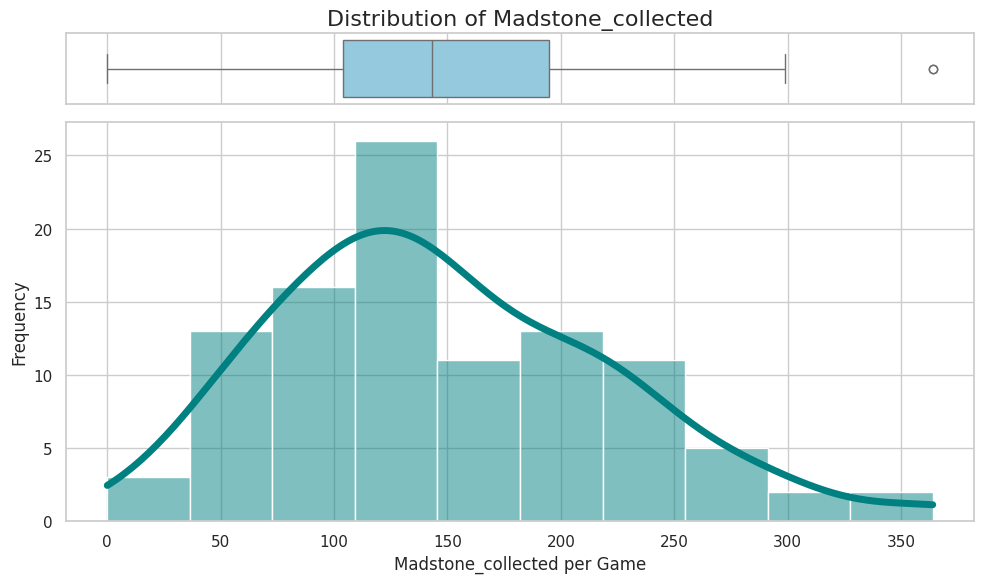

In [215]:
analyze_stat_performance(df_mids, 'madstone_collected')

--- Top 3 Series (Sum of top 2 games) for Madstone_collected ---


,Versus,teamName,madstone_collected
9,TEAM VISION vs Team Falcons,TEAM VISION,559.0
7,BoomBoys vs Iron Wing,BoomBoys,520.0
10,TEAM VISION vs Team Falcons,Team Falcons,520.0


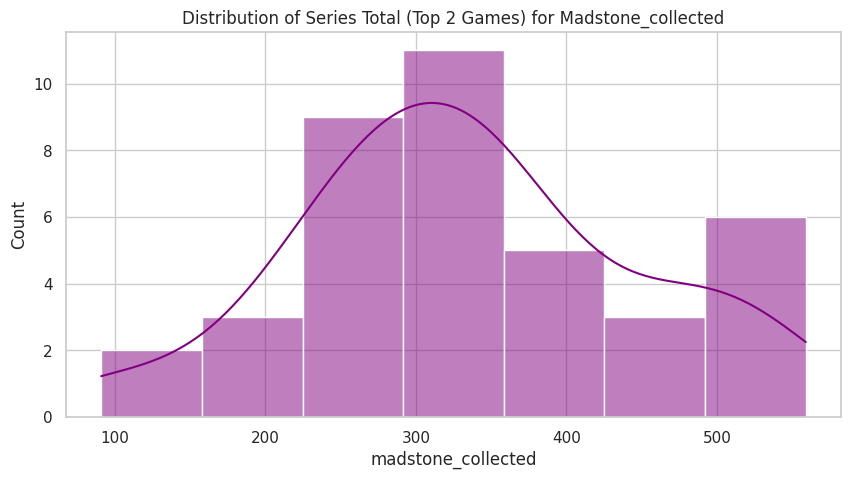

In [216]:
analyze_series_top2_stat(df_mids, 'madstone_collected')

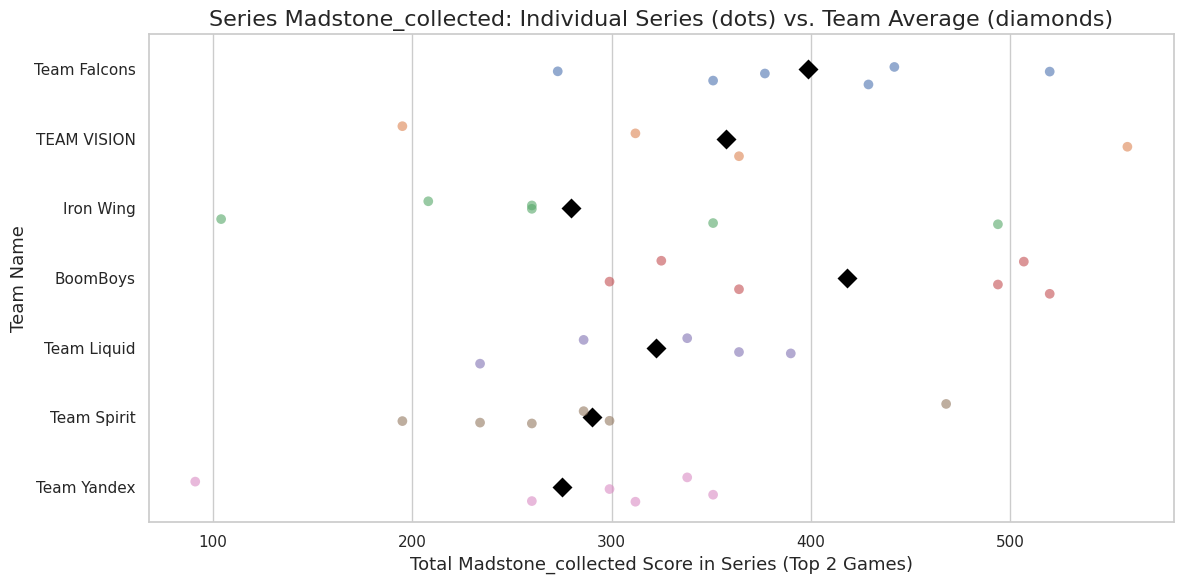

In [217]:
analyze_series_stat_by_team(df_mids, 'madstone_collected')

### 2.1.6 Tower Kills

--- Top 3 Performances for Tower_kills ---


,Versus,playerName,tower_kills
4,BoomBoys vs OG,gpk~,2464.0
142,Iron Wing vs Team Falcons,Malr1ne,2112.0
121,LGD Gaming vs Team Falcons,Malr1ne,1760.0


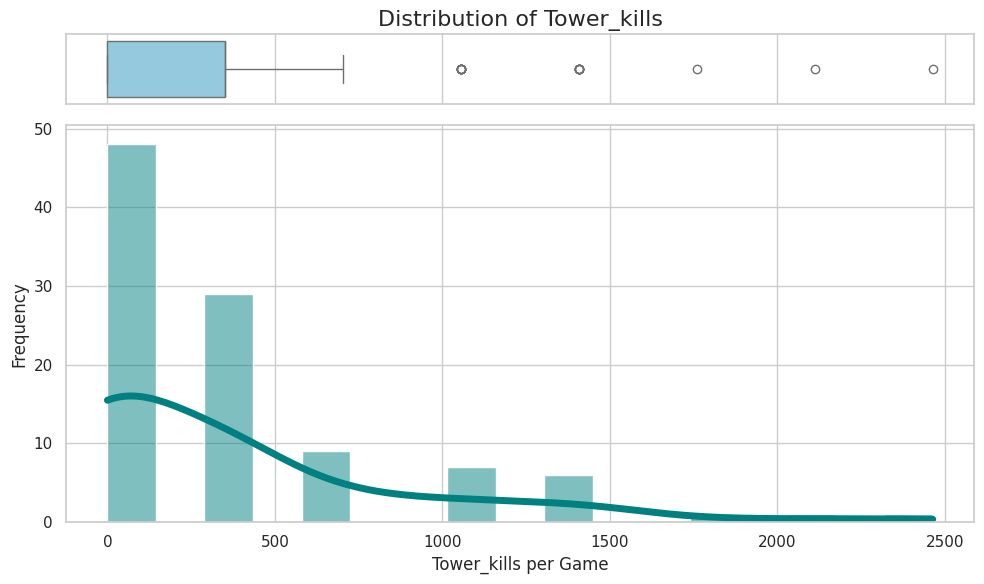

In [218]:
analyze_stat_performance(df_mids, 'tower_kills')

--- Top 3 Series (Sum of top 2 games) for Tower_kills ---


,Versus,teamName,tower_kills
0,LGD Gaming vs Team Falcons,Team Falcons,3168.0
3,BoomBoys vs OG,BoomBoys,2464.0
17,Iron Wing vs Team Falcons,Team Falcons,2464.0


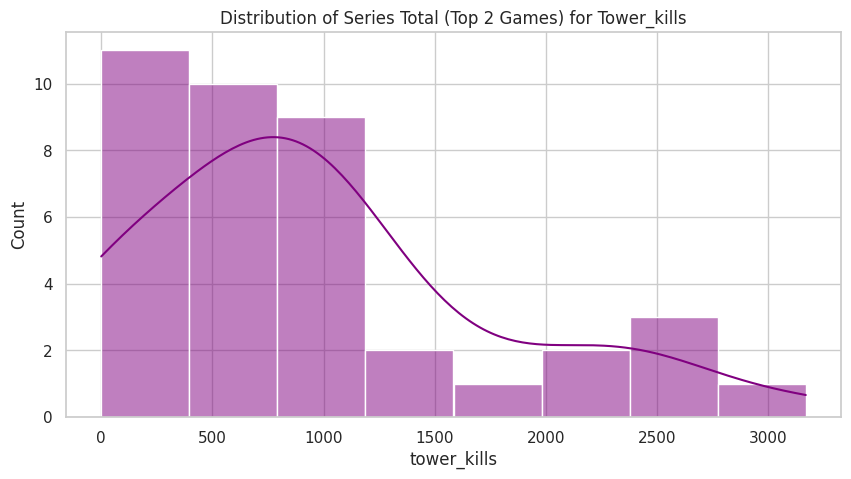

In [219]:
analyze_series_top2_stat(df_mids, 'tower_kills')

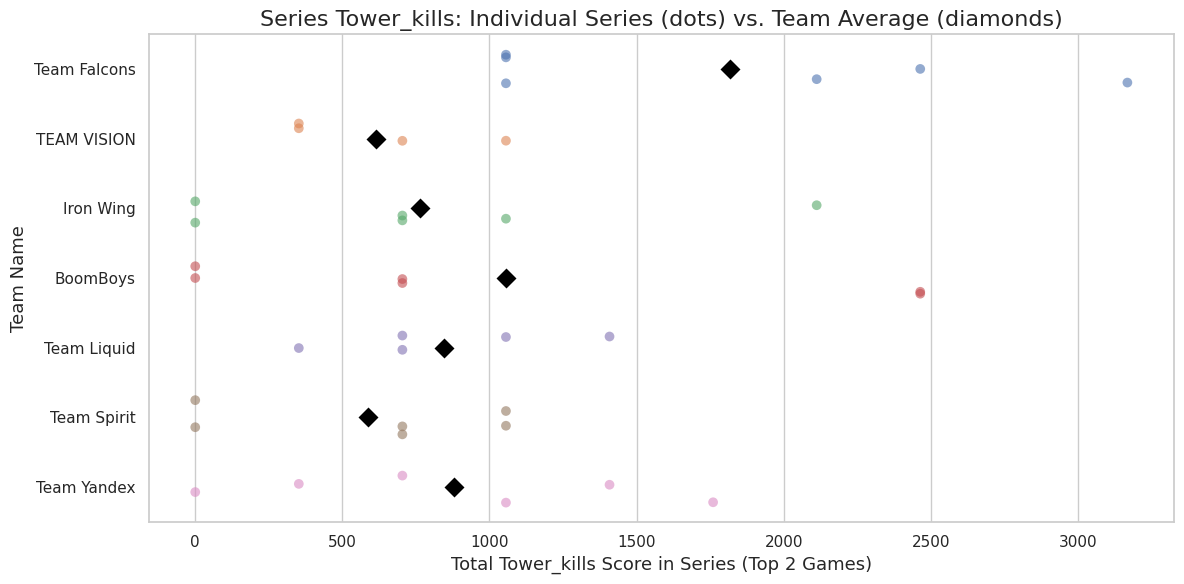

In [220]:
analyze_series_stat_by_team(df_mids, 'tower_kills')

## 2.2 Green Stats

### 2.2.1 Teamfight Participation

--- Top 3 Performances for Teamfight_participation ---


,Versus,playerName,teamfight_participation
157,BoomBoys vs Team Falcons,Malr1ne,2124.00
196,Iron Wing vs Team Liquid,Nisha,2039.04
304,LGD Gaming vs Team Yandex,CHIRA_JUNIOR,2017.80


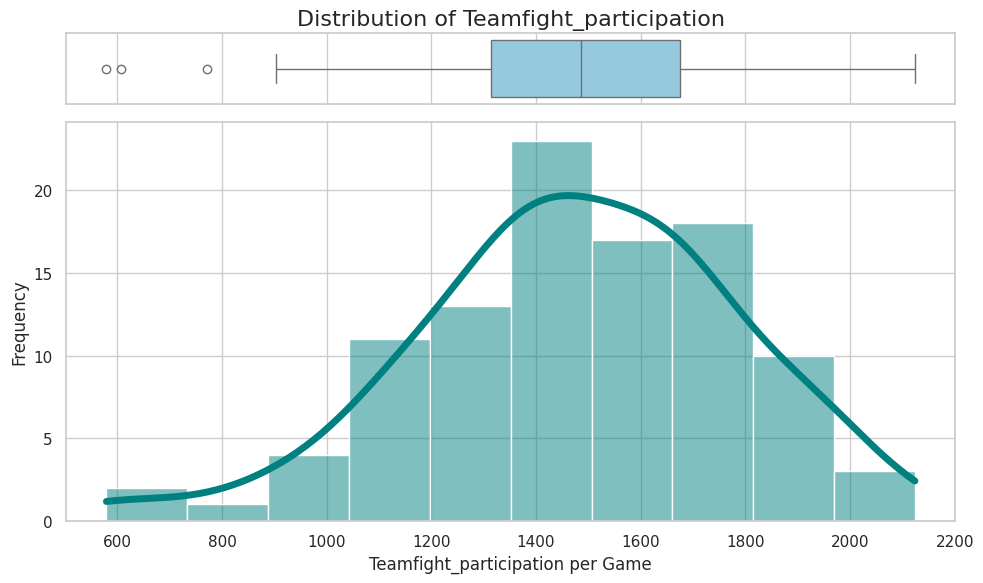

In [221]:
analyze_stat_performance(df_mids, 'teamfight_participation')

--- Top 3 Series (Sum of top 2 games) for Teamfight_participation ---


,Versus,teamName,teamfight_participation
18,Team Liquid vs Team Spirit,Team Liquid,3870.21
29,BoomBoys vs Team Falcons,Team Falcons,3823.20
24,Iron Wing vs Team Liquid,Team Liquid,3761.20


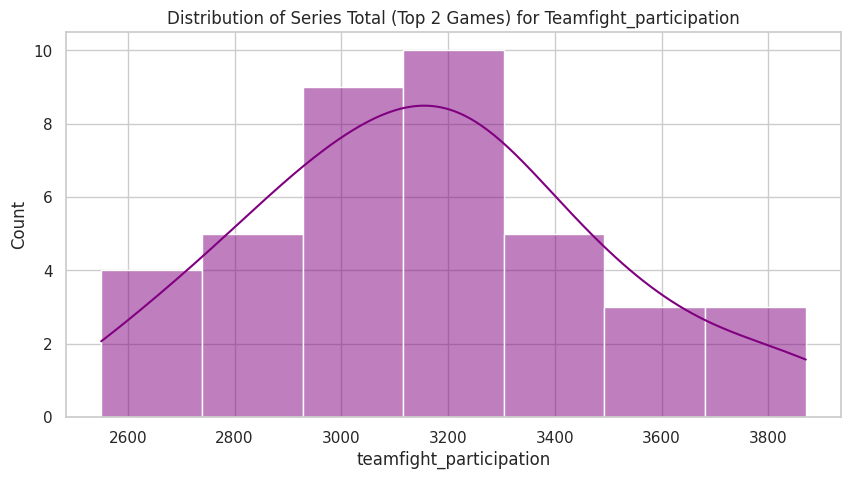

In [222]:
analyze_series_top2_stat(df_mids, 'teamfight_participation')

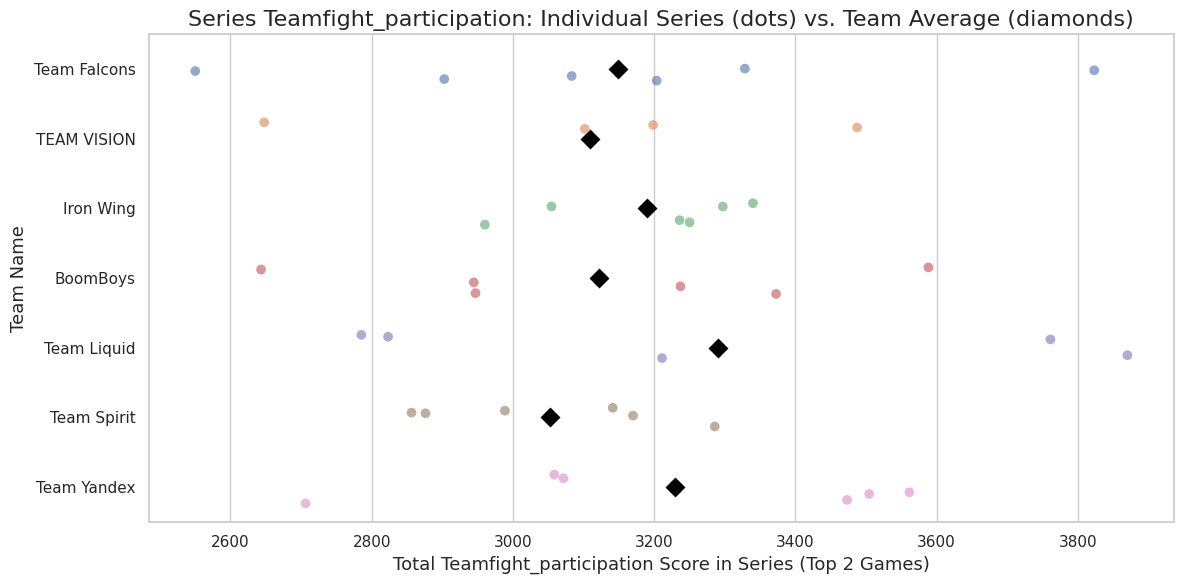

In [223]:
analyze_series_stat_by_team(df_mids, 'teamfight_participation')

### 2.2.2 Stuns

--- Top 3 Performances for Stuns ---


,Versus,playerName,stuns
49,BoomBoys vs Iron Wing,bzm,1654.99
244,Nigma Galaxy vs Team Spirit,Larl,1616.69
19,BoomBoys vs TEAM VISION,gpk~,1285.71


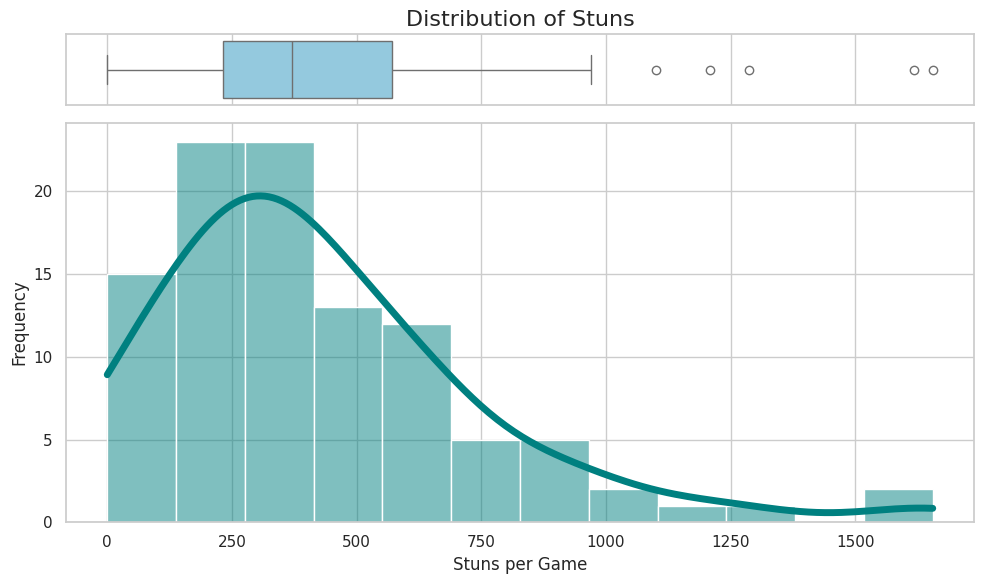

In [224]:
analyze_stat_performance(df_mids, 'stuns')

--- Top 3 Series (Sum of top 2 games) for Stuns ---


,Versus,teamName,stuns
8,BoomBoys vs Iron Wing,Iron Wing,2754.30
33,Nigma Galaxy vs Team Spirit,Team Spirit,2257.35
9,TEAM VISION vs Team Falcons,TEAM VISION,2062.30


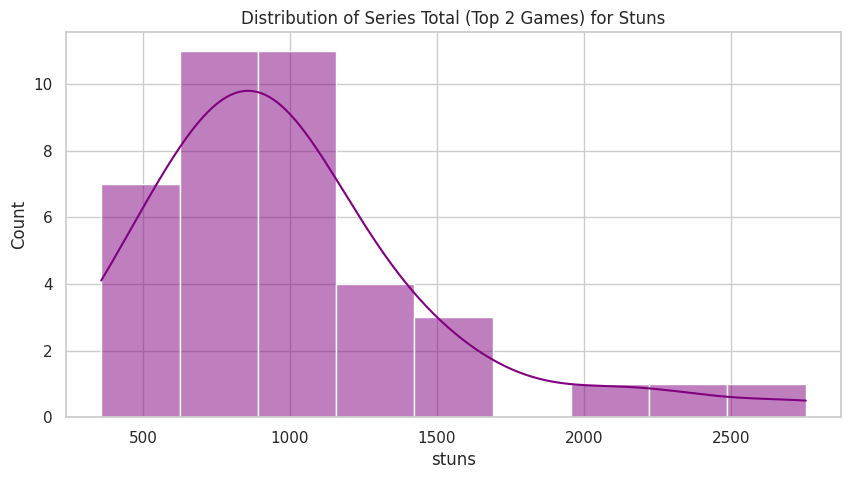

In [225]:
analyze_series_top2_stat(df_mids, 'stuns')

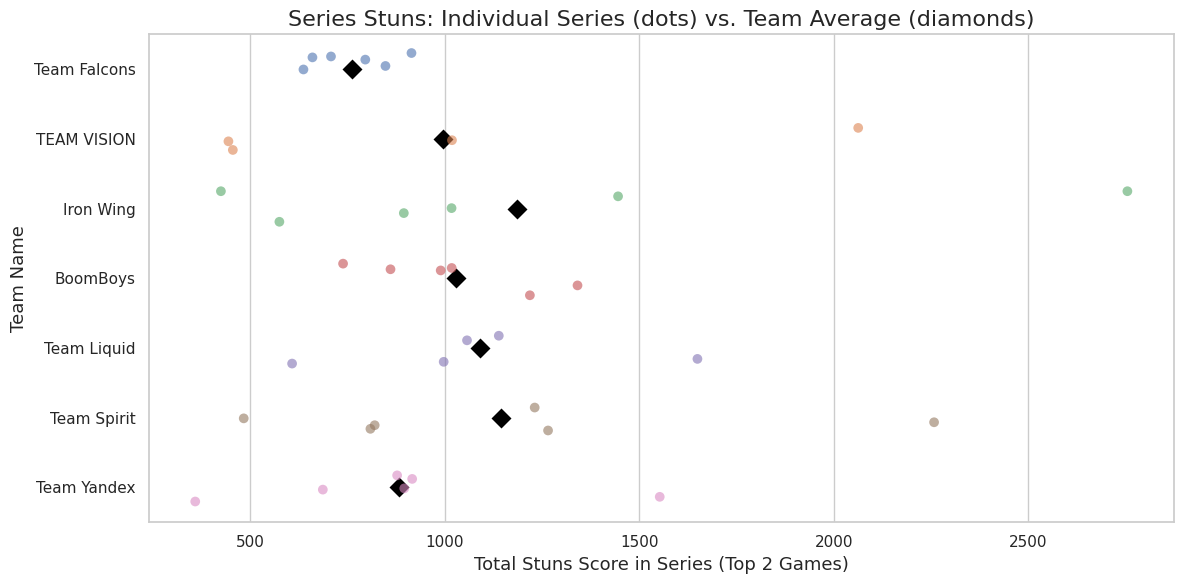

In [226]:
analyze_series_stat_by_team(df_mids, 'stuns')

### 2.2.3 First Blood Claimed

--- Top 3 Performances for Firstblood_claimed ---


,Versus,playerName,firstblood_claimed
244,Nigma Galaxy vs Team Spirit,Larl,1934.0
262,Team Liquid vs Team Yandex,CHIRA_JUNIOR,1934.0
163,BoomBoys vs Team Falcons,Malr1ne,1934.0


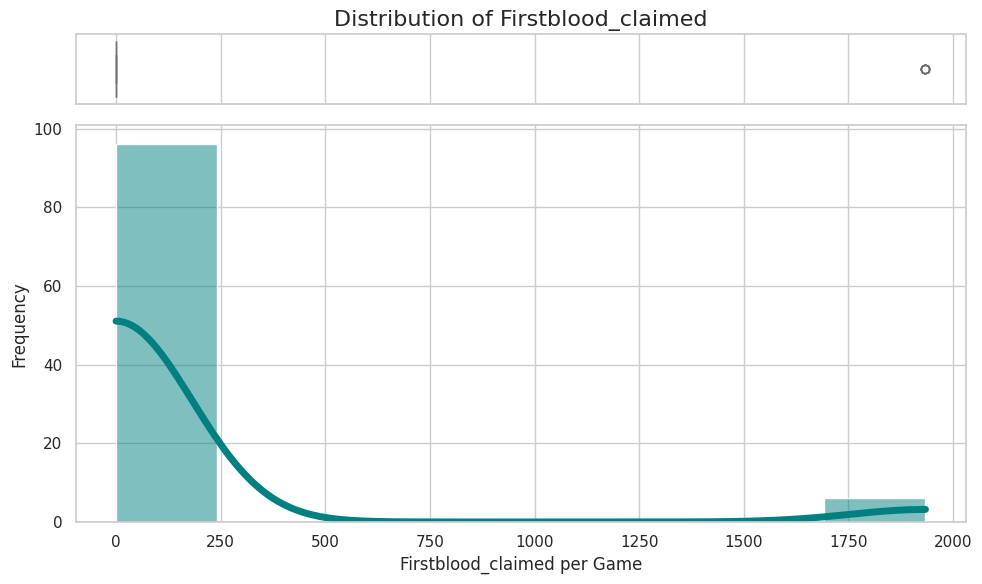

In [227]:
analyze_stat_performance(df_mids, 'firstblood_claimed')

--- Top 3 Series (Sum of top 2 games) for Firstblood_claimed ---


,Versus,teamName,firstblood_claimed
22,GamerLegion vs Team Falcons,Team Falcons,1934.0
33,Nigma Galaxy vs Team Spirit,Team Spirit,1934.0
34,Team Falcons vs Vici Gaming,Team Falcons,1934.0


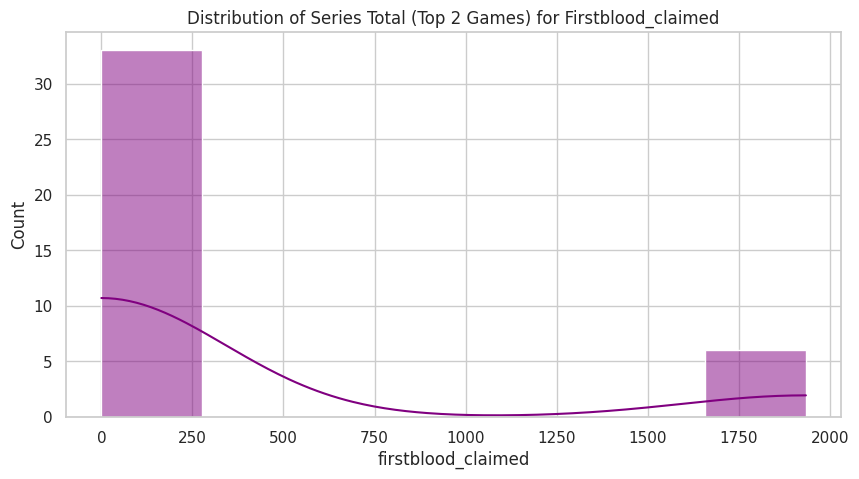

In [228]:
analyze_series_top2_stat(df_mids, 'firstblood_claimed')

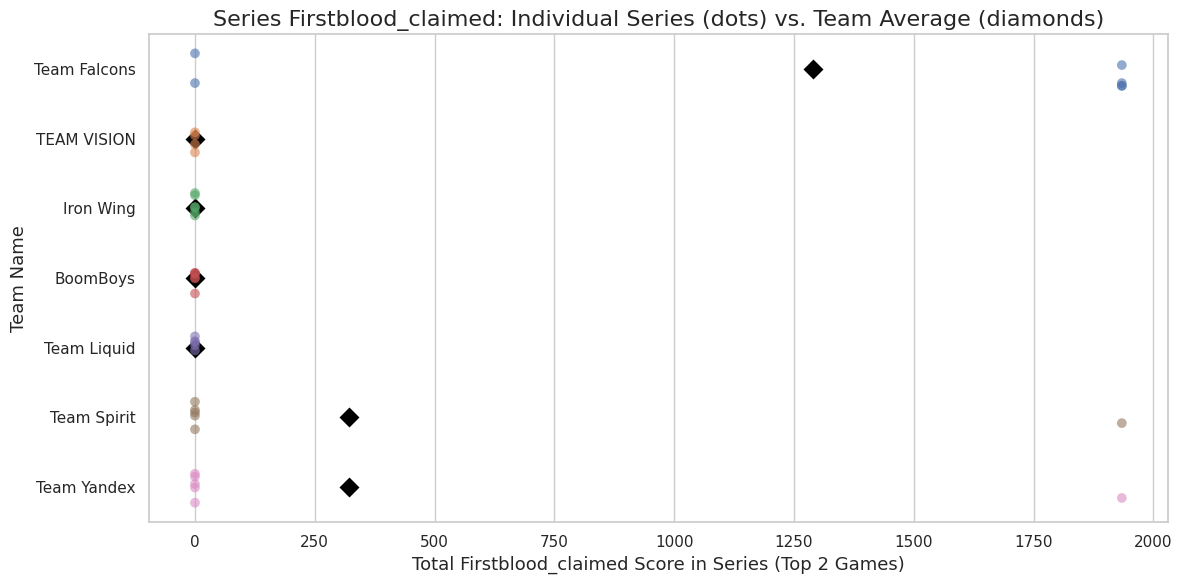

In [229]:
analyze_series_stat_by_team(df_mids, 'firstblood_claimed')

### 2.2.4 Roshan Kills

--- Top 3 Performances for Roshan_kills ---


,Versus,playerName,roshan_kills
4,BoomBoys vs OG,gpk~,2344.0
121,LGD Gaming vs Team Falcons,Malr1ne,2344.0
130,TEAM VISION vs Team Falcons,Malr1ne,2344.0


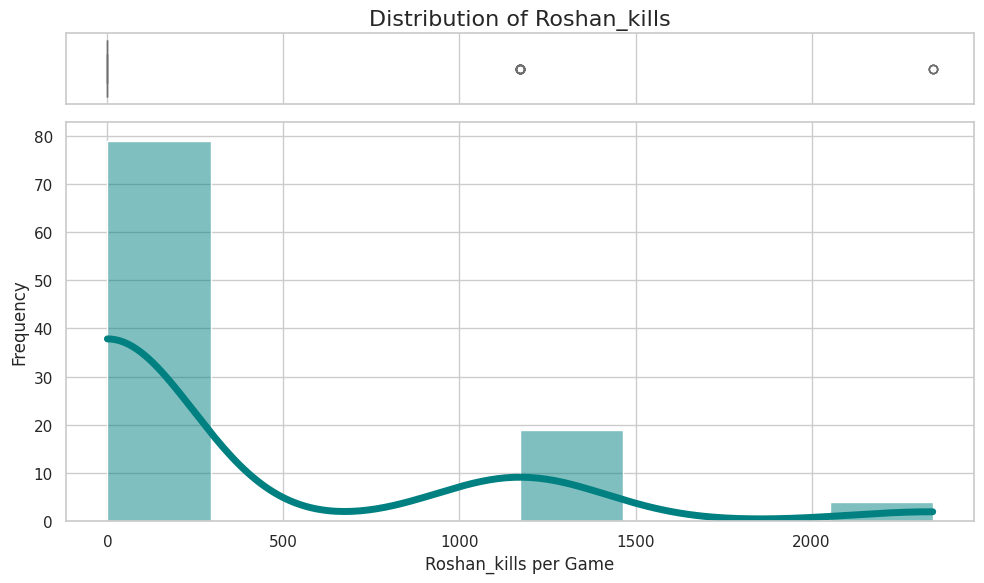

In [230]:
analyze_stat_performance(df_mids, 'roshan_kills')

--- Top 3 Series (Sum of top 2 games) for Roshan_kills ---


,Versus,teamName,roshan_kills
3,BoomBoys vs OG,BoomBoys,3516.0
0,LGD Gaming vs Team Falcons,Team Falcons,2344.0
10,TEAM VISION vs Team Falcons,Team Falcons,2344.0


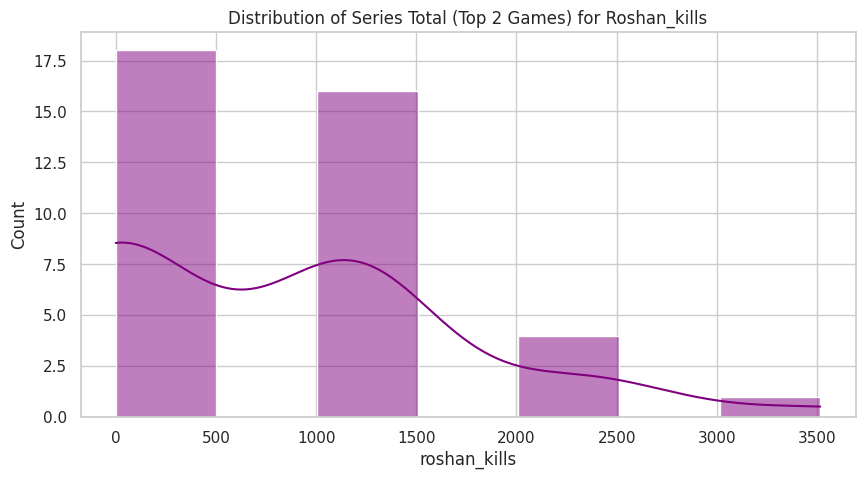

In [231]:
analyze_series_top2_stat(df_mids, 'roshan_kills')

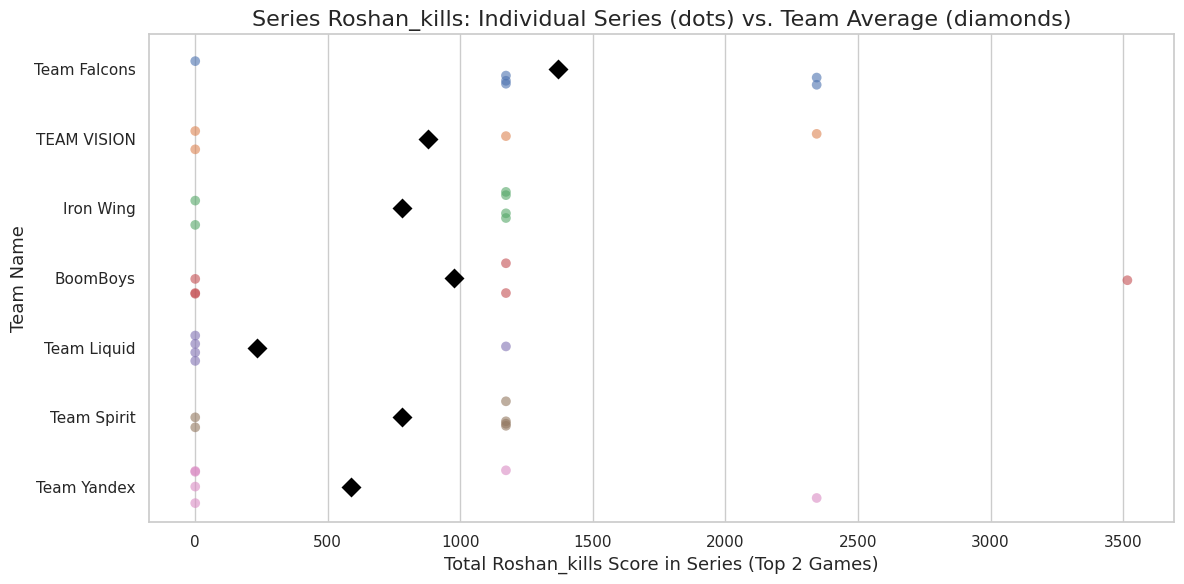

In [232]:
analyze_series_stat_by_team(df_mids, 'roshan_kills')

### 2.2.5 Tormentor Kills

--- Top 3 Performances for Tormentor_kills ---


,Versus,playerName,tormentor_kills
241,Nigma Galaxy vs Team Spirit,Larl,1758.0
4,BoomBoys vs OG,gpk~,879.0
94,TEAM VISION vs Team Resilience,No[o]ne-,879.0


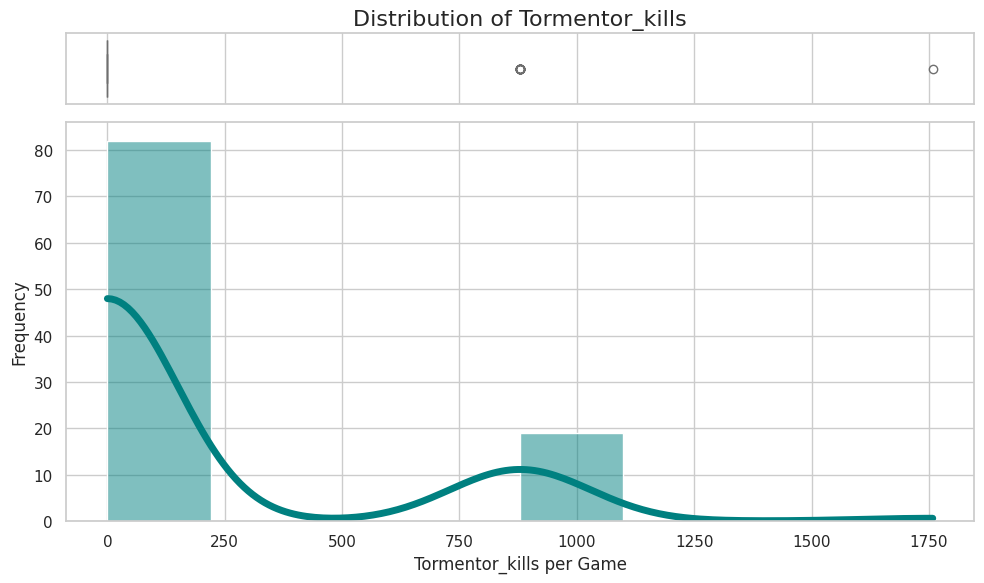

In [233]:
analyze_stat_performance(df_mids, 'tormentor_kills')

--- Top 3 Series (Sum of top 2 games) for Tormentor_kills ---


,Versus,teamName,tormentor_kills
0,LGD Gaming vs Team Falcons,Team Falcons,1758.0
1,TEAM VISION vs Team Resilience,TEAM VISION,1758.0
10,TEAM VISION vs Team Falcons,Team Falcons,1758.0


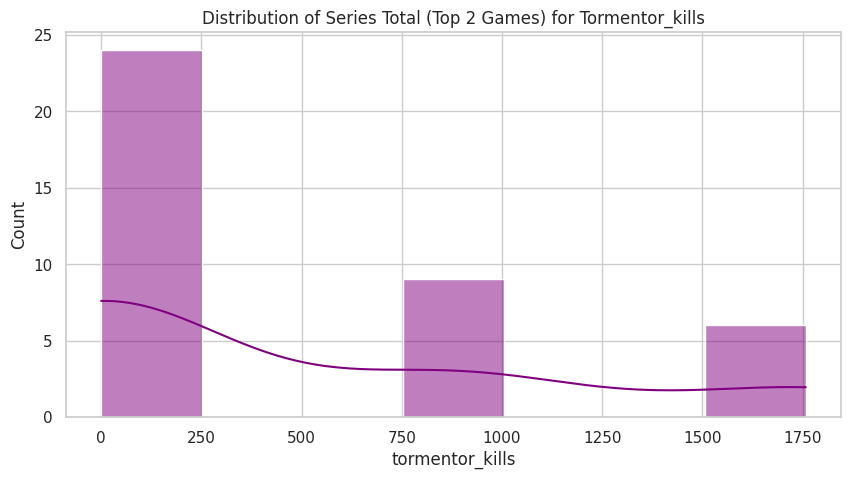

In [234]:
analyze_series_top2_stat(df_mids, 'tormentor_kills')

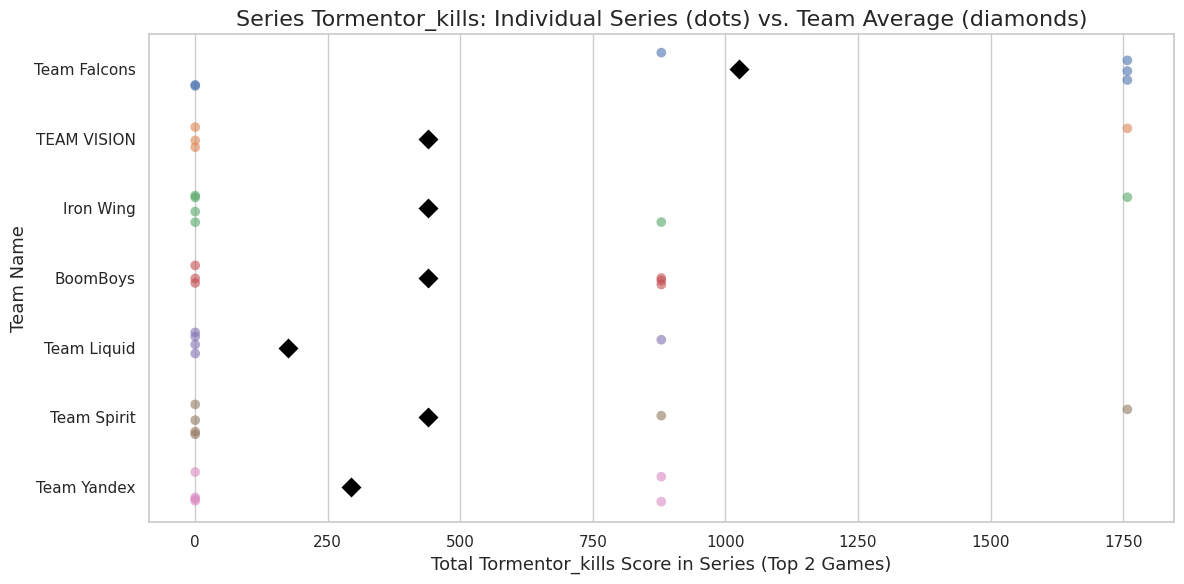

In [235]:
analyze_series_stat_by_team(df_mids, 'tormentor_kills')

### 2.2.6 Courier Kills

--- Top 3 Performances for Courier_kills ---


,Versus,playerName,courier_kills
7,BoomBoys vs Iron Wing,gpk~,1406.0
139,Iron Wing vs Team Falcons,Malr1ne,1406.0
16,BoomBoys vs TEAM VISION,gpk~,703.0


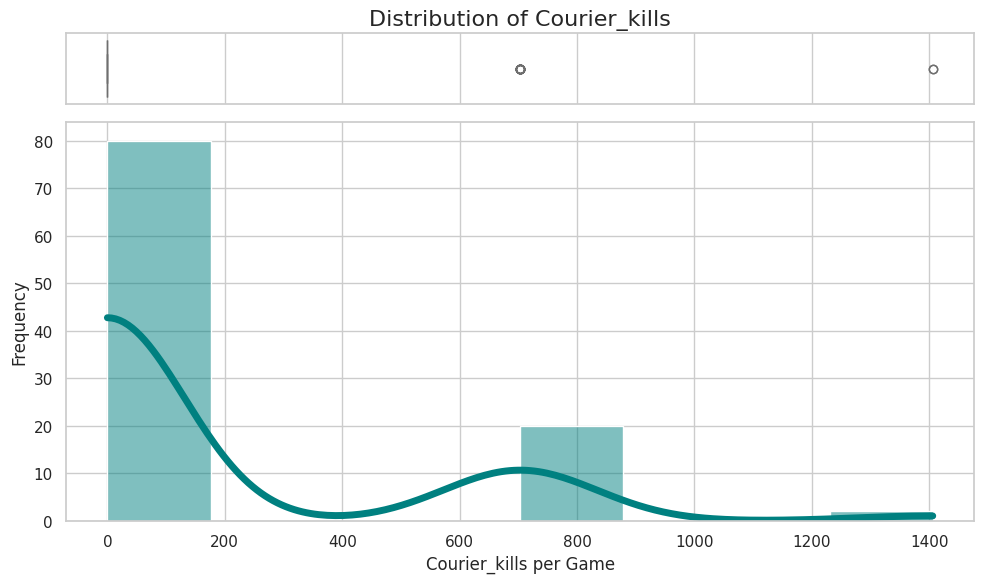

In [236]:
analyze_stat_performance(df_mids, 'courier_kills')

--- Top 3 Series (Sum of top 2 games) for Courier_kills ---


,Versus,teamName,courier_kills
7,BoomBoys vs Iron Wing,BoomBoys,2109.0
17,Iron Wing vs Team Falcons,Team Falcons,2109.0
21,Team Resilience vs Team Yandex,Team Yandex,1406.0


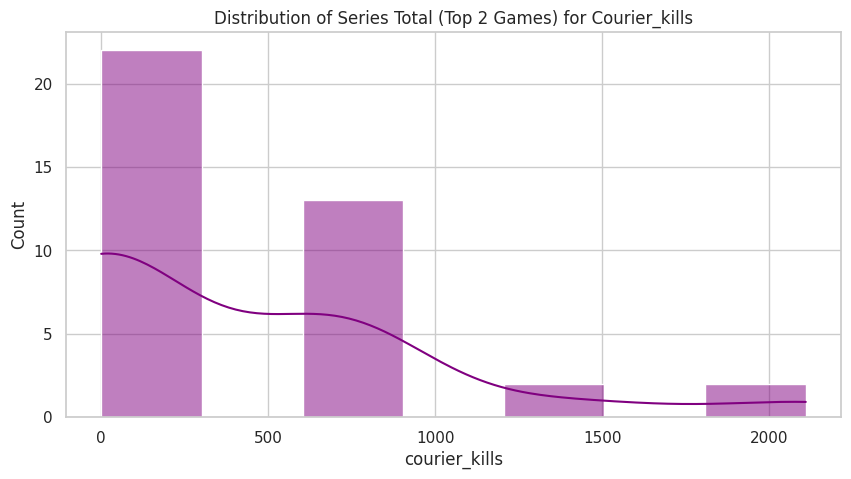

In [237]:
analyze_series_top2_stat(df_mids, 'courier_kills')

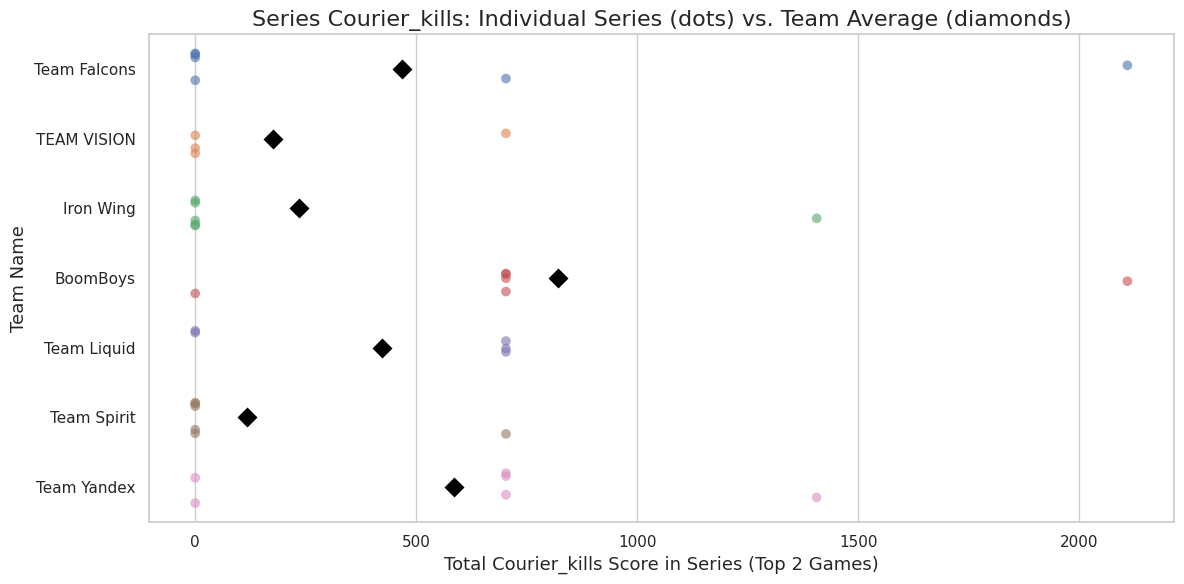

In [238]:
analyze_series_stat_by_team(df_mids, 'courier_kills')

## 2.3 Blue Stats

### 2.3.1 Observers Placed

--- Top 3 Performances for Obs_placed ---


,Versus,playerName,obs_placed
136,TEAM VISION vs Team Falcons,Malr1ne,351.0
1,BoomBoys vs OG,gpk~,234.0
7,BoomBoys vs Iron Wing,gpk~,234.0


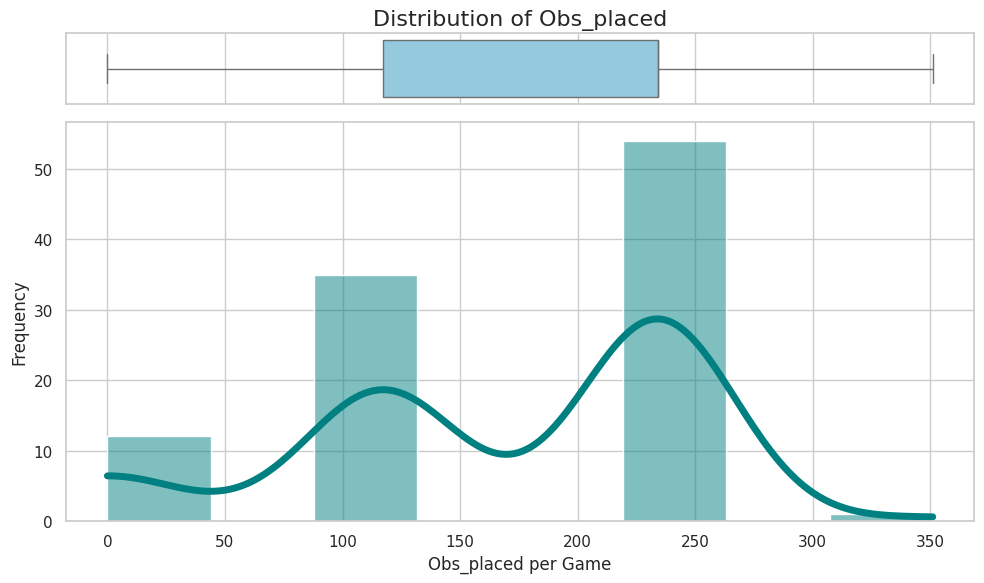

In [239]:
analyze_stat_performance(df_mids, 'obs_placed')

--- Top 3 Series (Sum of top 2 games) for Obs_placed ---


,Versus,teamName,obs_placed
10,TEAM VISION vs Team Falcons,Team Falcons,585.0
1,TEAM VISION vs Team Resilience,TEAM VISION,468.0
0,LGD Gaming vs Team Falcons,Team Falcons,468.0


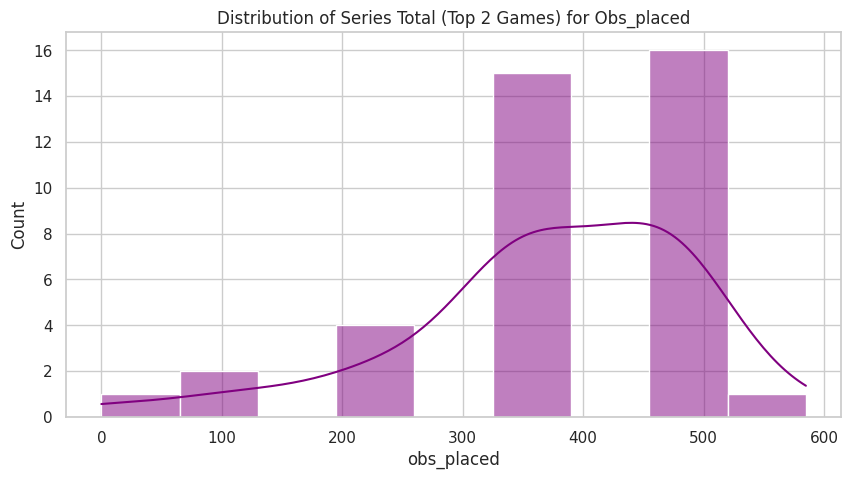

In [240]:
analyze_series_top2_stat(df_mids, 'obs_placed')

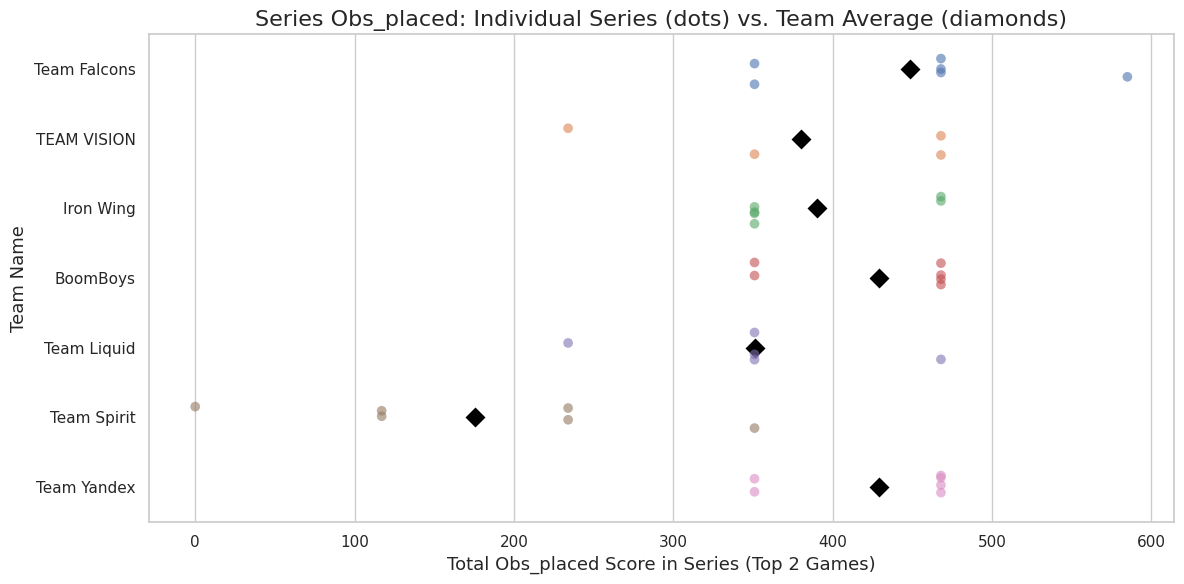

In [241]:
analyze_series_stat_by_team(df_mids, 'obs_placed')

### 2.3.2 Camps Stacked

--- Top 3 Performances for Camps_stacked ---


,Versus,playerName,camps_stacked
172,Team Liquid vs Vici Gaming,Nisha,2808.0
4,BoomBoys vs OG,gpk~,1872.0
166,Team Falcons vs Vici Gaming,Malr1ne,1872.0


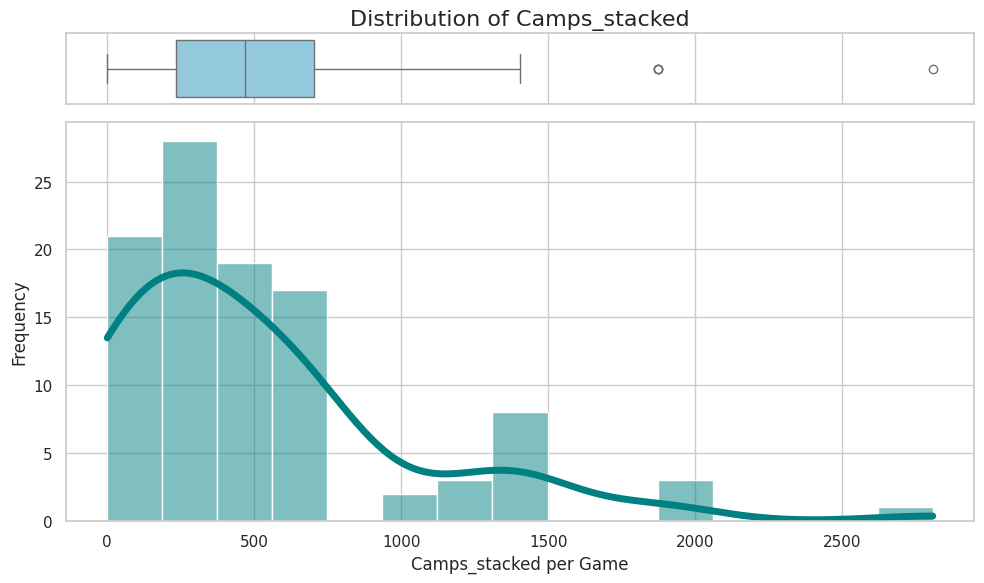

In [242]:
analyze_stat_performance(df_mids, 'camps_stacked')

--- Top 3 Series (Sum of top 2 games) for Camps_stacked ---


,Versus,teamName,camps_stacked
4,Team Liquid vs Vici Gaming,Team Liquid,3276.0
16,Iron Wing vs Team Falcons,Iron Wing,2808.0
3,BoomBoys vs OG,BoomBoys,2340.0


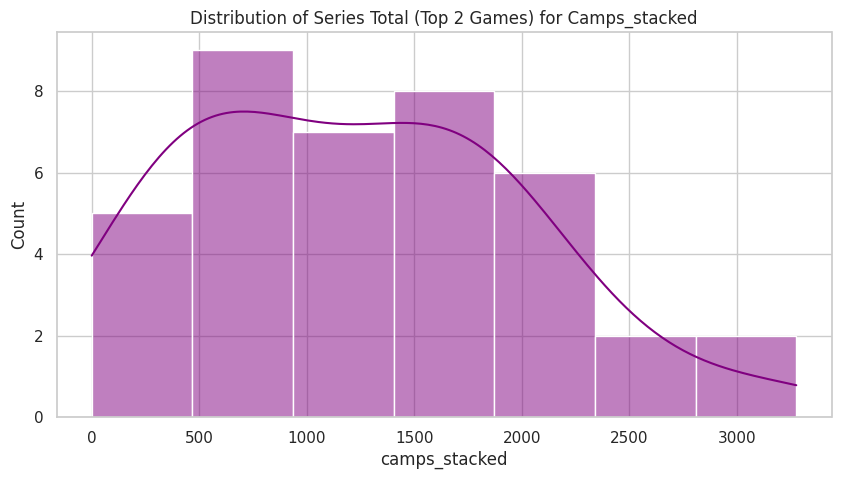

In [243]:
analyze_series_top2_stat(df_mids, 'camps_stacked')

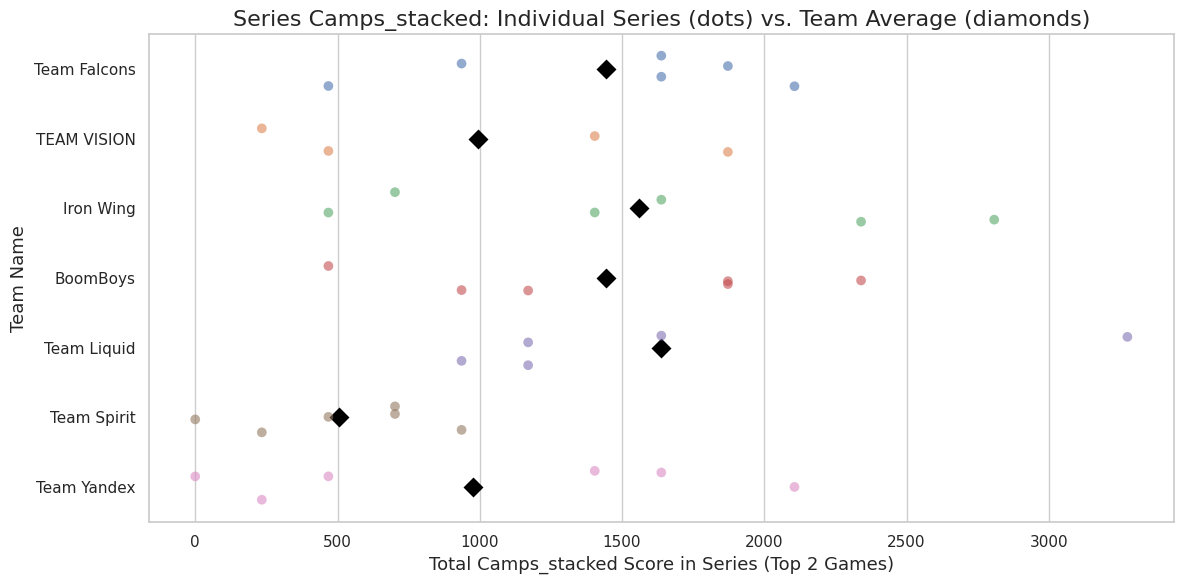

In [244]:
analyze_series_stat_by_team(df_mids, 'camps_stacked')

### 2.3.3 Runes Grabbed

--- Top 3 Performances for Runes_grabbed ---


,Versus,playerName,runes_grabbed
52,BoomBoys vs Iron Wing,bzm,2961.0
82,Iron Wing vs Team Yandex,bzm,2820.0
172,Team Liquid vs Vici Gaming,Nisha,2820.0


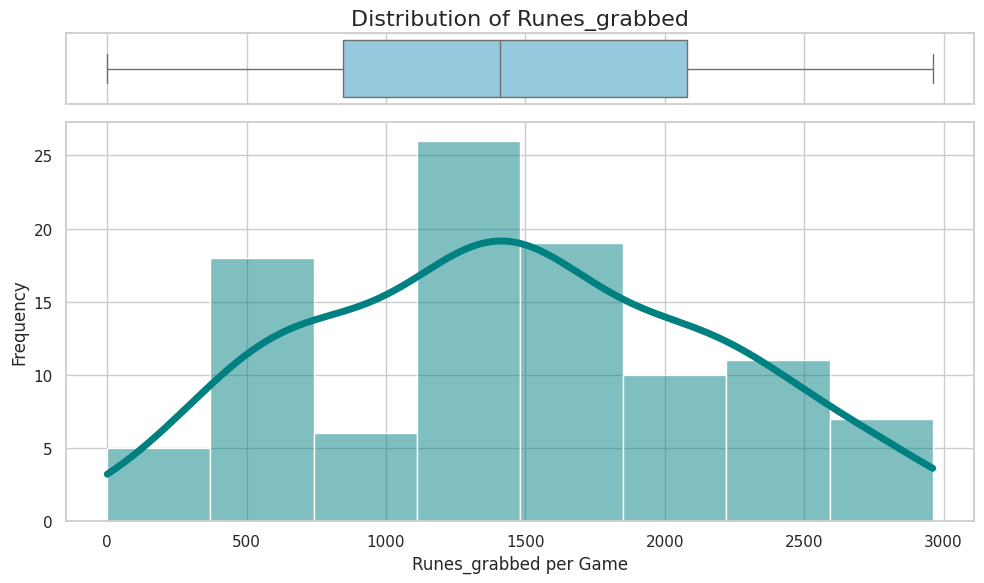

In [245]:
analyze_stat_performance(df_mids, 'runes_grabbed')

--- Top 3 Series (Sum of top 2 games) for Runes_grabbed ---


,Versus,teamName,runes_grabbed
4,Team Liquid vs Vici Gaming,Team Liquid,5217.0
26,TEAM VISION vs Team Spirit,TEAM VISION,4935.0
8,BoomBoys vs Iron Wing,Iron Wing,4653.0


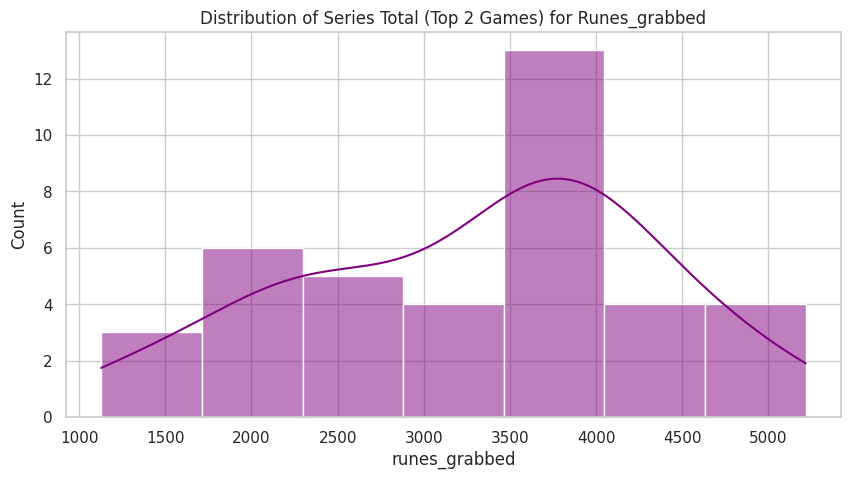

In [246]:
analyze_series_top2_stat(df_mids, 'runes_grabbed')

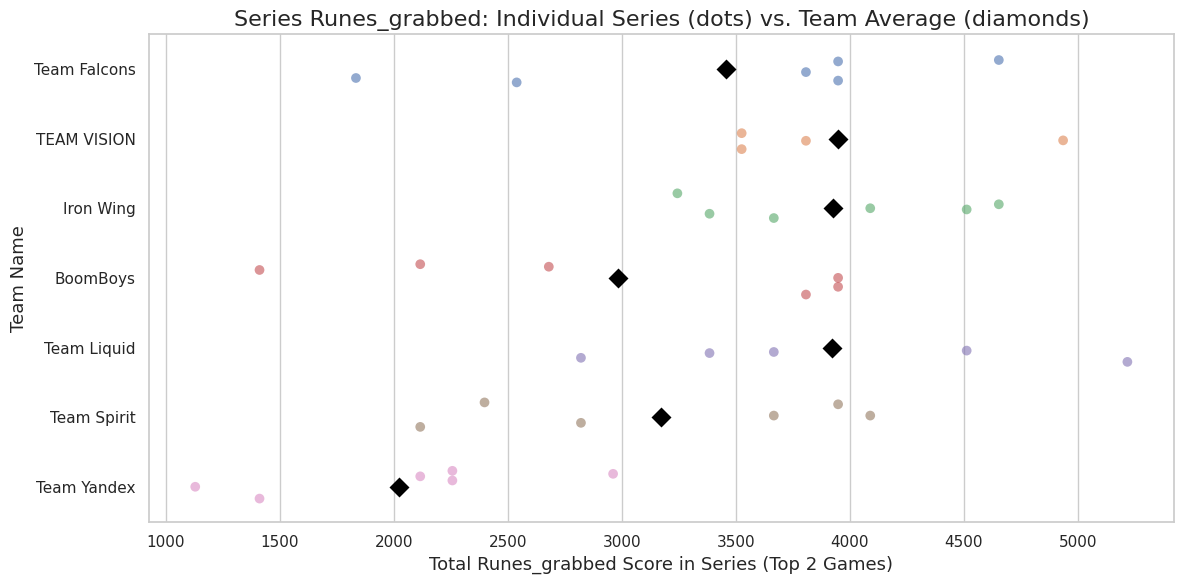

In [247]:
analyze_series_stat_by_team(df_mids, 'runes_grabbed')

### 2.3.4 Watchers Taken

--- Top 3 Performances for Watchers_taken ---


,Versus,playerName,watchers_taken
112,BoomBoys vs TEAM VISION,No[o]ne-,1470.0
202,Iron Wing vs Team Liquid,Nisha,1323.0
100,TEAM VISION vs Team Falcons,No[o]ne-,1029.0


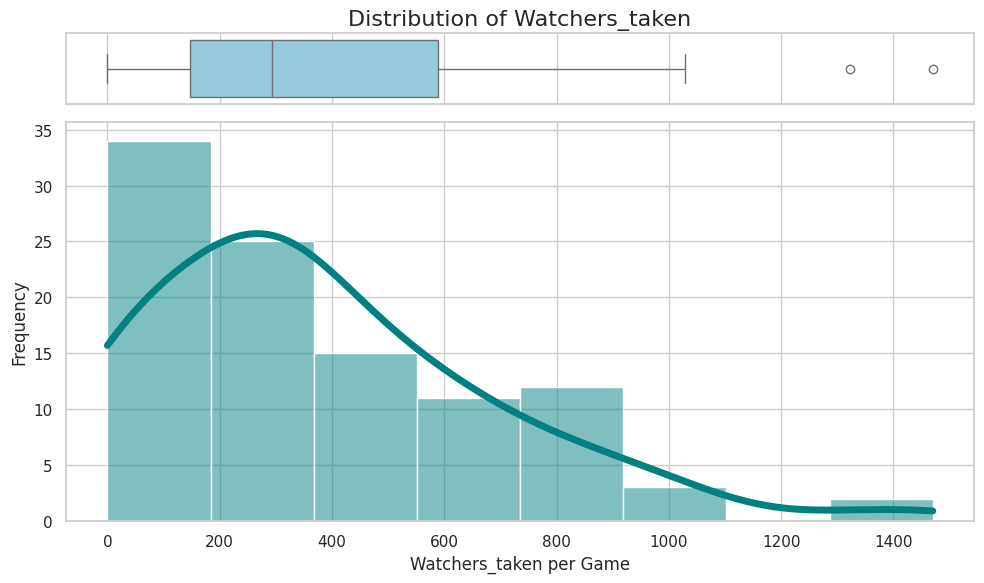

In [248]:
analyze_stat_performance(df_mids, 'watchers_taken')

--- Top 3 Series (Sum of top 2 games) for Watchers_taken ---


,Versus,teamName,watchers_taken
15,BoomBoys vs TEAM VISION,TEAM VISION,2205.0
9,TEAM VISION vs Team Falcons,TEAM VISION,1911.0
19,Team Liquid vs Team Spirit,Team Spirit,1911.0


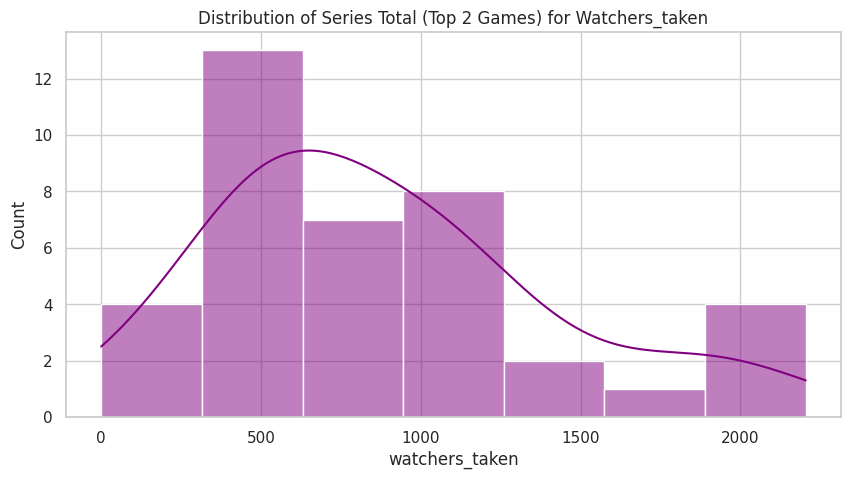

In [249]:
analyze_series_top2_stat(df_mids, 'watchers_taken')

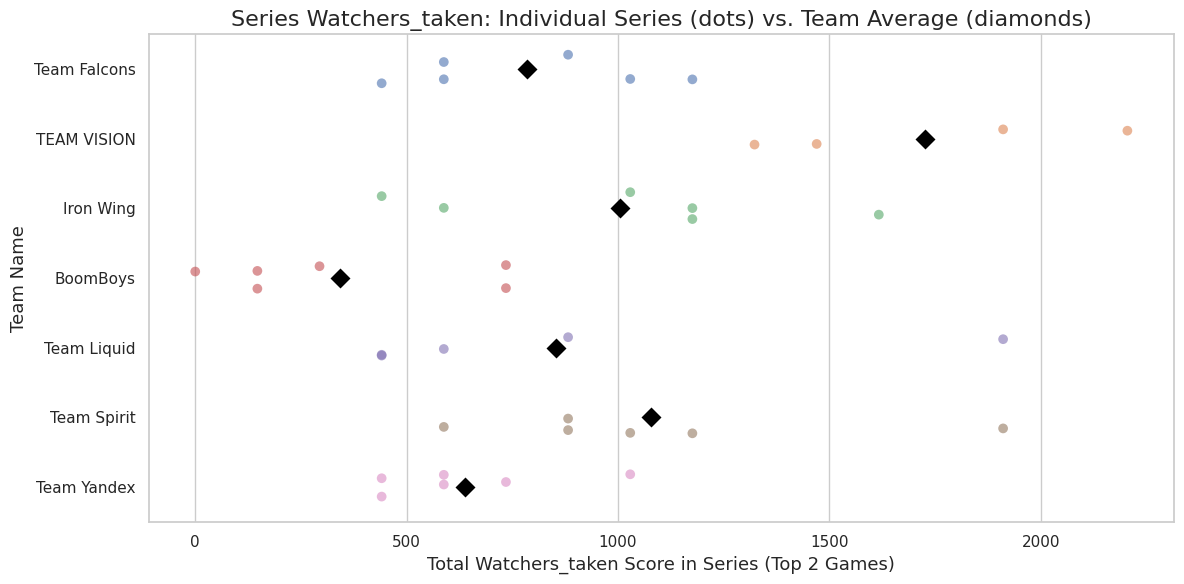

In [250]:
analyze_series_stat_by_team(df_mids, 'watchers_taken')

### 2.3.5 Smokes Used

--- Top 3 Performances for Smokes_used ---


,Versus,playerName,smokes_used
169,Team Falcons vs Vici Gaming,Malr1ne,293.0
136,TEAM VISION vs Team Falcons,Malr1ne,293.0
250,Team Resilience vs Team Spirit,Larl,293.0


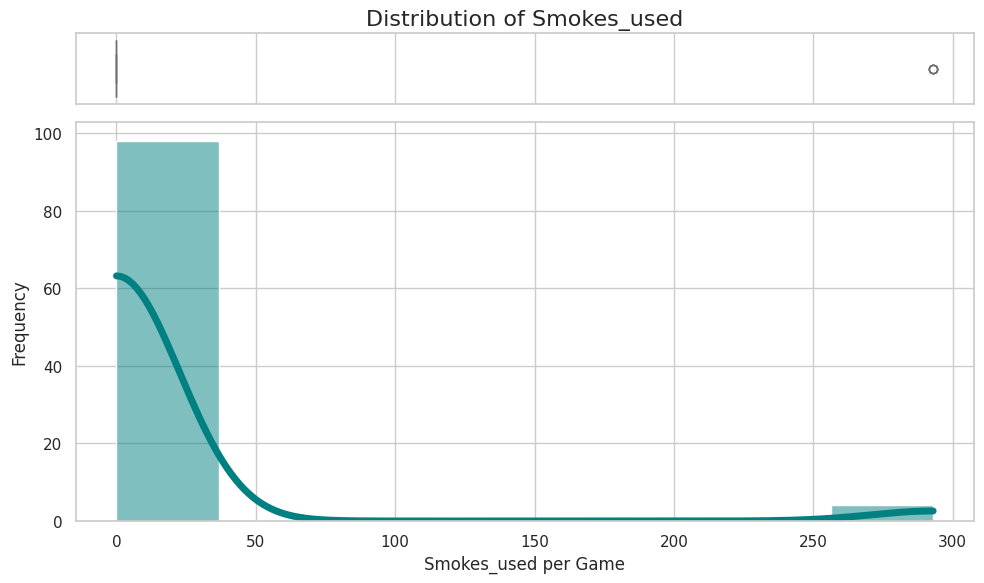

In [251]:
analyze_stat_performance(df_mids, 'smokes_used')

--- Top 3 Series (Sum of top 2 games) for Smokes_used ---


,Versus,teamName,smokes_used
6,HULIGANI vs Team Yandex,Team Yandex,293.0
36,Team Resilience vs Team Spirit,Team Spirit,293.0
10,TEAM VISION vs Team Falcons,Team Falcons,293.0


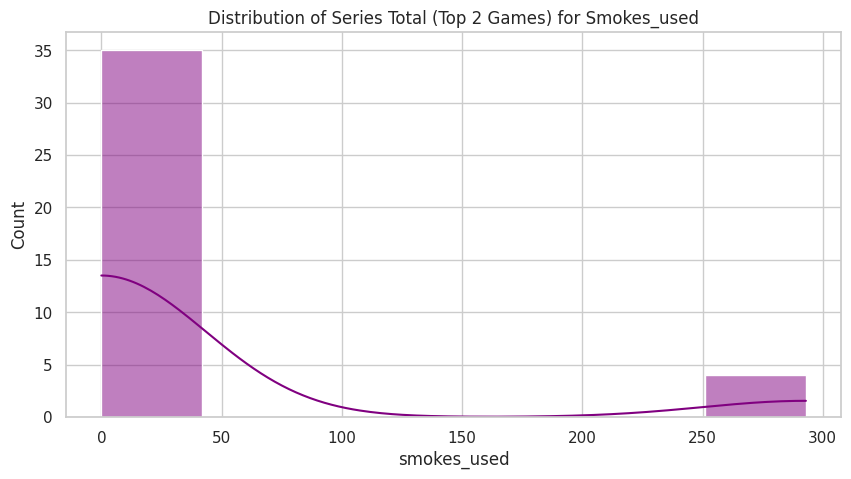

In [252]:
analyze_series_top2_stat(df_mids, 'smokes_used')

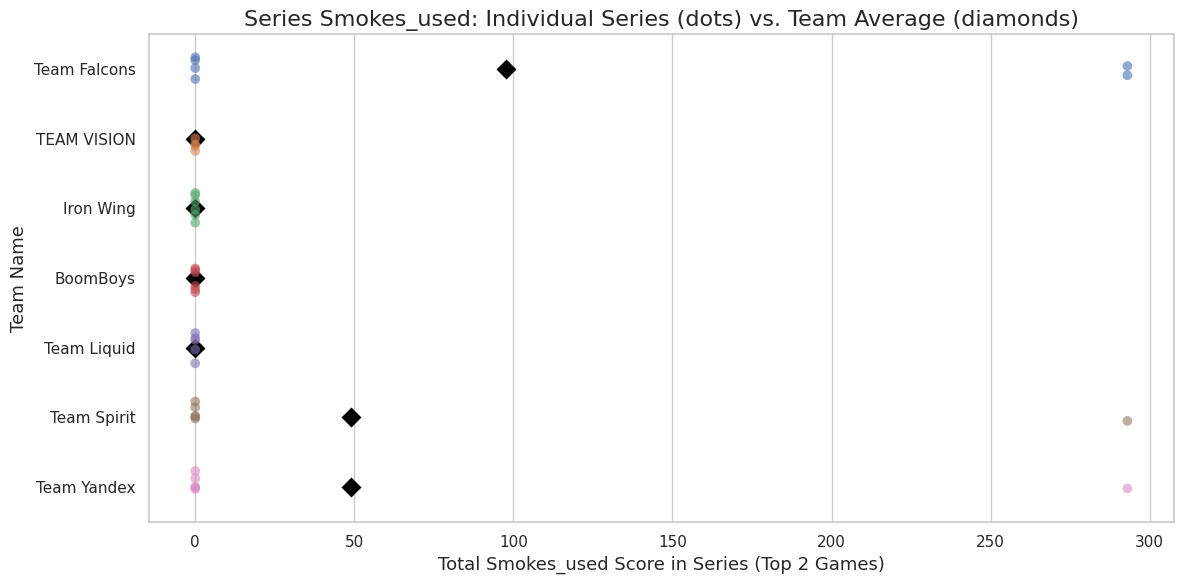

In [253]:
analyze_series_stat_by_team(df_mids, 'smokes_used')

## 2.4 Overall mid

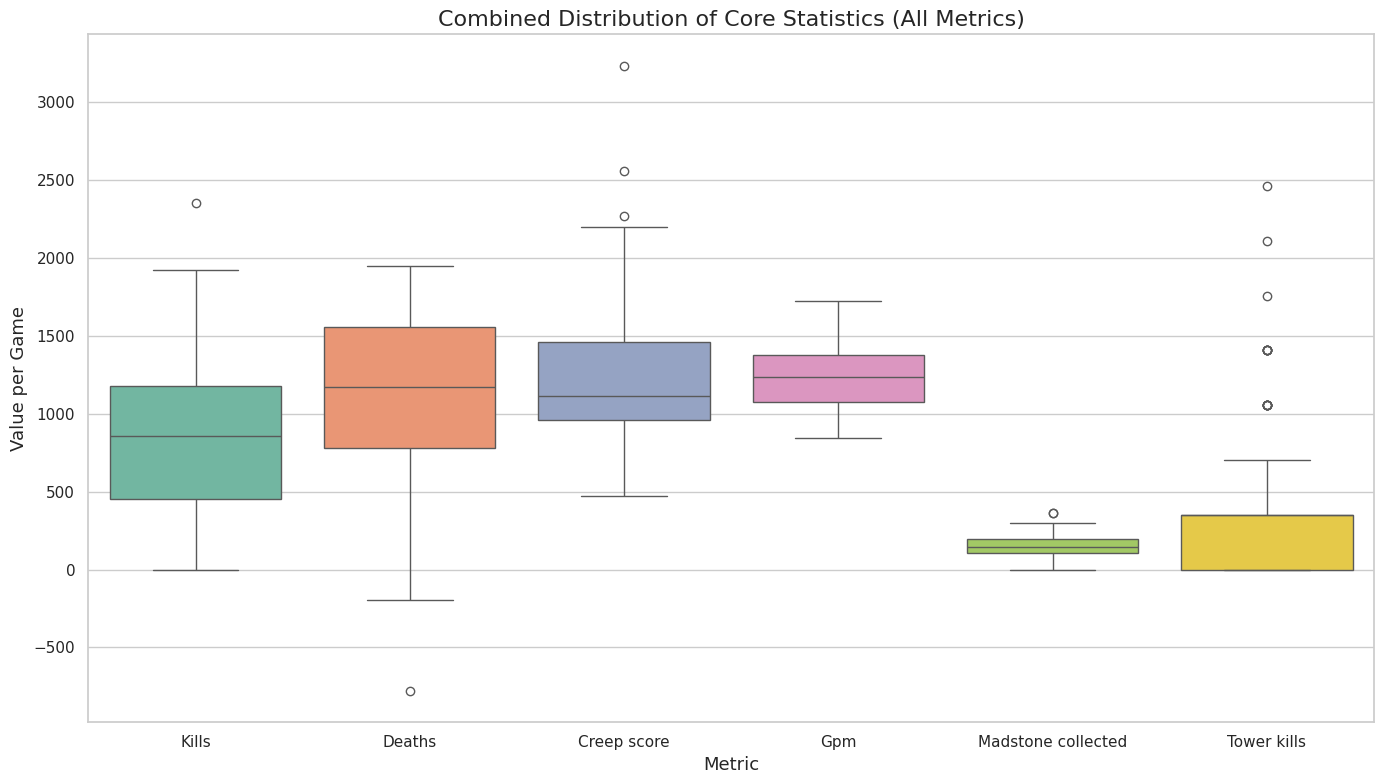

In [254]:
# List of stats to consolidate
stats_to_plot = ['kills', 'deaths', 'creep_score', 'gpm', 'madstone_collected', 'tower_kills']

# Prepare data by melting into long-form
df_melted = df_mids.melt(value_vars=stats_to_plot, var_name='Statistic', value_name='Value')
df_melted['Statistic'] = df_melted['Statistic'].str.replace('_', ' ').str.capitalize()

# Create a single combined vertical boxplot
plt.figure(figsize=(14, 8))
# Using 'Set2' for a softer, more eye-friendly color palette
sns.set_theme(style="whitegrid")
sns.boxplot(data=df_melted, x='Statistic', y='Value', hue='Statistic', palette="Set2", legend=False)

plt.title('Red Distribution of Mid Statistics (All Metrics)', fontsize=16)
plt.xlabel('Metric', fontsize=13)
plt.ylabel('Value per Game', fontsize=13)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

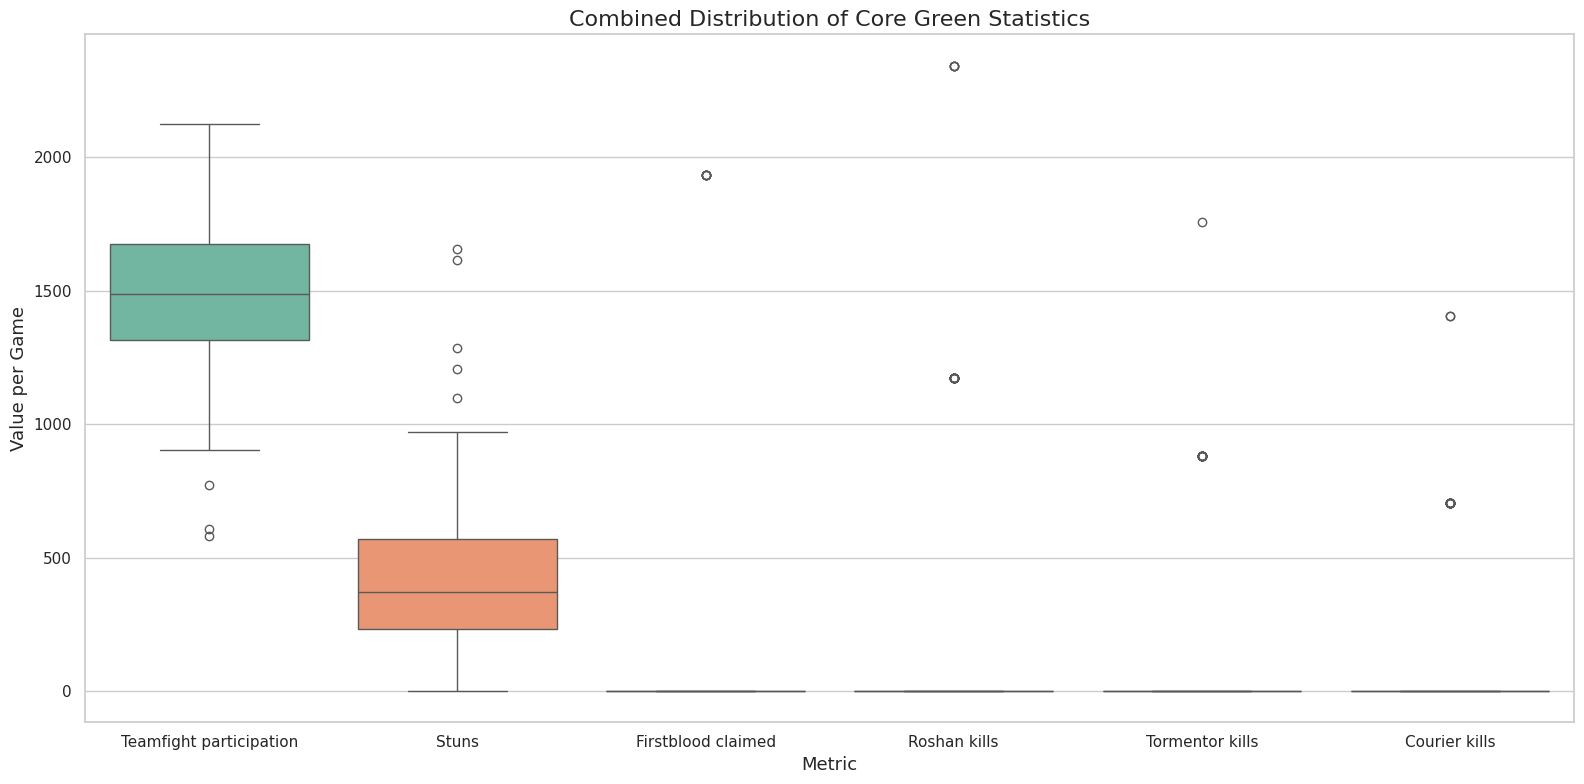

In [255]:
# List of 'Green' stats to consolidate
green_stats = [
    'teamfight_participation', 'stuns', 'firstblood_claimed',
    'roshan_kills', 'tormentor_kills', 'courier_kills'
]

# Prepare data by melting into long-form
df_green_melted = df_mids.melt(value_vars=green_stats, var_name='Statistic', value_name='Value')
df_green_melted['Statistic'] = df_green_melted['Statistic'].str.replace('_', ' ').str.capitalize()

# Create the combined vertical boxplot
plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")
sns.boxplot(data=df_green_melted, x='Statistic', y='Value', hue='Statistic', palette="Set2", legend=False)

plt.title('Combined Distribution of Mid Green Statistics', fontsize=16)
plt.xlabel('Metric', fontsize=13)
plt.ylabel('Value per Game', fontsize=13)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

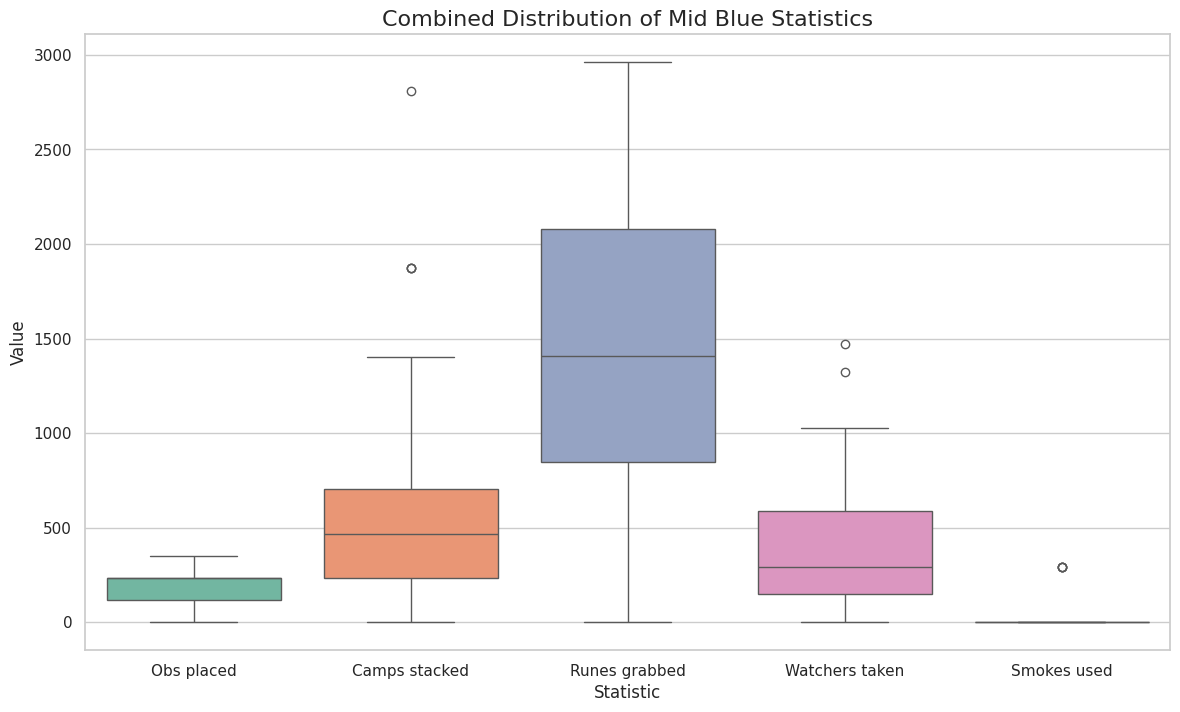

In [256]:
blue_stats = ['obs_placed', 'camps_stacked', 'runes_grabbed', 'watchers_taken', 'smokes_used']
df_blue_melted = df_mids.melt(value_vars=blue_stats, var_name='Statistic', value_name='Value')
df_blue_melted['Statistic'] = df_blue_melted['Statistic'].str.replace('_', ' ').str.capitalize()
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_blue_melted, x='Statistic', y='Value', hue='Statistic', palette='Set2', legend=False)
plt.title('Combined Distribution of Mid Blue Statistics', fontsize=16)
plt.show()

# 3. Support

## 3.1 Green Stats

### 3.1.1 Teamfight Participation

--- Top 3 Performances for Teamfight_participation ---


,Versus,playerName,teamfight_participation
122,LGD Gaming vs Team Falcons,Sneyking & Cr1t-,1737.82
161,BoomBoys vs Team Falcons,Sneyking & Cr1t-,1725.75
74,Iron Wing vs Team Liquid,Ari & Whitemon,1686.71


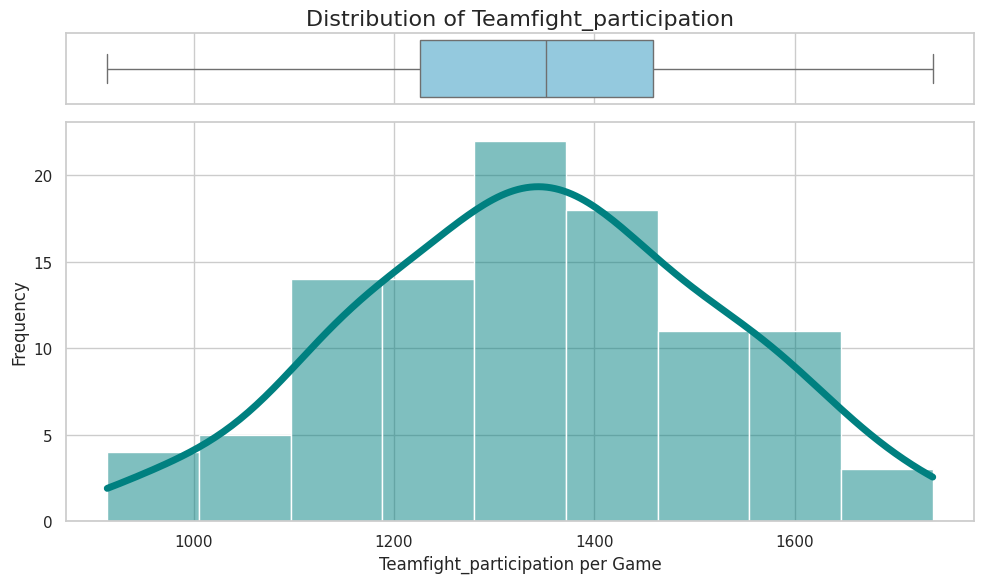

In [257]:
analyze_stat_performance(df_supports, 'teamfight_participation')

--- Top 3 Series (Sum of top 2 games) for Teamfight_participation ---


,Versus,teamName,teamfight_participation
23,Iron Wing vs Team Liquid,Iron Wing,3248.475
24,Iron Wing vs Team Liquid,Team Liquid,3156.665
2,Iron Wing vs Nigma Galaxy,Iron Wing,3131.635


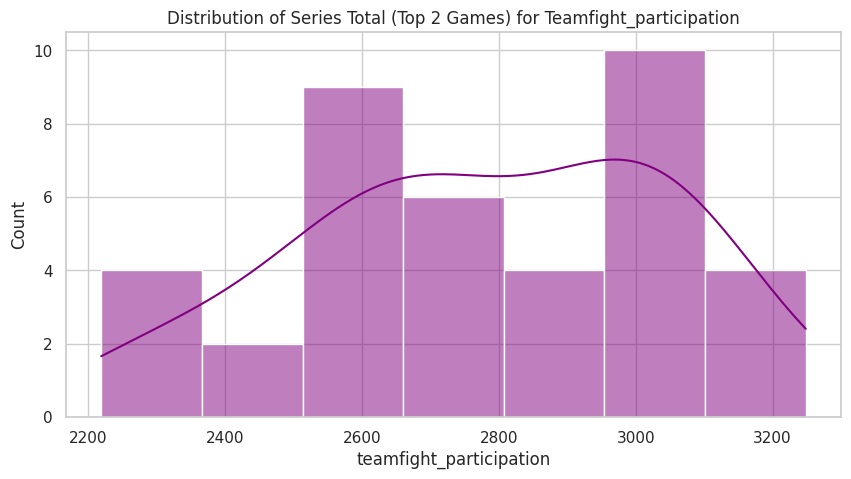

In [258]:
analyze_series_top2_stat(df_supports, 'teamfight_participation')

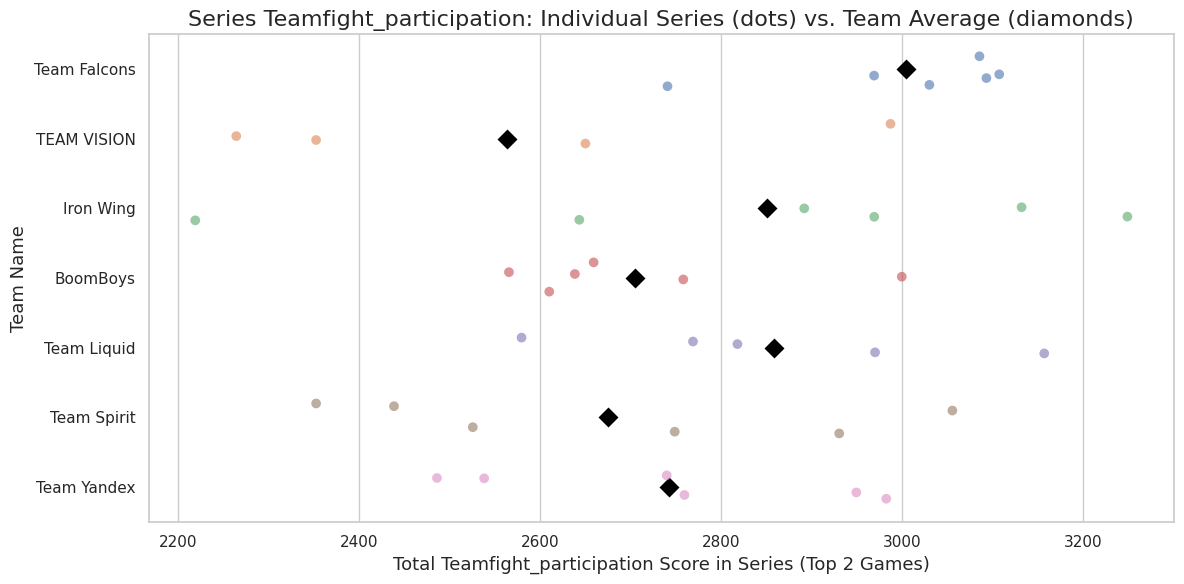

In [259]:
analyze_series_stat_by_team(df_supports, 'teamfight_participation')

### 3.1.2 Stuns

--- Top 3 Performances for Stuns ---


,Versus,playerName,stuns
59,Iron Wing vs Team Falcons,Ari & Whitemon,1788.335
74,Iron Wing vs Team Liquid,Ari & Whitemon,1529.340
215,Team Spirit vs Xtreme Gaming,rue & not_me,1476.330


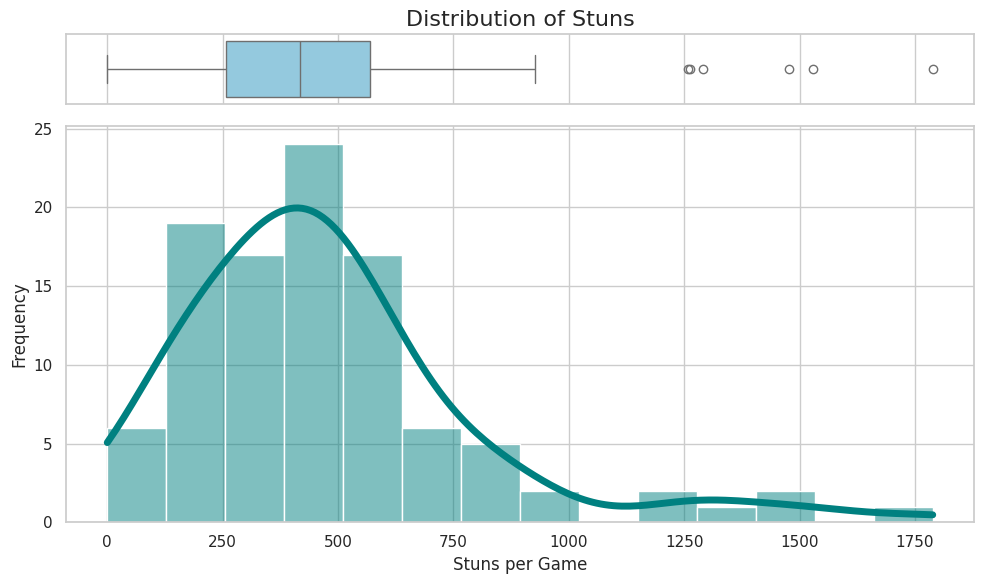

In [260]:
analyze_stat_performance(df_supports, 'stuns')

--- Top 3 Series (Sum of top 2 games) for Stuns ---


,Versus,teamName,stuns
16,Iron Wing vs Team Falcons,Iron Wing,2357.980
5,Team Spirit vs Xtreme Gaming,Team Spirit,2260.645
23,Iron Wing vs Team Liquid,Iron Wing,2113.675


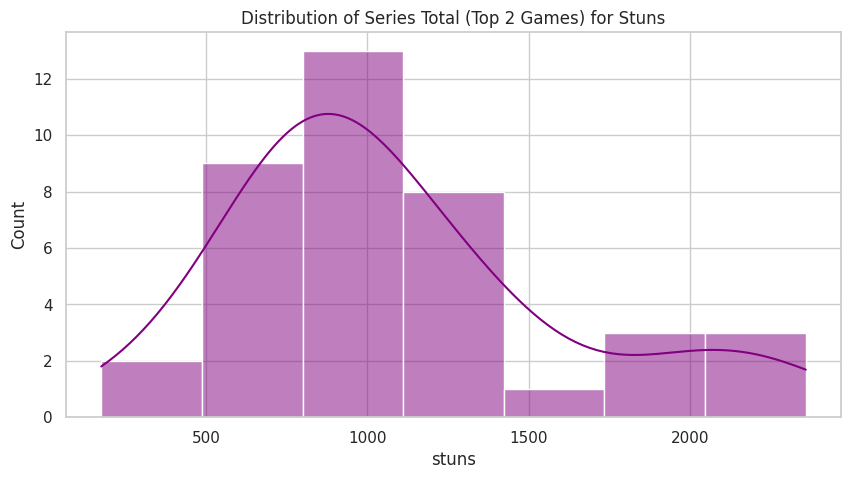

In [261]:
analyze_series_top2_stat(df_supports, 'stuns')

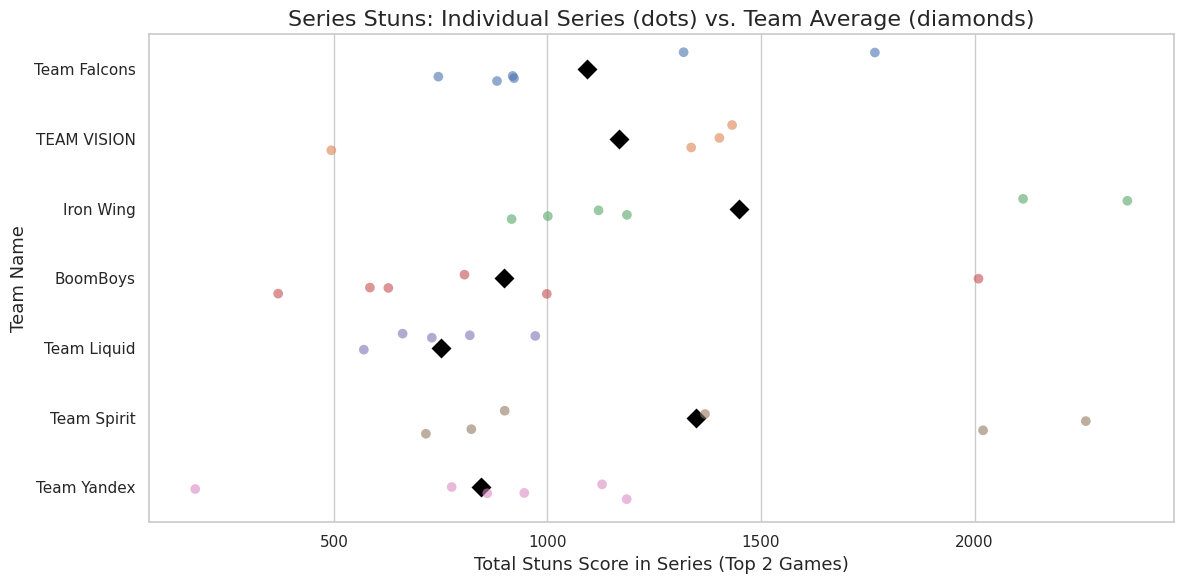

In [262]:
analyze_series_stat_by_team(df_supports, 'stuns')

### 3.1.3 First Blood Claimed

--- Top 3 Performances for Firstblood_claimed ---


,Versus,playerName,firstblood_claimed
77,Iron Wing vs Team Yandex,Ari & Whitemon,967.0
83,Iron Wing vs Team Yandex,Ari & Whitemon,967.0
104,TEAM VISION vs Team Falcons,9Class & Dukalis,967.0


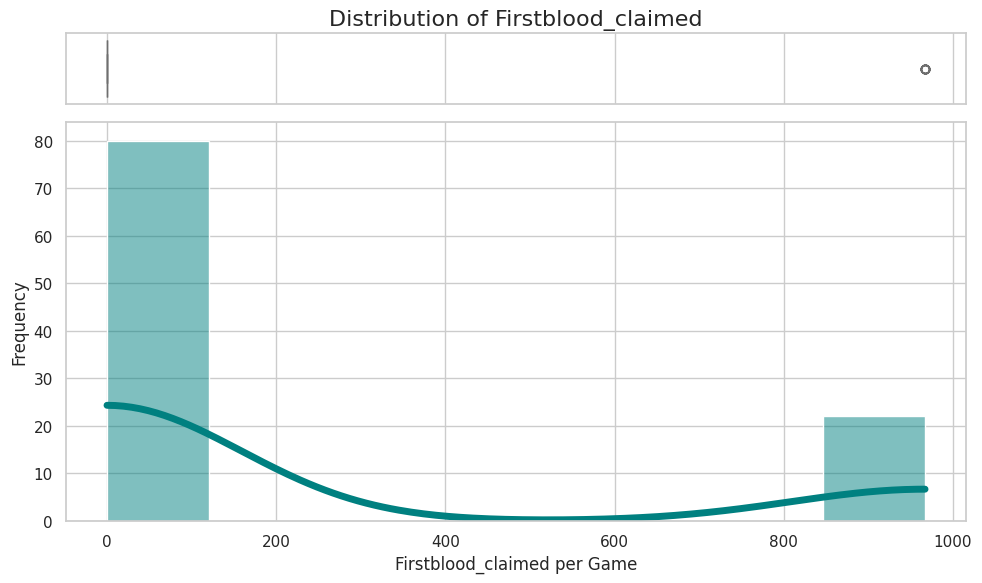

In [263]:
analyze_stat_performance(df_supports, 'firstblood_claimed')

--- Top 3 Series (Sum of top 2 games) for Firstblood_claimed ---


,Versus,teamName,firstblood_claimed
4,Team Liquid vs Vici Gaming,Team Liquid,1934.0
5,Team Spirit vs Xtreme Gaming,Team Spirit,1934.0
9,TEAM VISION vs Team Falcons,TEAM VISION,1934.0


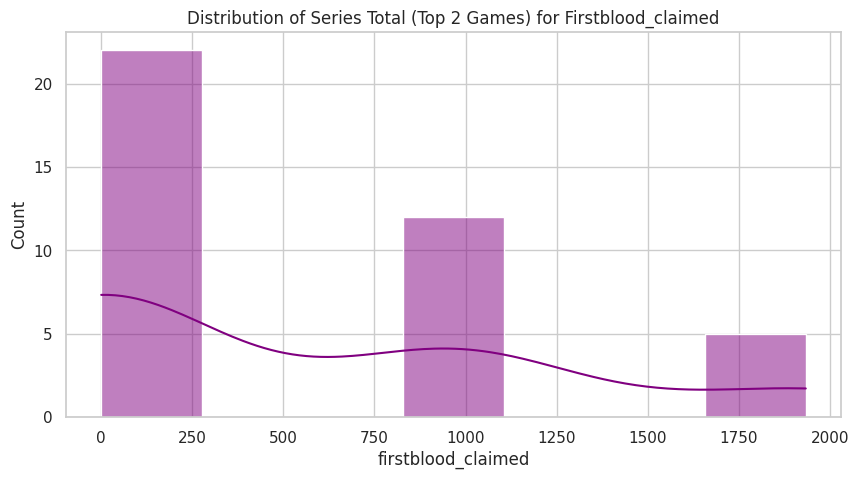

In [264]:
analyze_series_top2_stat(df_supports, 'firstblood_claimed')

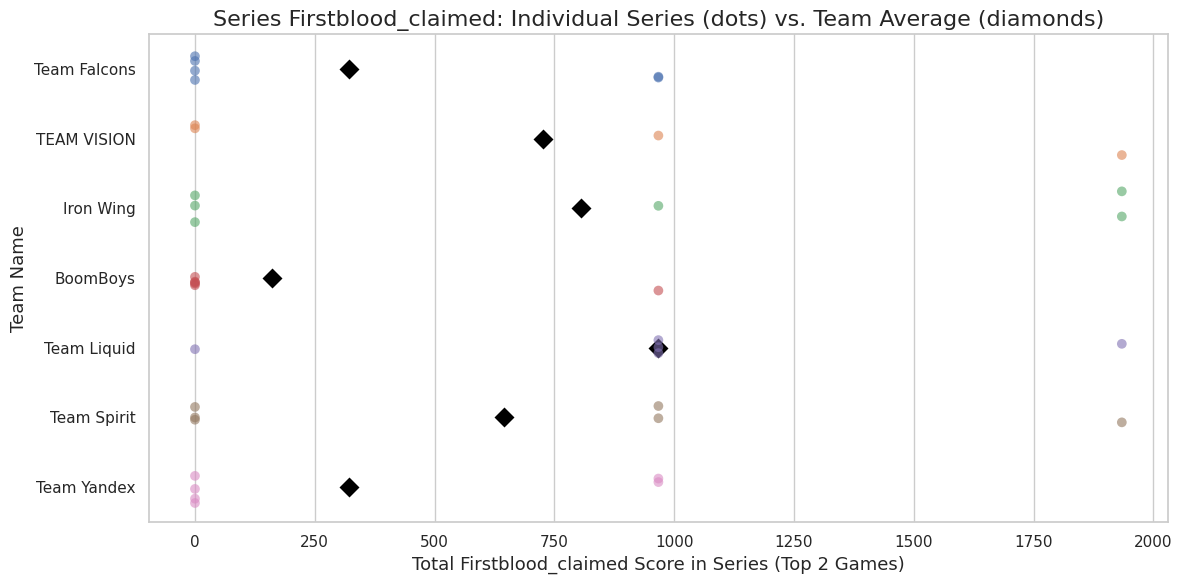

In [265]:
analyze_series_stat_by_team(df_supports, 'firstblood_claimed')

### 3.1.4 Roshan Kills

--- Top 3 Performances for Roshan_kills ---


,Versus,playerName,roshan_kills
92,TEAM VISION vs Team Resilience,9Class & Dukalis,1172.0
200,Iron Wing vs Team Liquid,tOfu & Boxi,1172.0
98,TEAM VISION vs Team Resilience,9Class & Dukalis,586.0


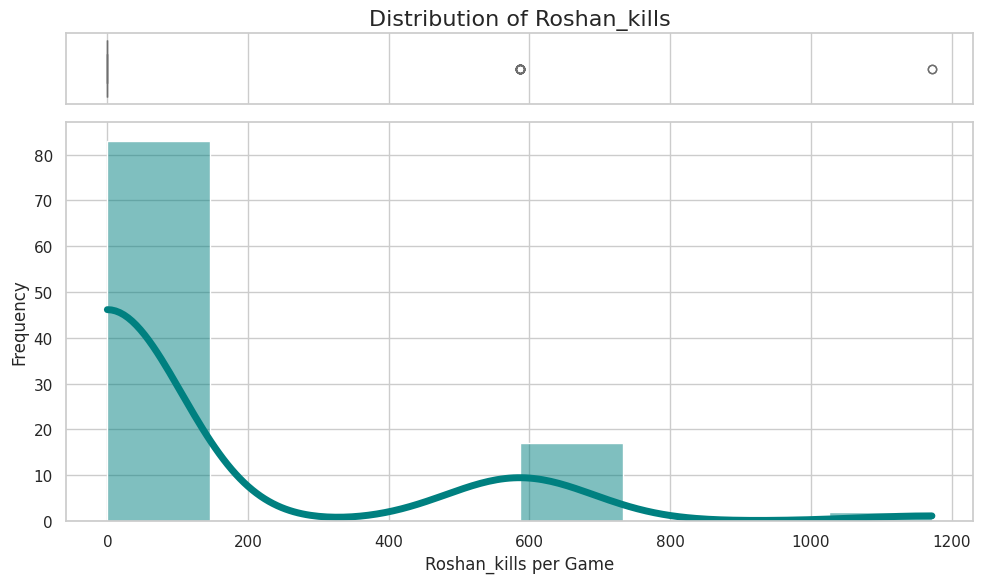

In [266]:
analyze_stat_performance(df_supports, 'roshan_kills')

--- Top 3 Series (Sum of top 2 games) for Roshan_kills ---


,Versus,teamName,roshan_kills
1,TEAM VISION vs Team Resilience,TEAM VISION,1758.0
22,GamerLegion vs Team Falcons,Team Falcons,1172.0
19,Team Liquid vs Team Spirit,Team Spirit,1172.0


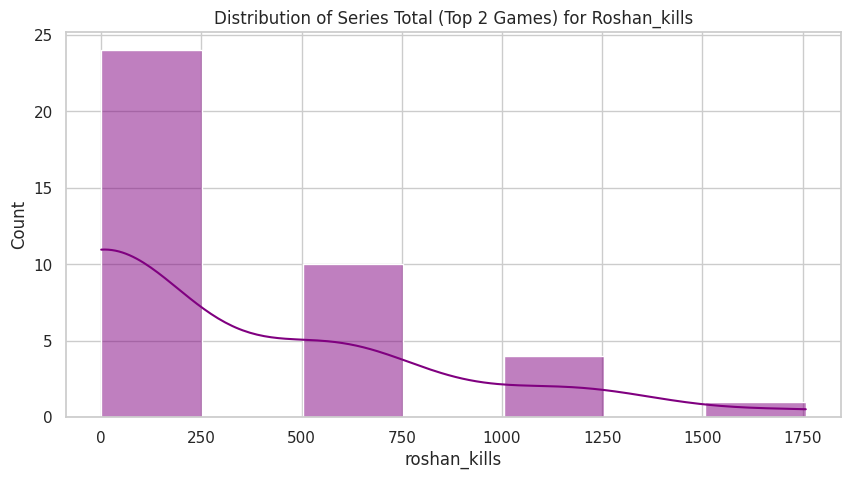

In [267]:
analyze_series_top2_stat(df_supports, 'roshan_kills')

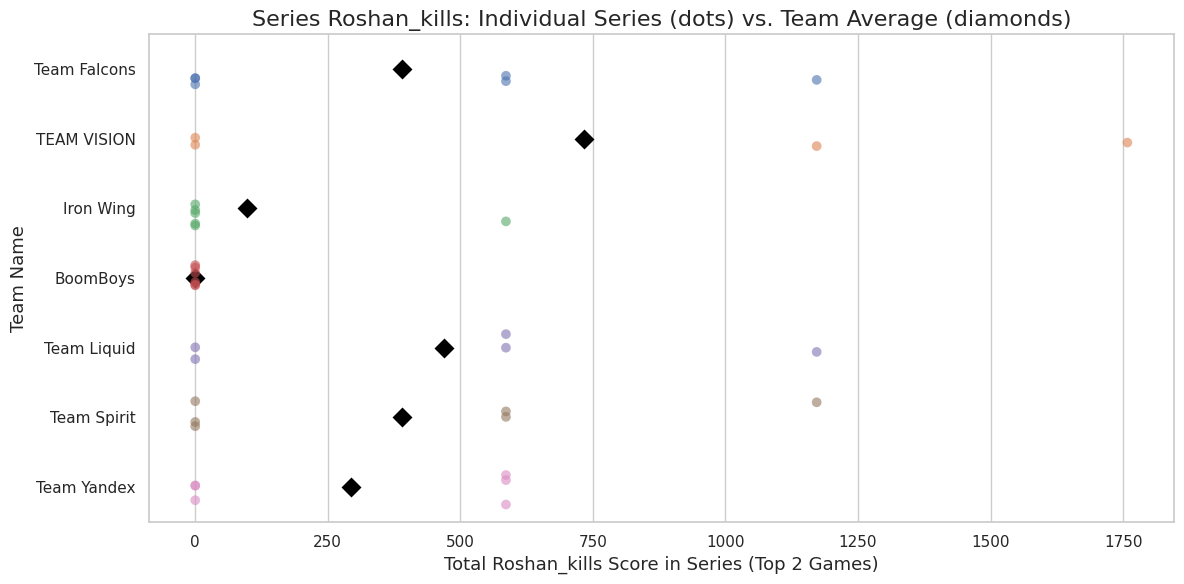

In [268]:
analyze_series_stat_by_team(df_supports, 'roshan_kills')

### 3.1.5 Tormentor Kills

--- Top 3 Performances for Tormentor_kills ---


,Versus,playerName,tormentor_kills
53,BoomBoys vs Iron Wing,Ari & Whitemon,439.5
20,BoomBoys vs TEAM VISION,Save- & Kataomi`,439.5
83,Iron Wing vs Team Yandex,Ari & Whitemon,439.5


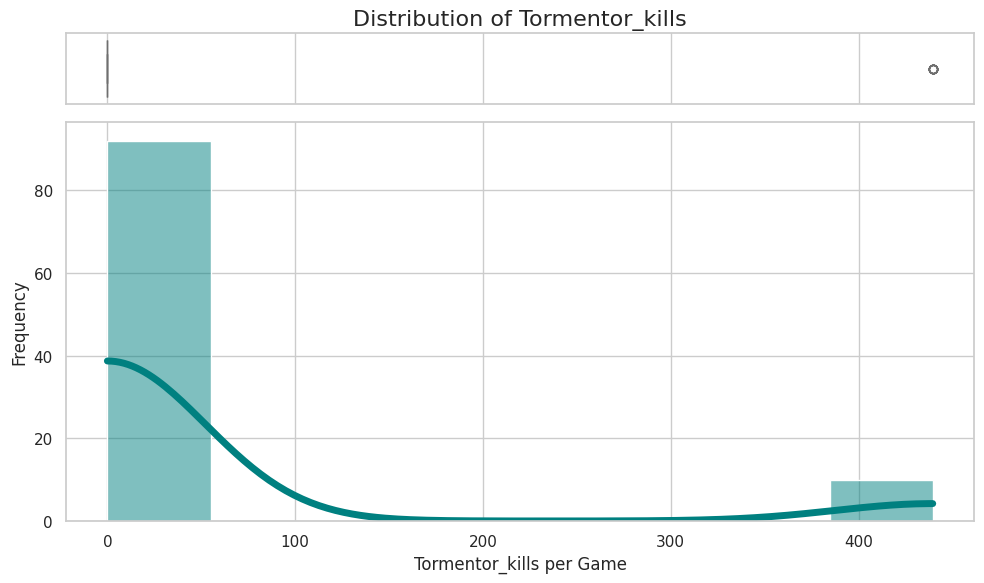

In [269]:
analyze_stat_performance(df_supports, 'tormentor_kills')

--- Top 3 Series (Sum of top 2 games) for Tormentor_kills ---


,Versus,teamName,tormentor_kills
0,LGD Gaming vs Team Falcons,Team Falcons,439.5
22,GamerLegion vs Team Falcons,Team Falcons,439.5
17,Iron Wing vs Team Falcons,Team Falcons,439.5


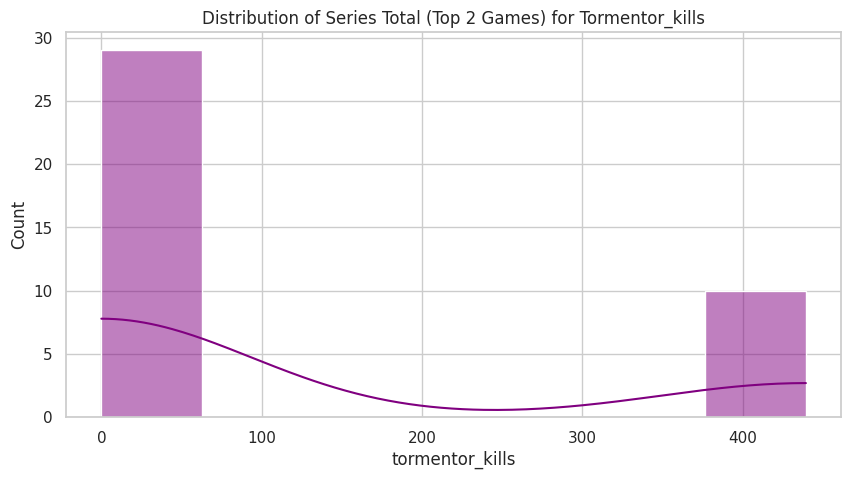

In [270]:
analyze_series_top2_stat(df_supports, 'tormentor_kills')

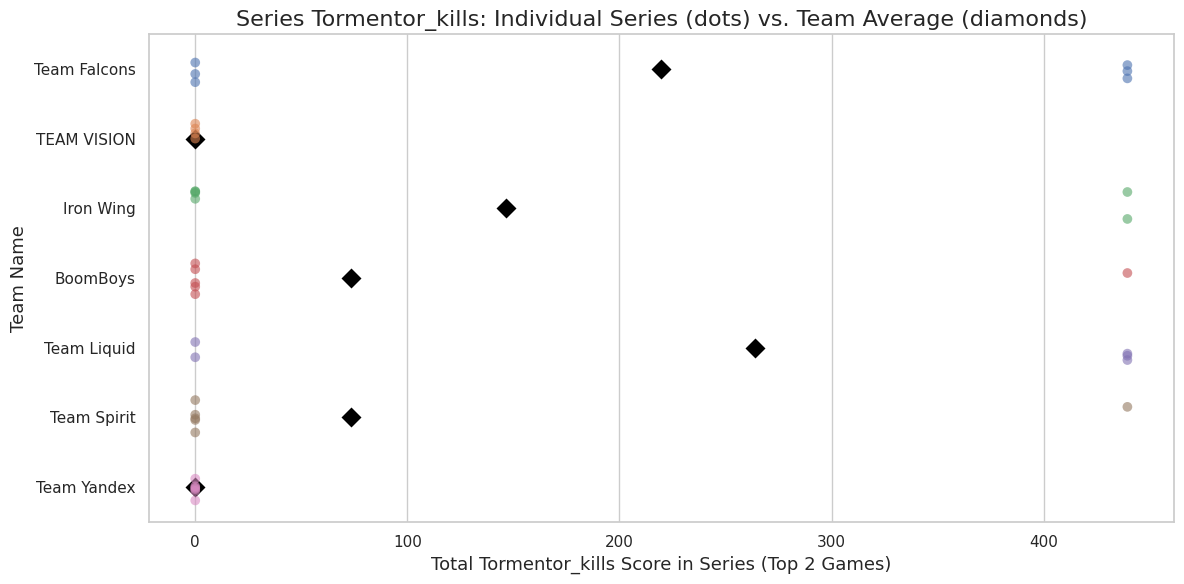

In [271]:
analyze_series_stat_by_team(df_supports, 'tormentor_kills')

### 3.1.6 Courier Kills

--- Top 3 Performances for Courier_kills ---


,Versus,playerName,courier_kills
305,LGD Gaming vs Team Yandex,Maladych & Saksa,3515.0
302,LGD Gaming vs Team Yandex,Maladych & Saksa,2460.5
83,Iron Wing vs Team Yandex,Ari & Whitemon,1406.0


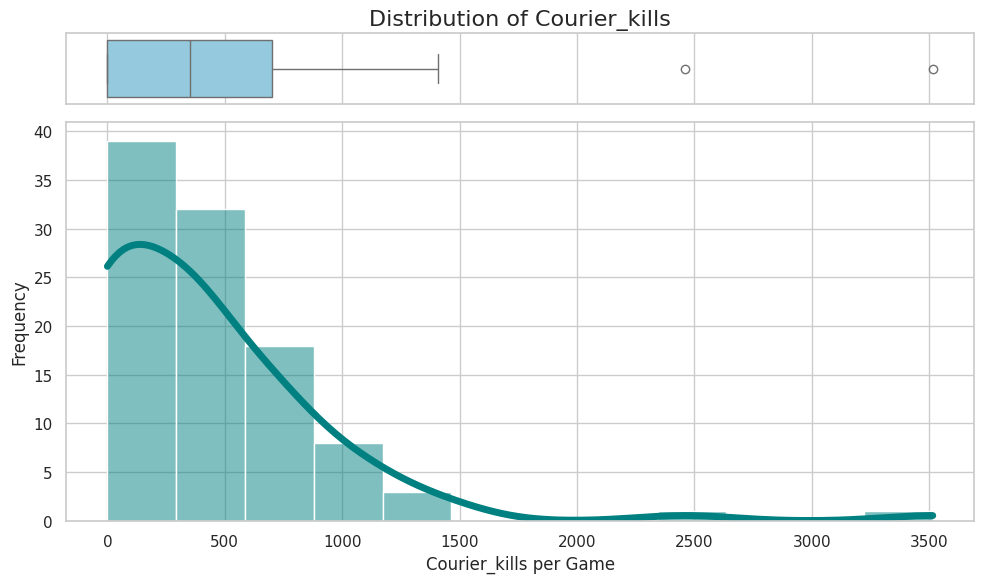

In [272]:
analyze_stat_performance(df_supports, 'courier_kills')

--- Top 3 Series (Sum of top 2 games) for Courier_kills ---


,Versus,teamName,courier_kills
38,LGD Gaming vs Team Yandex,Team Yandex,5975.5
9,TEAM VISION vs Team Falcons,TEAM VISION,1757.5
4,Team Liquid vs Vici Gaming,Team Liquid,1757.5


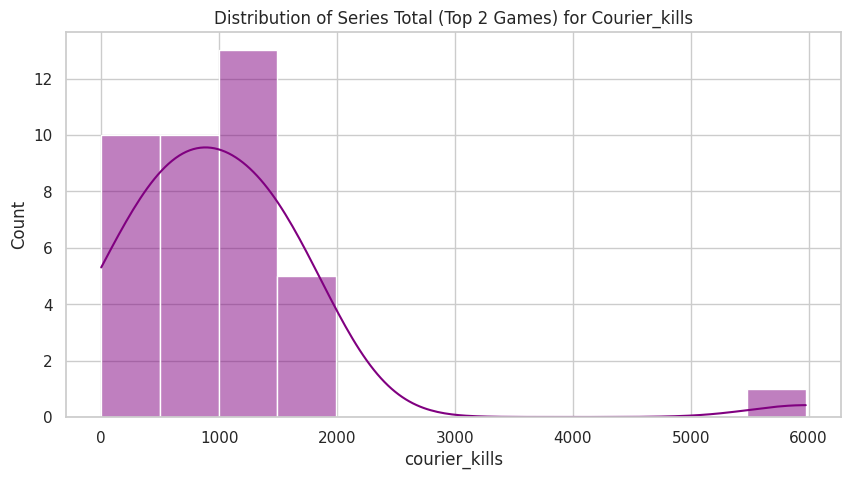

In [273]:
analyze_series_top2_stat(df_supports, 'courier_kills')

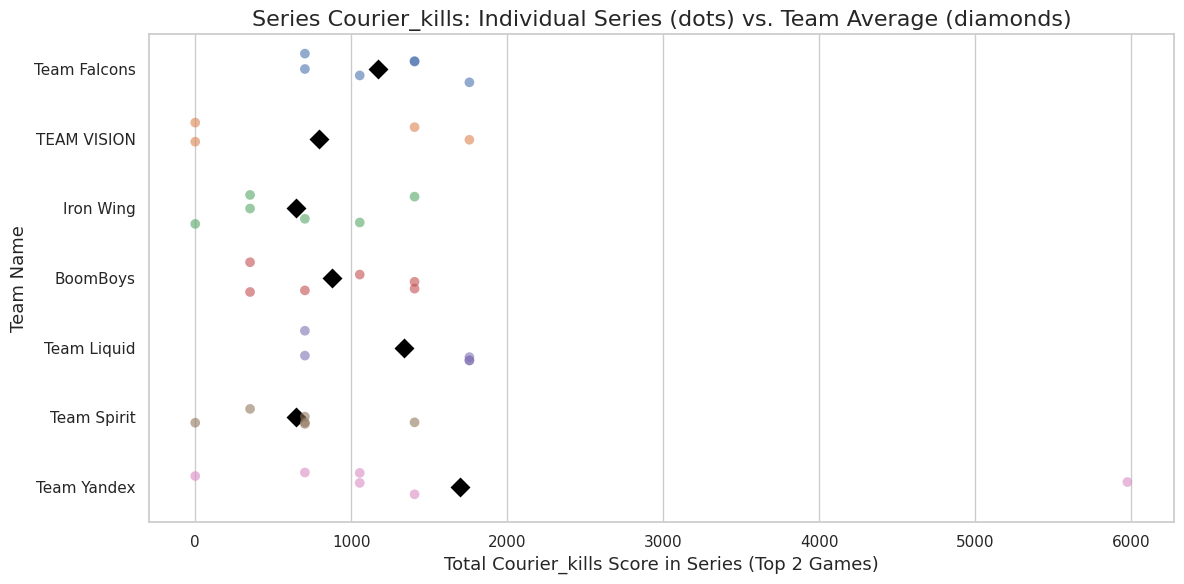

In [274]:
analyze_series_stat_by_team(df_supports, 'courier_kills')

## 3.2 Blue Stats

### 3.2.1 Observers Placed

--- Top 3 Performances for Obs_placed ---


,Versus,playerName,obs_placed
107,TEAM VISION vs Team Falcons,9Class & Dukalis,2457.0
137,TEAM VISION vs Team Falcons,Sneyking & Cr1t-,2281.5
20,BoomBoys vs TEAM VISION,Save- & Kataomi`,1755.0


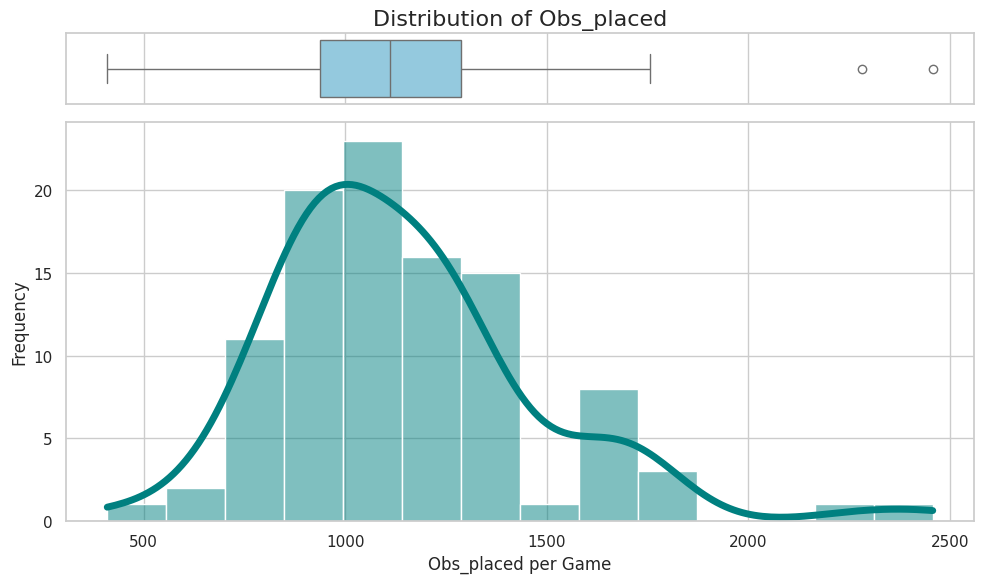

In [275]:
analyze_stat_performance(df_supports, 'obs_placed')

--- Top 3 Series (Sum of top 2 games) for Obs_placed ---


,Versus,teamName,obs_placed
9,TEAM VISION vs Team Falcons,TEAM VISION,3744.0
10,TEAM VISION vs Team Falcons,Team Falcons,3451.5
8,BoomBoys vs Iron Wing,Iron Wing,3159.0


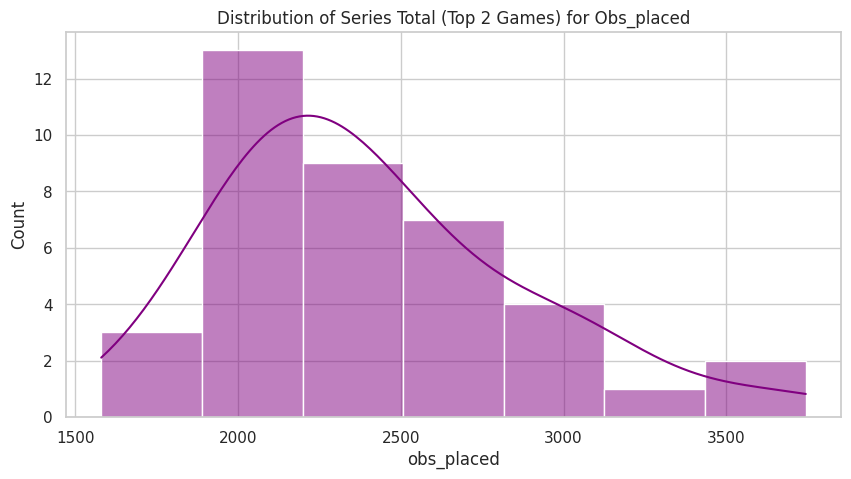

In [276]:
analyze_series_top2_stat(df_supports, 'obs_placed')

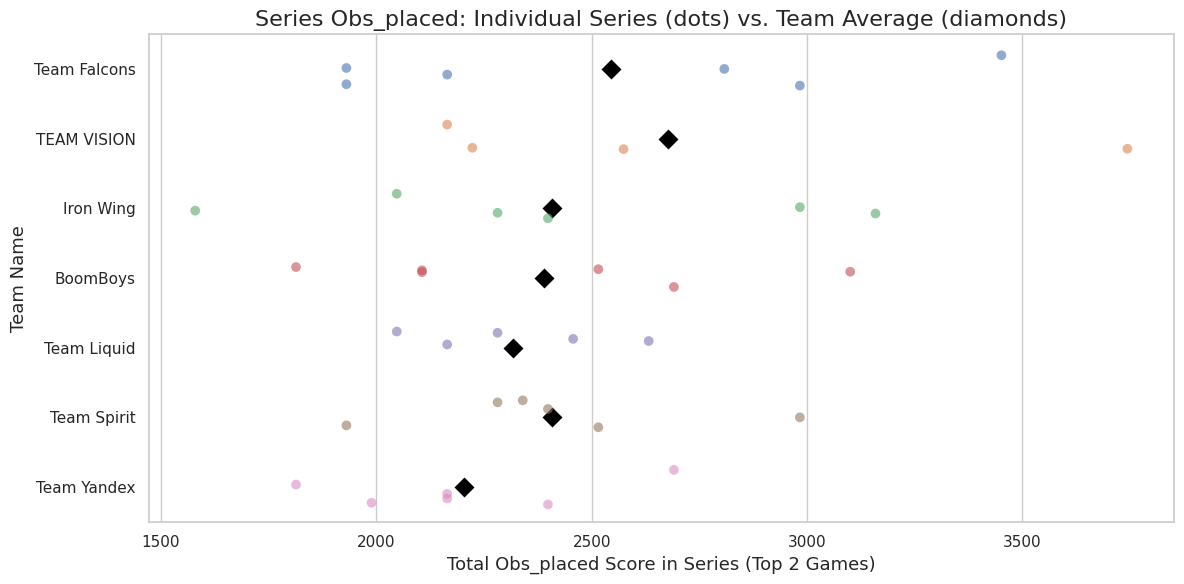

In [277]:
analyze_series_stat_by_team(df_supports, 'obs_placed')

### 3.2.2 Camps Stacked

--- Top 3 Performances for Camps_stacked ---


,Versus,playerName,camps_stacked
140,Iron Wing vs Team Falcons,Sneyking & Cr1t-,2691.0
50,BoomBoys vs Iron Wing,Ari & Whitemon,2223.0
56,BoomBoys vs Iron Wing,Ari & Whitemon,2223.0


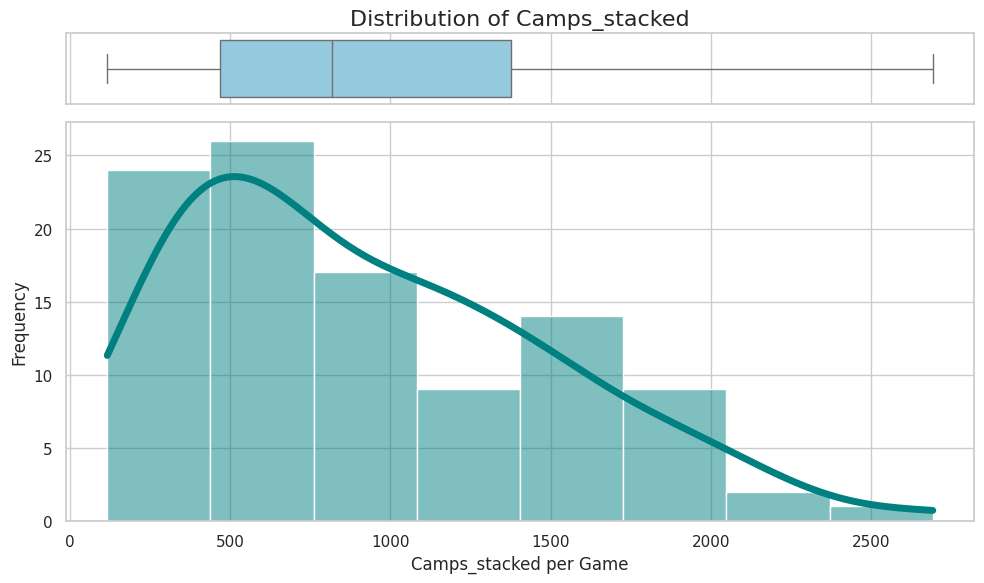

In [278]:
analyze_stat_performance(df_supports, 'camps_stacked')

--- Top 3 Series (Sum of top 2 games) for Camps_stacked ---


,Versus,teamName,camps_stacked
8,BoomBoys vs Iron Wing,Iron Wing,4446.0
17,Iron Wing vs Team Falcons,Team Falcons,4212.0
0,LGD Gaming vs Team Falcons,Team Falcons,3744.0


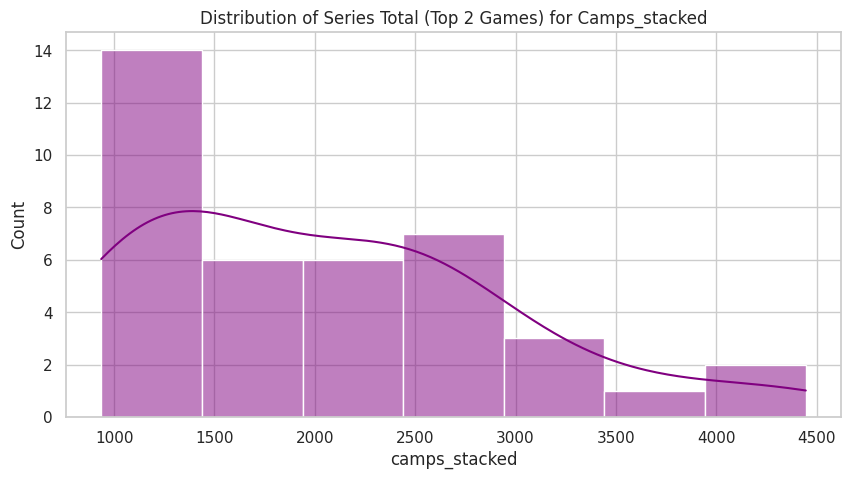

In [279]:
analyze_series_top2_stat(df_supports, 'camps_stacked')

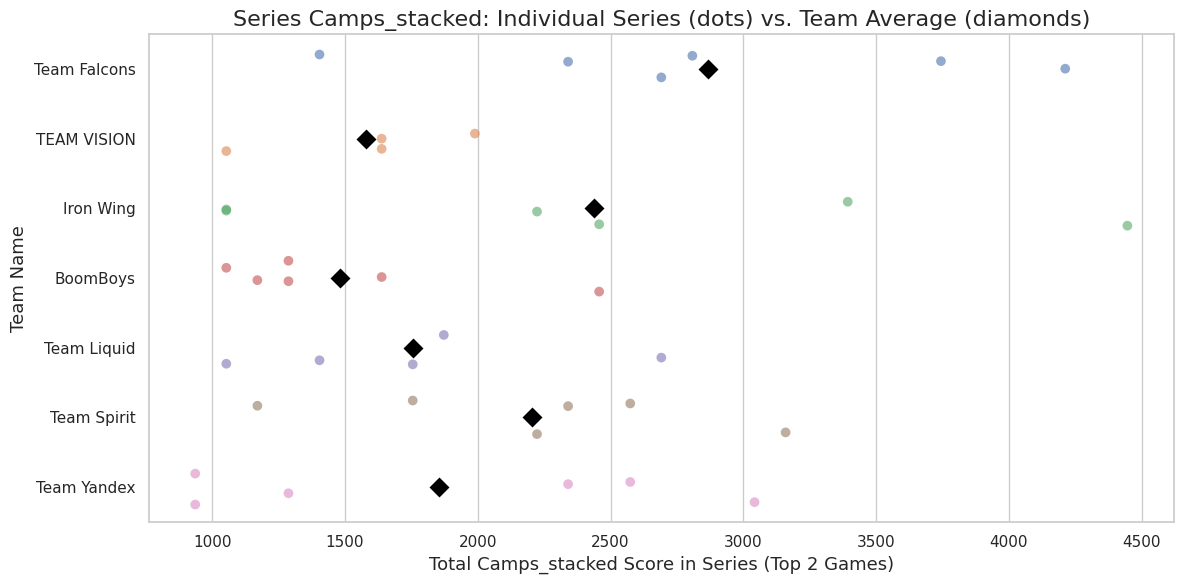

In [280]:
analyze_series_stat_by_team(df_supports, 'camps_stacked')

### 3.2.3 Runes Grabbed

--- Top 3 Performances for Runes_grabbed ---


,Versus,playerName,runes_grabbed
305,LGD Gaming vs Team Yandex,Maladych & Saksa,1269.0
173,Team Liquid vs Vici Gaming,tOfu & Boxi,1198.5
263,Team Liquid vs Team Yandex,Maladych & Saksa,1057.5


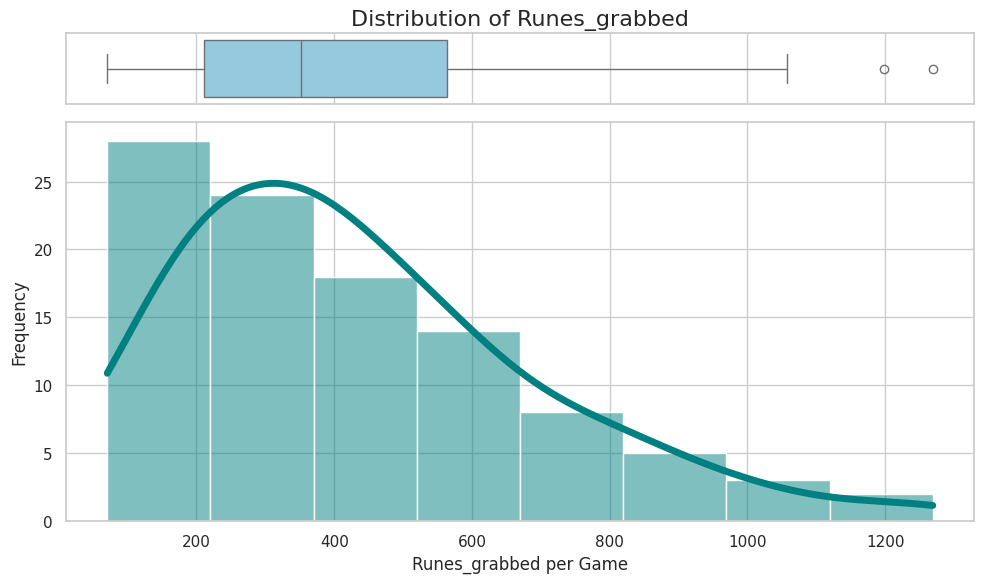

In [281]:
analyze_stat_performance(df_supports, 'runes_grabbed')

--- Top 3 Series (Sum of top 2 games) for Runes_grabbed ---


,Versus,teamName,runes_grabbed
38,LGD Gaming vs Team Yandex,Team Yandex,2256.0
13,Team Liquid vs Team Yandex,Team Yandex,1903.5
29,BoomBoys vs Team Falcons,Team Falcons,1480.5


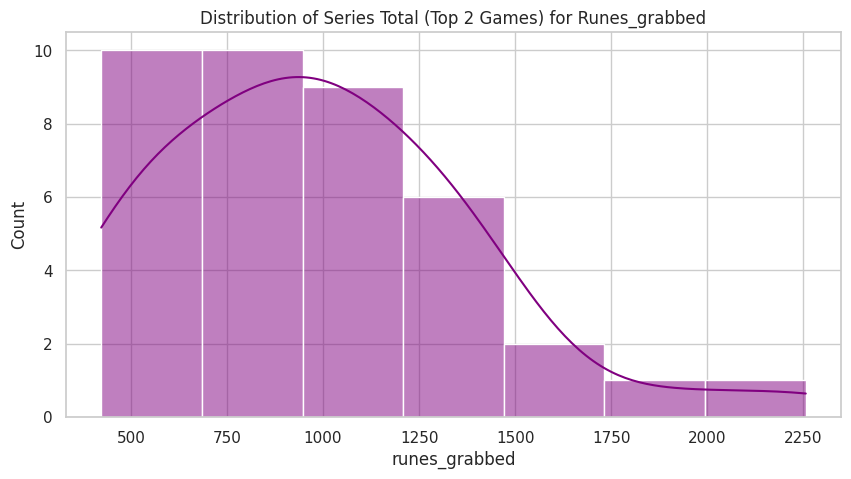

In [282]:
analyze_series_top2_stat(df_supports, 'runes_grabbed')

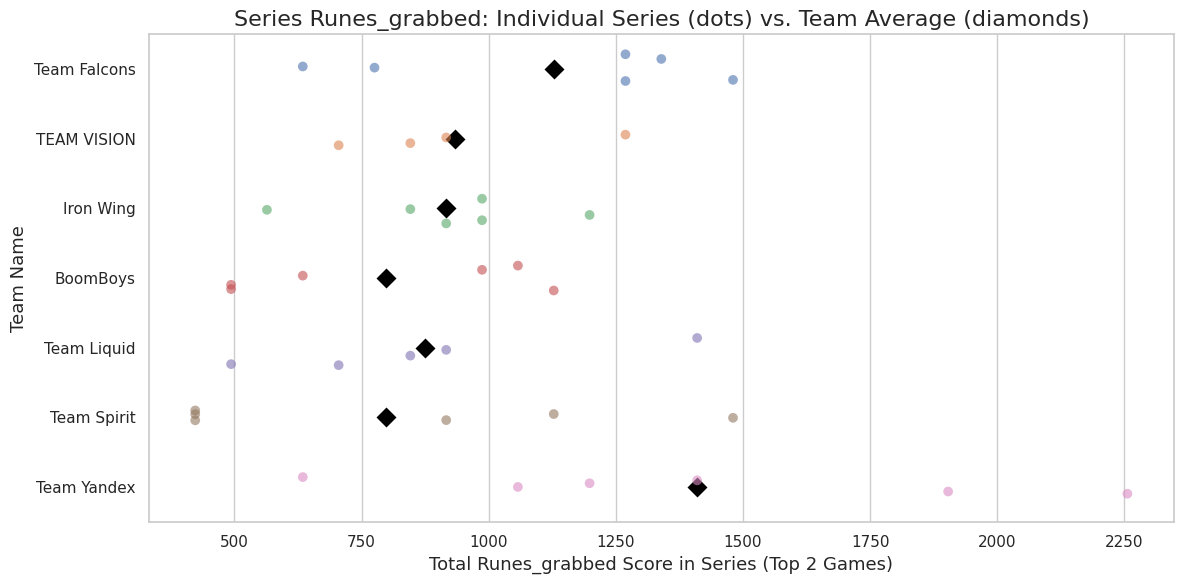

In [283]:
analyze_series_stat_by_team(df_supports, 'runes_grabbed')

### 3.2.4 Watchers Taken

--- Top 3 Performances for Watchers_taken ---


,Versus,playerName,watchers_taken
137,TEAM VISION vs Team Falcons,Sneyking & Cr1t-,2425.5
272,Aurora Gaming vs Team Yandex,Maladych & Saksa,2205.0
305,LGD Gaming vs Team Yandex,Maladych & Saksa,2131.5


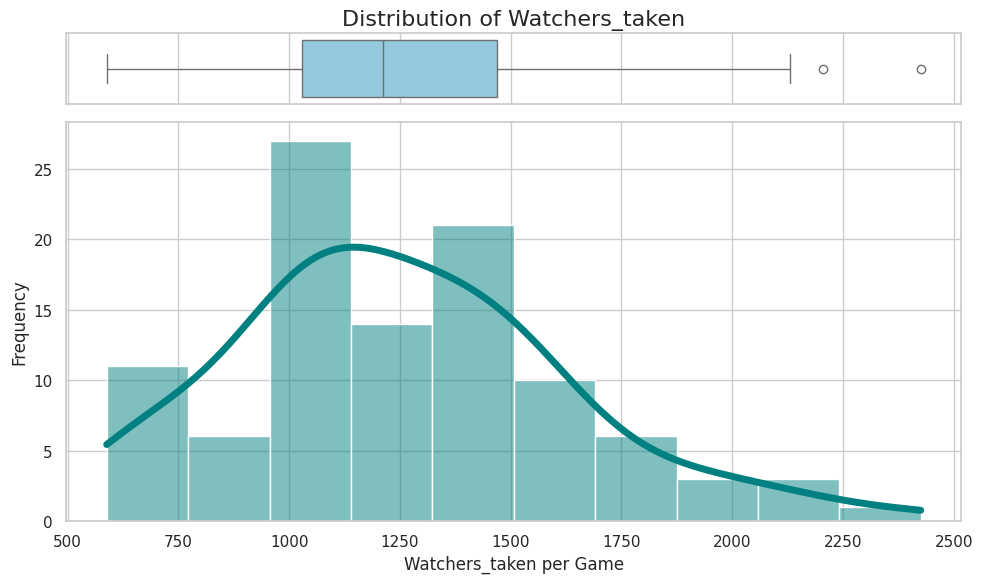

In [284]:
analyze_stat_performance(df_supports, 'watchers_taken')

--- Top 3 Series (Sum of top 2 games) for Watchers_taken ---


,Versus,teamName,watchers_taken
8,BoomBoys vs Iron Wing,Iron Wing,3748.5
9,TEAM VISION vs Team Falcons,TEAM VISION,3675.0
10,TEAM VISION vs Team Falcons,Team Falcons,3454.5


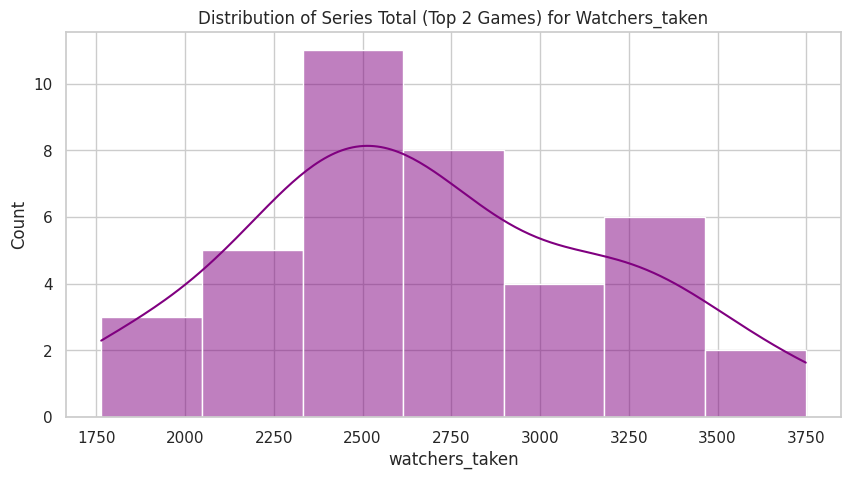

In [285]:
analyze_series_top2_stat(df_supports, 'watchers_taken')

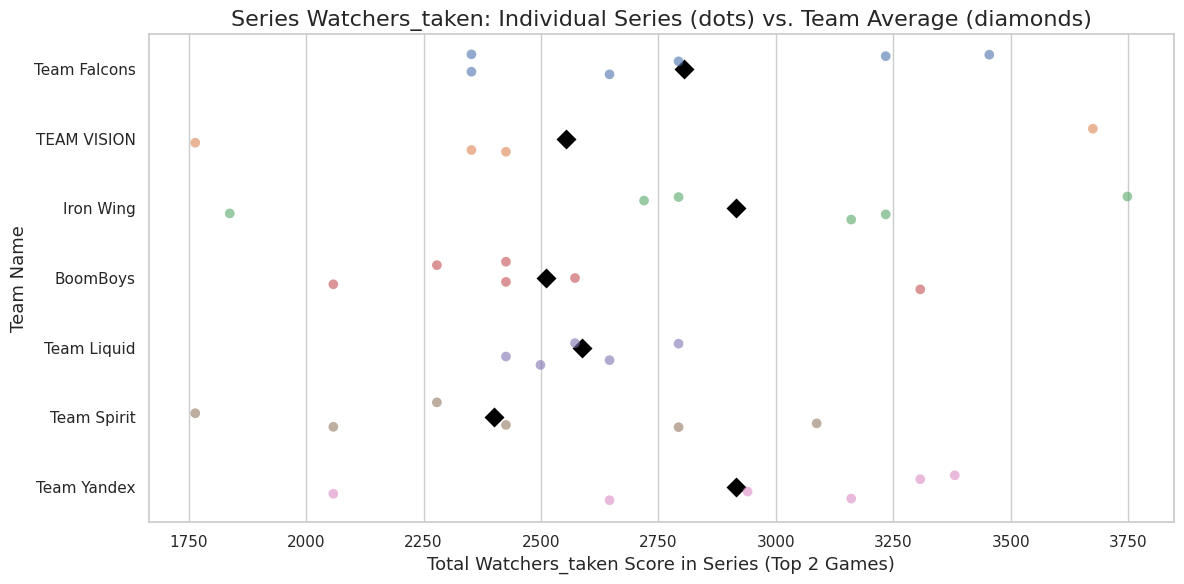

In [286]:
analyze_series_stat_by_team(df_supports, 'watchers_taken')

### 3.2.5 Smokes Used

--- Top 3 Performances for Smokes_used ---


,Versus,playerName,smokes_used
107,TEAM VISION vs Team Falcons,9Class & Dukalis,2051.0
137,TEAM VISION vs Team Falcons,Sneyking & Cr1t-,2051.0
59,Iron Wing vs Team Falcons,Ari & Whitemon,1611.5


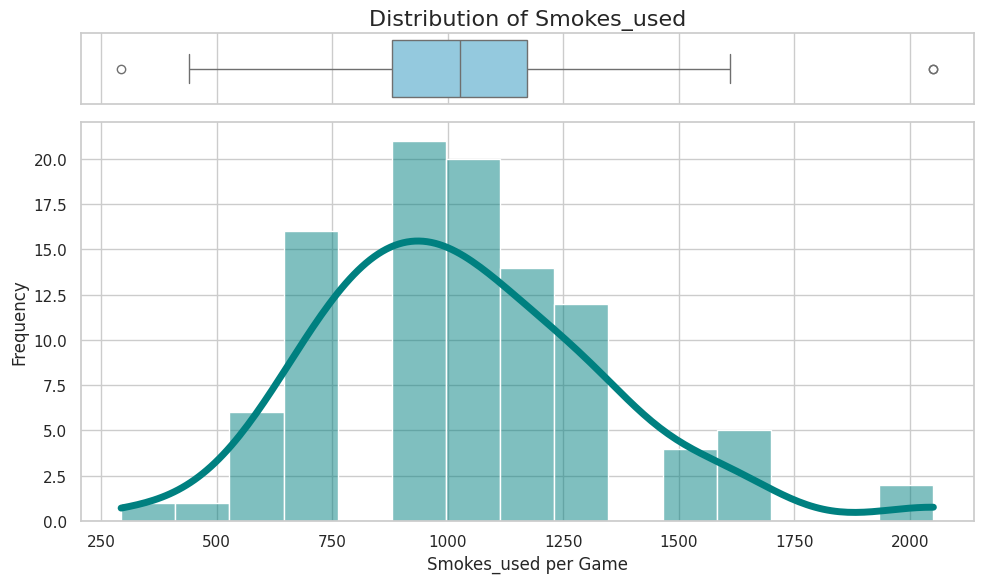

In [287]:
analyze_stat_performance(df_supports, 'smokes_used')

--- Top 3 Series (Sum of top 2 games) for Smokes_used ---


,Versus,teamName,smokes_used
9,TEAM VISION vs Team Falcons,TEAM VISION,3369.5
10,TEAM VISION vs Team Falcons,Team Falcons,3076.5
7,BoomBoys vs Iron Wing,BoomBoys,2930.0


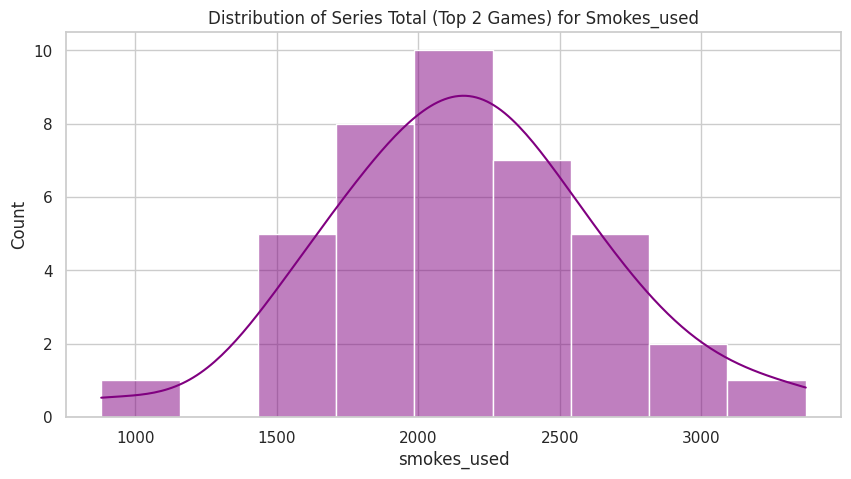

In [288]:
analyze_series_top2_stat(df_supports, 'smokes_used')

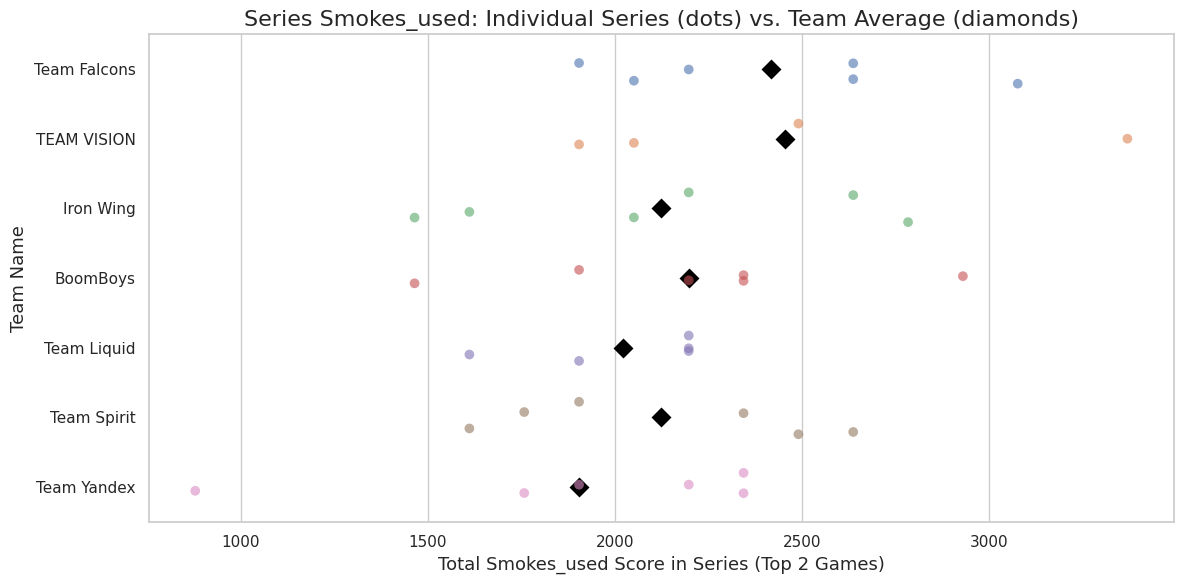

In [289]:
analyze_series_stat_by_team(df_supports, 'smokes_used')

## 3.3 Overall mid

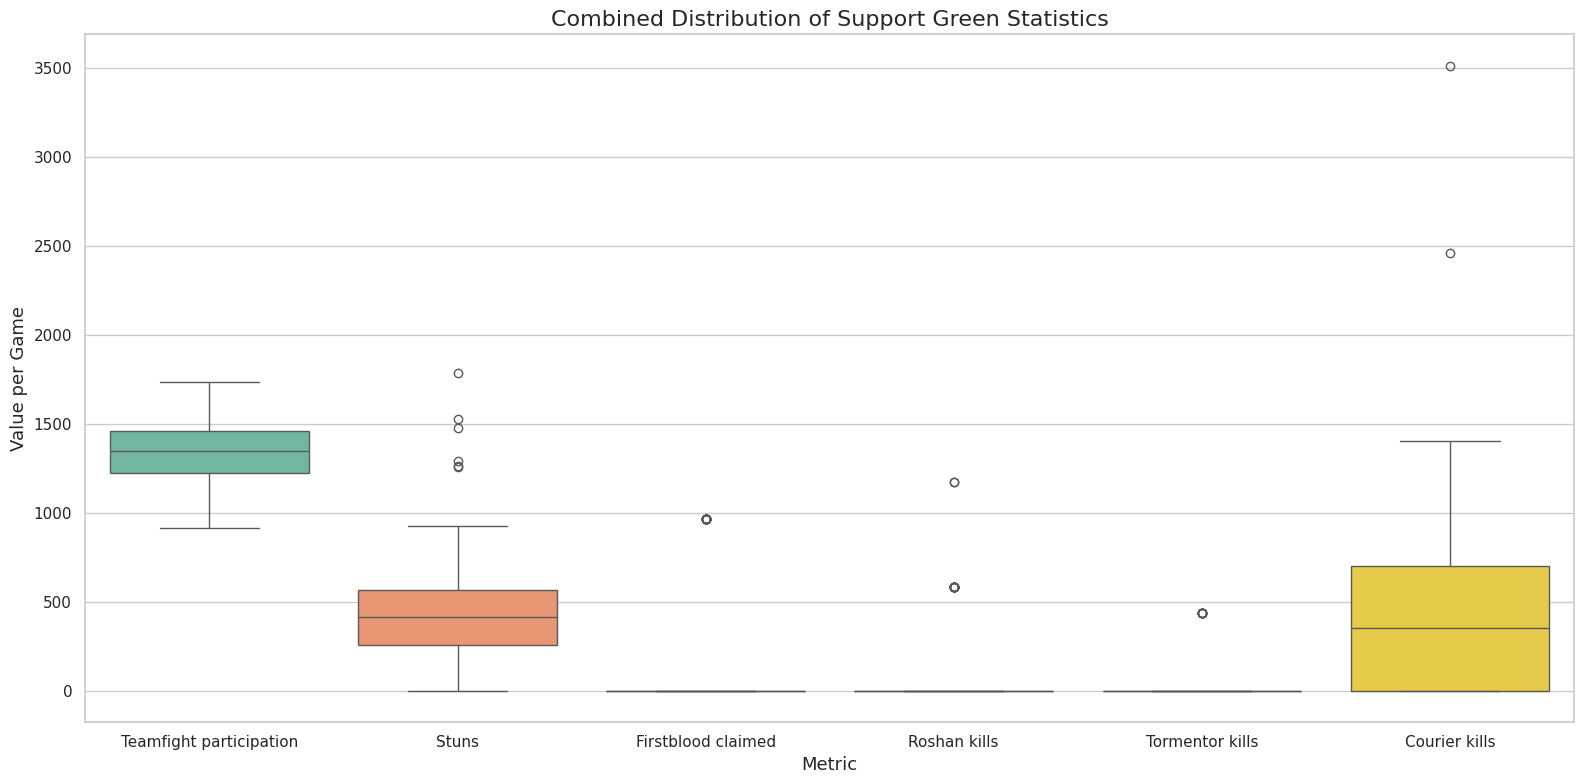

In [291]:
# List of 'Green' stats to consolidate
green_stats = [
    'teamfight_participation', 'stuns', 'firstblood_claimed',
    'roshan_kills', 'tormentor_kills', 'courier_kills'
]

# Prepare data by melting into long-form
df_green_melted = df_supports.melt(value_vars=green_stats, var_name='Statistic', value_name='Value')
df_green_melted['Statistic'] = df_green_melted['Statistic'].str.replace('_', ' ').str.capitalize()

# Create the combined vertical boxplot
plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")
sns.boxplot(data=df_green_melted, x='Statistic', y='Value', hue='Statistic', palette="Set2", legend=False)

plt.title('Combined Distribution of Support Green Statistics', fontsize=16)
plt.xlabel('Metric', fontsize=13)
plt.ylabel('Value per Game', fontsize=13)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

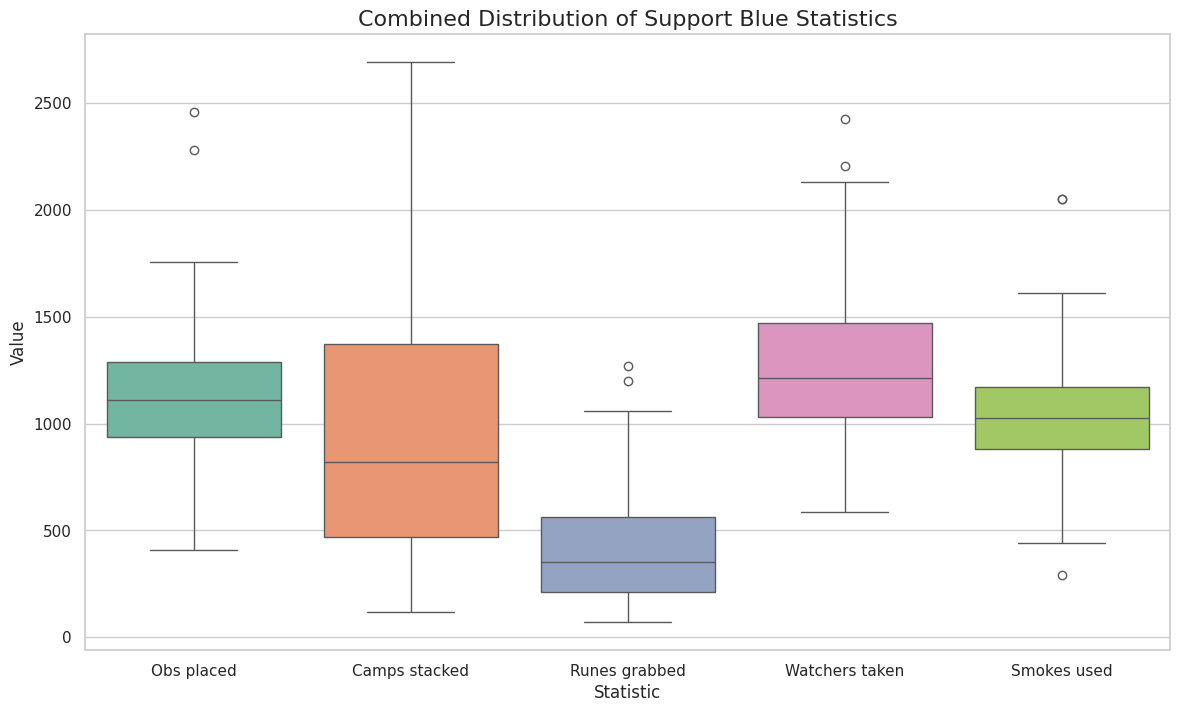

In [292]:
blue_stats = ['obs_placed', 'camps_stacked', 'runes_grabbed', 'watchers_taken', 'smokes_used']
df_blue_melted = df_supports.melt(value_vars=blue_stats, var_name='Statistic', value_name='Value')
df_blue_melted['Statistic'] = df_blue_melted['Statistic'].str.replace('_', ' ').str.capitalize()
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_blue_melted, x='Statistic', y='Value', hue='Statistic', palette='Set2', legend=False)
plt.title('Combined Distribution of Support Blue Statistics', fontsize=16)
plt.show()